In [1]:
import copy
import itertools as it
import random
import typing

from IPython.core.display import display, HTML
from nbmetalog import nbmetalog as nbm
import pandas as pd
import seaborn as sns
from tqdm import tqdm

import pylib

random.seed(1)


/usr/local/lib/python3.10/dist-packages/hstrat/_auxiliary_lib/_check_testing_requirements.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/usr/local/lib/python3.10/dist-packages/pandera/__init__.py:40: UserWarning: Pandas and numpy have been removed from the base pandera
dependencies. Please install pandas as part of your environment's
dependencies or install the pandas extra with:

```bash
pip install pandas pandera

# or
pip install 'pandera[pandas]'
```

  warnings.warn(_warning_msg, UserWarning)
/usr/local/lib/python3.10/dist-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  w

In [2]:
nbm.print_metadata()


context: ci
hostname: runnervmfg25i
interpreter: 3.10.12 (main, Aug 15 2025, 14:32:43) [GCC 11.4.0]
nbcellexec: null
nbname: 03-incrementing-incidence-reservation-surface--alternating-longevity-ordering
nbpath: /home/runner/work/hstrat-surface-concept/hstrat-surface-concept/binder/03-incrementing-incidence-reservation-surface--alternating-longevity-ordering.ipynb
revision: null
session: 60cbb9ec-628f-47bb-8022-183be50fb2e6
timestamp: 2025-11-09T00:23:24Z00:00


IPython==7.31.1
keyname==0.6.0
yaml==6.0.2
nbmetalog==0.2.6
pandas==1.5.2
seaborn==0.13.2
re==2.2.1
comm==0.2.2
logging==0.5.1.2
psutil==7.0.0
zmq==27.0.0
json==2.0.9
ipykernel==6.29.5


In [3]:
def get_num_sites_reserved_per_incidence_at_rank(rank: int) -> int:
    return pylib.bit_ceil(pylib.hanoi.get_max_hanoi_value_through_index(rank) + 1)


In [4]:
# test get_num_sites_reserved_per_incidence_at_rank
assert [get_num_sites_reserved_per_incidence_at_rank(rank) for rank in range(17)] == [
    # hanoi sequence (1-based):
    1,  # 1,
    2,  # 2,
    2,  # 1,
    4,  # 3,
    4,  # 1,
    4,  # 2,
    4,  # 1,
    4,  # 4,
    4,  # 1,
    4,  # 2,
    4,  # 1,
    4,  # 3,
    4,  # 1,
    4,  # 2,
    4,  # 1,
    8,  # 5,
    8,  # 1,
]


In [5]:
def get_num_incidence_reservations_at_rank(rank: int, surface_size: int) -> int:
    reservation_size = get_num_sites_reserved_per_incidence_at_rank(rank)
    assert surface_size % reservation_size == 0
    num_reservations = surface_size // reservation_size
    return num_reservations


In [6]:
# test get_num_incidence_reservations_at_rank
assert [get_num_incidence_reservations_at_rank(rank, 64) for rank in range(17)] == [
    # hanoi sequence (1-based):
    64,  # 1,
    32,  # 2,
    32,  # 1,
    16,  # 3,
    16,  # 1,
    16,  # 2,
    16,  # 1,
    16,  # 4,
    16,  # 1,
    16,  # 2,
    16,  # 1,
    16,  # 3,
    16,  # 1,
    16,  # 2,
    16,  # 1,
    8,   # 5,
    8,   # 1,
]


In [7]:
def is_2x_reservation_eligible(hanoi_value: int, surface_size: int, rank: int) -> bool:
    reservation_width = get_num_sites_reserved_per_incidence_at_rank(rank)
    lb_inclusive = (
        pylib.hanoi.get_max_hanoi_value_through_index(rank) - reservation_width // 2 + 1
    )
    ub_exclusive = reservation_width // 2
    return lb_inclusive <= hanoi_value < ub_exclusive


In [8]:
# test is_2x_reservation_eligible
# TODO


In [9]:
def get_ingest_site_at_rank(rank: int, surface_size: int) -> int:
    within_reservation_offset = pylib.hanoi.get_hanoi_value_at_index(rank)
    is_2x_reservation_eligible_ = is_2x_reservation_eligible(
        within_reservation_offset,
        surface_size,
        rank,
    )

    num_incidence_reservations = get_num_incidence_reservations_at_rank(
        rank, surface_size
    )
    if is_2x_reservation_eligible_:
        num_incidence_reservations *= 2

    reservation_index = (
        pylib.hanoi.get_hanoi_value_incidence_at_index(rank)
        % num_incidence_reservations
    )

    longevity_ordered_reservation_position = (
        pylib.longevity_ordering_alternating.get_longevity_mapped_position_of_index(
            reservation_index,
            num_incidence_reservations,
            polarity=True,
        )
    )

    reservation_size = get_num_sites_reserved_per_incidence_at_rank(rank)
    if is_2x_reservation_eligible_:
        reservation_size //= 2

    assert within_reservation_offset < reservation_size
    return (
        longevity_ordered_reservation_position * reservation_size
        + within_reservation_offset
    )


In [10]:
# test get_ingest_site_at_rank
# **needs to be updated**
# assert [get_ingest_site_at_rank(rank, 64) for rank in range(23)] == [
#          # num_reservations
#          #     # hanoi sequence (0-based):
#     0,   # 64, # 0,
#     1,   # 32, # 1,
#     32,  # 32, # 0,
#     2,   # 16, # 2,
#     16,  # 16, # 0,
#     33,  # 16, # 1,
#     48,  # 16, # 0,
#     3,   # 16, # 3,
#     8,   # 16, # 0,
#     17,  # 16, # 1,
#     24,  # 16, # 0,
#     34,  # 16, # 2,
#     40,  # 16, # 0,
#     49,  # 16, # 1,
#     56,  # 16, # 0,
#     4,   # 8,  # 4,
#     0,   # 8,  # 0,
#     9,   # 8,  # 1,
#     32,  # 8,  # 0,
#     18,  # 8,  # 2,
#     16,  # 8,  # 0,
#     25,  # 8,  # 1,
#     48,  # 8,  # 0,
# ]

# assert [get_ingest_site_at_rank(rank, 16) for rank in range(21)] == [
#         # num_reservations
#         #     # hanoi sequence (0-based):
#     0,  # 16, # 0,
#     1,  # 8,  # 1,
#     8,  # 8,  # 0,
#     2,  # 4,  # 2,
#     4,  # 4,  # 0,
#     9,  # 4,  # 1,
#     12, # 4,  # 0,
#     3,  # 4,  # 3,
#     0,  # 4,  # 0,
#     5,  # 4,  # 1,
#     8,  # 4,  # 0,
#     10, # 4,  # 2,
#     4,  # 4,  # 0,
#     13, # 4,  # 1,
#     12, # 4,  # 0,
#     4,  # 2,  # 4,
#     0,  # 2,  # 0,
#     1,  # 2,  # 1,
#     8,  # 2,  # 0,
#     6,  # 2,  # 2,
#     0,  # 2,  # 0,
# ]


In [11]:
def is_site_reservation_holdover_at_rank(site: int, surface_size: int, rank: int) -> bool:
    reservation_size = get_num_sites_reserved_per_incidence_at_rank(rank)
    within_reservation_offset = site % reservation_size

    return (
        within_reservation_offset
        > pylib.hanoi.get_max_hanoi_value_through_index(rank)
    )


In [12]:
# test get_hanoi_value_of_site

# rank
#    # ingest site
#    #     # num_reservations
#    #     #     # hanoi sequence (0-based):
# 0  # 0,  # 16, # 0,
for rank in range(3):
    assert [
        is_site_reservation_holdover_at_rank(site, 16, rank) for site in range(16)
    ] == [False] * 16

# rank
#    # ingest site
#    #     # num_reservations
#    #     #     # hanoi sequence (0-based):
# 3  # 2,  # 4,  # 2,
# 4  # 4,  # 4,  # 0,
# 5  # 9,  # 4,  # 1,
# 6  # 12, # 4,  # 0,
for rank in range(3, 7):
    assert [is_site_reservation_holdover_at_rank(site, 16, rank) for site in range(16)] == [
        False,
        False,
        False,
        True,
    ] * 4

# rank
#    # ingest site
#    #     # num_reservations
#    #     #     # hanoi sequence (0-based):
# 7  # 3,  # 4,  # 3,
# 8  # 0,  # 4,  # 0,
# 9  # 5,  # 4,  # 1,
# 10 # 8,  # 4,  # 0,
# 11 # 10, # 4,  # 2,
# 12 # 4,  # 4,  # 0,
# 13 # 13, # 4,  # 1,
# 14 # 12, # 4,  # 0,
for rank in range(7, 14):
    assert [
        is_site_reservation_holdover_at_rank(site, 16, rank) for site in range(16)
    ] == [False] * 16

# rank
#    # ingest site
#    #     # num_reservations
#    #     #     # hanoi sequence (0-based):
# 15 # 4,  # 2,  # 4,
# 16 # 0,  # 2,  # 0,
# 17 # 1,  # 2,  # 1,
# 18 # 8,  # 2,  # 0,
# 19 # 6,  # 2,  # 2,
# 20 # 0,  # 2,  # 0,
for rank in range(15, 21):
    assert [is_site_reservation_holdover_at_rank(site, 16, rank) for site in range(16)] == [
        False,
        False,
        False,
        False,
        False,
        True,
        True,
        True,
    ] * 2


In [13]:
def get_hanoi_value_of_site_at_rank(site: int, surface_size: int, rank: int) -> int:
    is_reservation_holdover = (
        is_site_reservation_holdover_at_rank(site, surface_size, rank)
    )

    reservation_size = get_num_sites_reserved_per_incidence_at_rank(rank)
    if is_reservation_holdover:
        reservation_size //= 2

    return site % reservation_size


In [14]:
# test get_hanoi_value_of_site

# rank
#    # ingest site
#    #     # num_reservations
#    #     #     # hanoi sequence (0-based):
# 0  # 0,  # 16, # 0,
assert [get_hanoi_value_of_site_at_rank(site, 16, 0) for site in range(16)] == [0] * 16

# rank
#    # ingest site
#    #     # num_reservations
#    #     #     # hanoi sequence (0-based):
# 1  # 1,  # 8,  # 1,
# 2  # 8,  # 8,  # 0,
for rank in 1, 2:
    assert [get_hanoi_value_of_site_at_rank(site, 16, rank) for site in range(16)] == [
        0,
        1,
    ] * 8

# rank
#    # ingest site
#    #     # num_reservations
#    #     #     # hanoi sequence (0-based):
# 3  # 2,  # 4,  # 2,
# 4  # 4,  # 4,  # 0,
# 5  # 9,  # 4,  # 1,
# 6  # 12, # 4,  # 0,
for rank in range(3, 7):
    assert [get_hanoi_value_of_site_at_rank(site, 16, rank) for site in range(16)] == [
        0,
        1,
        2,
        1,
    ] * 4

# rank
#    # ingest site
#    #     # num_reservations
#    #     #     # hanoi sequence (0-based):
# 7  # 3,  # 4,  # 3,
# 8  # 0,  # 4,  # 0,
# 9  # 5,  # 4,  # 1,
# 10 # 8,  # 4,  # 0,
# 11 # 10, # 4,  # 2,
# 12 # 4,  # 4,  # 0,
# 13 # 13, # 4,  # 1,
# 14 # 12, # 4,  # 0,
for rank in range(7, 14):
    assert [get_hanoi_value_of_site_at_rank(site, 16, rank) for site in range(16)] == [
        0,
        1,
        2,
        3,
    ] * 4

# rank
#    # ingest site
#    #     # num_reservations
#    #     #     # hanoi sequence (0-based):
# 15 # 4,  # 2,  # 4,
# 16 # 0,  # 2,  # 0,
# 17 # 1,  # 2,  # 1,
# 18 # 8,  # 2,  # 0,
# 19 # 6,  # 2,  # 2,
# 20 # 0,  # 2,  # 0,
for rank in range(15, 21):
    assert [get_hanoi_value_of_site_at_rank(site, 16, rank) for site in range(16)] == [
        0,
        1,
        2,
        3,
        4,
        1,
        2,
        3,
    ] * 2


In [15]:
def get_reservation_index_of_site_at_rank(
    site: int, surface_size: int, rank: int
) -> int:
    reservation_size = get_num_sites_reserved_per_incidence_at_rank(rank)
    num_incidence_reservations = get_num_incidence_reservations_at_rank(
        rank, surface_size
    )

    is_reservation_holdover = (
        is_site_reservation_holdover_at_rank(site, surface_size, rank)
    )
    if is_reservation_holdover:
        reservation_size //= 2
        num_incidence_reservations *= 2

    longevity_ordered_reservation_position = site // reservation_size

    reservation_index = pylib.longevity_ordering_alternating.get_longevity_index_of_mapped_position(
        longevity_ordered_reservation_position,
        num_incidence_reservations,
        polarity=True,
    )
    return reservation_index


In [16]:
# test get_reservation_index_of_site_at_rank
# **needs to be updated**
# assert [get_reservation_index_of_site_at_rank(site, 16, 0) for site in range(16)] == [
#     0,
#     8,
#     4,
#     9,
#     2,
#     10,
#     5,
#     11,
#     1,
#     12,
#     6,
#     13,
#     3,
#     14,
#     7,
#     15,
# ]

# for rank in 1, 2:
#     assert [get_reservation_index_of_site_at_rank(site, 16, rank) for site in range(16)] == [
#         0,
#         0,
#         4,
#         4,
#         2,
#         2,
#         5,
#         5,
#         1,
#         1,
#         6,
#         6,
#         3,
#         3,
#         7,
#         7,
#     ]

# for rank in range(3, 7):
#     assert [get_reservation_index_of_site_at_rank(site, 16, rank) for site in range(16)] == [
#         0,
#         0,
#         0,
#         4,
#         2,
#         2,
#         2,
#         5,
#         1,
#         1,
#         1,
#         6,
#         3,
#         3,
#         3,
#         7,
#     ]

# for rank in range(7, 14):
#     assert [get_reservation_index_of_site_at_rank(site, 16, rank) for site in range(16)] == [
#         0,
#         0,
#         0,
#         0,
#         2,
#         2,
#         2,
#         2,
#         1,
#         1,
#         1,
#         1,
#         3,
#         3,
#         3,
#         3,
#     ]

# for rank in range(15, 21):
#     assert [get_reservation_index_of_site_at_rank(site, 16, 15) for site in range(16)] == [
#         0,
#         0,
#         0,
#         0,
#         0,
#         2,
#         2,
#         2,
#         1,
#         1,
#         1,
#         1,
#         1,
#         3,
#         3,
#         3,
#     ]


In [17]:
def get_hanoi_incidence_of_site_at_rank(site: int, surface_size: int, rank: int) -> int:
    # this function deals with incidence wraparound over number of reservations
    hanoi_value = get_hanoi_value_of_site_at_rank(site, surface_size, rank)
    incidence_count = pylib.hanoi.get_incidence_count_of_hanoi_value_through_index(
        hanoi_value,
        rank,
    )
    incidence_count = max(incidence_count, 1)
    max_incidence = incidence_count - 1

    num_incidence_reservations_naive = get_num_incidence_reservations_at_rank(
        rank, surface_size
    )
    is_site_reservation_holdover_at_rank_ = is_2x_reservation_eligible(
        hanoi_value,
        surface_size,
        rank,
    )
    num_incidence_reservations = (
        num_incidence_reservations_naive
        * (is_site_reservation_holdover_at_rank_ + 1)
    )

    reservation_index = get_reservation_index_of_site_at_rank(site, surface_size, rank)
    assert reservation_index < num_incidence_reservations

    if max_incidence >= num_incidence_reservations:
        excess_incidence = (
            max_incidence - reservation_index
        ) % num_incidence_reservations
        candidate_incidence = max_incidence - excess_incidence
        candidate_rank = pylib.hanoi.get_index_of_hanoi_value_nth_incidence(
            hanoi_value,
            candidate_incidence,
        )
        assert candidate_rank <= rank
        if candidate_rank == rank:
            return candidate_incidence
        else:
            return get_hanoi_incidence_of_site_at_rank(
                site, surface_size, candidate_rank
            )
    else:
        return reservation_index


In [18]:
# test get_hanoi_incidence_of_site_at_rank
# **needs to be updated**
# assert [get_hanoi_incidence_of_site_at_rank(0, 64, rank) for rank in range(20)] == [
#         # ingest site
#         #     # num_reservations
#         #     #     # hanoi sequence (0-based):
#     0,  # 0,  # 64, # 0,
#     0,  # 1,  # 32, # 1,
#     0,  # 32, # 32, # 0,
#     0,  # 2,  # 16, # 2,
#     0,  # 16, # 16, # 0,
#     0,  # 33, # 16, # 1,
#     0,  # 48, # 16, # 0,
#     0,  # 3,  # 16, # 3,
#     0,  # 8,  # 16, # 0,
#     0,  # 17, # 16, # 1,
#     0,  # 24, # 16, # 0,
#     0,  # 34, # 16, # 2,
#     0,  # 40, # 16, # 0,
#     0,  # 49, # 16, # 1,
#     0,  # 56, # 16, # 0,
#     0,  # 4,  # 8,  # 4,
#     8,  # 0,  # 8,  # 0,
#     8,  # 9,  # 8,  # 1,
#     8,  # 32, # 8,  # 0,
#     8,  # 25, # 8,  # 1,
# ]
# assert [get_hanoi_incidence_of_site_at_rank(1, 64, rank) for rank in range(20)] == [
#         # ingest site
#         #     # num_reservations
#         #     #     # hanoi sequence (0-based):
#     32, # 0,  # 64, # 0,
#     0,  # 1,  # 32, # 1,
#     0,  # 32, # 32, # 0,
#     0,  # 2,  # 16, # 2,
#     0,  # 16, # 16, # 0,
#     0,  # 33, # 16, # 1,
#     0,  # 48, # 16, # 0,
#     0,  # 3,  # 16, # 3,
#     0,  # 8,  # 16, # 0,
#     0,  # 17, # 16, # 1,
#     0,  # 24, # 16, # 0,
#     0,  # 34, # 16, # 2,
#     0,  # 40, # 16, # 0,
#     0,  # 49, # 16, # 1,
#     0,  # 56, # 16, # 0,
#     0,  # 4,  # 8,  # 4,
#     0,  # 0,  # 8,  # 0,
#     0,  # 9,  # 8,  # 1,
#     0,  # 32, # 8,  # 0,
#     0,  # 25, # 8,  # 1,
# ]
# assert [get_hanoi_incidence_of_site_at_rank(32, 64, rank) for rank in range(20)] == [
#         # ingest site
#         #     # num_reservations
#         #     #     # hanoi sequence (0-based):
#     1,  # 0,  # 64, # 0,
#     1,  # 1,  # 32, # 1,
#     1,  # 32, # 32, # 0,
#     1,  # 2,  # 16, # 2,
#     1,  # 16, # 16, # 0,
#     1,  # 33, # 16, # 1,
#     1,  # 48, # 16, # 0,
#     1,  # 3,  # 16, # 3,
#     1,  # 8,  # 16, # 0,
#     1,  # 17, # 16, # 1,
#     1,  # 24, # 16, # 0,
#     1,  # 34, # 16, # 2,
#     1,  # 40, # 16, # 0,
#     1,  # 49, # 16, # 1,
#     1,  # 56, # 16, # 0,
#     1,  # 4,  # 8,  # 4,
#     1,  # 0,  # 8,  # 0,
#     1,  # 9,  # 8,  # 1,
#     9,  # 32, # 8,  # 0,
#     9,  # 25, # 8,  # 1,
# ]
# assert [get_hanoi_incidence_of_site_at_rank(63, 64, rank) for rank in range(20)] == [
#          # ingest site
#          #     # num_reservations
#          #     #     # hanoi sequence (0-based):
#     63,  # 0,  # 64, # 0,
#     31,  # 1,  # 32, # 1,
#     31,  # 32, # 32, # 0,
#     31,  # 2,  # 16, # 2,
#     31,  # 16, # 16, # 0,
#     31,  # 33, # 16, # 1,
#     31,  # 48, # 16, # 0,
#     15,  # 3,  # 16, # 3,
#     15,  # 8,  # 16, # 0,
#     15,  # 17, # 16, # 1,
#     15,  # 24, # 16, # 0,
#     15,  # 34, # 16, # 2,
#     15,  # 40, # 16, # 0,
#     15,  # 49, # 16, # 1,
#     15,  # 56, # 16, # 0,
#     15,  # 4,  # 8,  # 4,
#     15,  # 0,  # 8,  # 0,
#     15,  # 9,  # 8,  # 1,
#     15,  # 32, # 8,  # 0,
#     15,  # 25, # 8,  # 1,
# ]


In [19]:
# test get_hanoi_incidence_of_site_at_rank
# **needs to be updated**
# assert [get_hanoi_incidence_of_site_at_rank(0, 16, rank) for rank in range(21)] == [
#         # ingest_site
#         #     # num_reservations
#         #     #     # hanoi sequence (0-based):
#     0,  # 0,  # 16, # 0,
#     0,  # 1,  # 8,  # 1,
#     0,  # 8,  # 8,  # 0,
#     0,  # 2,  # 4,  # 2,
#     0,  # 4,  # 4,  # 0,
#     0,  # 9,  # 4,  # 1,
#     0,  # 12, # 4,  # 0,
#     0,  # 3,  # 4,  # 3,
#     4,  # 0,  # 4,  # 0,
#     4,  # 5,  # 4,  # 1,
#     4,  # 8,  # 4,  # 0,
#     4,  # 10, # 4,  # 2,
#     4,  # 4,  # 4,  # 0,
#     4,  # 13, # 4,  # 1,
#     4,  # 12, # 4,  # 0,
#     4,  # 4,  # 2,  # 4,
#     8,  # 0,  # 2,  # 0,
#     8,  # 1,  # 2,  # 1,
#     8,  # 8,  # 2,  # 0,
#     8,  # 6,  # 2,  # 2,
#     10, # 0,  # 2,  # 0,
# ]
# assert [get_hanoi_incidence_of_site_at_rank(1, 16, rank) for rank in range(21)] == [
#         # ingest_site
#         #     # num_reservations
#         #     #     # hanoi sequence (0-based):
#     8,  # 0,  # 16, # 0,
#     0,  # 1,  # 8,  # 1,
#     0,  # 8,  # 8,  # 0,
#     0,  # 2,  # 4,  # 2,
#     0,  # 4,  # 4,  # 0,
#     0,  # 9,  # 4,  # 1,
#     0,  # 12, # 4,  # 0,
#     0,  # 3,  # 4,  # 3,
#     0,  # 0,  # 4,  # 0,
#     0,  # 5,  # 4,  # 1,
#     0,  # 8,  # 4,  # 0,
#     0,  # 10, # 4,  # 2,
#     0,  # 4,  # 4,  # 0,
#     0,  # 13, # 4,  # 1,
#     0,  # 12, # 4,  # 0,
#     0,  # 4,  # 2,  # 4,
#     0,  # 0,  # 2,  # 0,
#     4,  # 1,  # 2,  # 1,
#     4,  # 8,  # 2,  # 0,
#     4,  # 6,  # 2,  # 2,
#     4,  # 0,  # 2,  # 0,
# ]
# assert [get_hanoi_incidence_of_site_at_rank(2, 16, rank) for rank in range(21)] == [
#         # rank
#         #    # ingest_site
#         #    #     # num_reservations
#         #    #     #     # hanoi sequence (0-based):
#     4,  # 0  # 0,  # 16, # 0,
#     4,  # 1  # 1,  # 8,  # 1,
#     4,  # 2  # 8,  # 8,  # 0,
#     0,  # 3  # 2,  # 4,  # 2,
#     0,  # 4  # 4,  # 4,  # 0,
#     0,  # 5  # 9,  # 4,  # 1,
#     0,  # 6  # 12, # 4,  # 0,
#     0,  # 7  # 3,  # 4,  # 3,
#     0,  # 8  # 0,  # 4,  # 0,
#     0,  # 9  # 5,  # 4,  # 1,
#     0,  # 10 # 8,  # 4,  # 0,
#     0,  # 11 # 10, # 4,  # 2,
#     0,  # 12 # 4,  # 4,  # 0,
#     0,  # 13 # 13, # 4,  # 1,
#     0,  # 14 # 12, # 4,  # 0,
#     0,  # 15 # 4,  # 2,  # 4,
#     0,  # 16 # 0,  # 2,  # 0,
#     0,  # 17 # 1,  # 2,  # 1,
#     0,  # 18 # 8,  # 2,  # 0,
#     0,  # 19 # 6,  # 2,  # 2,
#     0,  # 20 # 0,  # 2,  # 0,
# ]
# assert [get_hanoi_incidence_of_site_at_rank(8, 16, rank) for rank in range(21)] == [
#         # ingest_site
#         #     # num_reservations
#         #     #     # hanoi sequence (0-based):
#     1,  # 0,  # 16, # 0,
#     1,  # 1,  # 8,  # 1,
#     1,  # 8,  # 8,  # 0,
#     1,  # 2,  # 4,  # 2,
#     1,  # 4,  # 4,  # 0,
#     1,  # 9,  # 4,  # 1,
#     1,  # 12, # 4,  # 0,
#     1,  # 3,  # 4,  # 3,
#     1,  # 0,  # 4,  # 0,
#     1,  # 5,  # 4,  # 1,
#     5,  # 8,  # 4,  # 0,
#     5,  # 10, # 4,  # 2,
#     5,  # 4,  # 4,  # 0,
#     5,  # 13, # 4,  # 1,
#     5,  # 12, # 4,  # 0,
#     5,  # 4,  # 2,  # 4,
#     5,  # 0,  # 2,  # 0,
#     5,  # 1,  # 2,  # 1,
#     9,  # 8,  # 2,  # 0,
#     9,  # 6,  # 2,  # 2,
#     9,  # 0,  # 2,  # 0,
# ]
# assert [get_hanoi_incidence_of_site_at_rank(15, 16, rank) for rank in range(21)] == [
#         # ingest_site
#         #     # num_reservations
#         #     #     # hanoi sequence (0-based):
#     15, # 0,  # 16, # 0,
#     7,  # 1,  # 8,  # 1,
#     7,  # 8,  # 8,  # 0,
#     7,  # 2,  # 4,  # 2,
#     7,  # 4,  # 4,  # 0,
#     7,  # 9,  # 4,  # 1,
#     7,  # 12, # 4,  # 0,
#     3,  # 3,  # 4,  # 3,
#     3,  # 0,  # 4,  # 0,
#     3,  # 5,  # 4,  # 1,
#     3,  # 8,  # 4,  # 0,
#     3,  # 10, # 4,  # 2,
#     3,  # 4,  # 4,  # 0,
#     3,  # 13, # 4,  # 1,
#     3,  # 12, # 4,  # 0,
#     3,  # 4,  # 2,  # 4,
#     3,  # 0,  # 2,  # 0,
#     3,  # 1,  # 2,  # 1,
#     3,  # 8,  # 2,  # 0,
#     3,  # 6,  # 2,  # 2,
#     3,  # 0,  # 2,  # 0,
# ]


In [20]:
def get_ingest_rank_at_site(
    site: int, surface_size: int, num_ingests: int
) -> int:
    if num_ingests == 0:
        return 0

    rank = num_ingests - 1

    hanoi_value = get_hanoi_value_of_site_at_rank(site, surface_size, rank)
    hanoi_incidence = get_hanoi_incidence_of_site_at_rank(site, surface_size, rank)
    candidate_rank = pylib.hanoi.get_index_of_hanoi_value_nth_incidence(
        hanoi_value,
        hanoi_incidence,
    )

    if candidate_rank < num_ingests:
        return candidate_rank
    else:
        # haven't got this far in the reservation
        # what was left here the last time around
        # todo this recursion is slow and inefficient
        return get_ingest_rank_at_site(site, surface_size, num_ingests - 1)


In [21]:
# test get_ingest_rank_at_site
assert [
    get_ingest_rank_at_site(0, 16, num_ingests) for num_ingests in range(22)
] == [
        # ingest site
        #     # num_reservations
        #     #     # hanoi sequence (0-based):
    0,  # ~~~~ n/a ~~~~
    0,  # 0,  # 16, # 0,
    0,  # 1,  # 8,  # 1,
    0,  # 8,  # 8,  # 0,
    0,  # 2,  # 4,  # 2,
    0,  # 4,  # 4,  # 0,
    0,  # 9,  # 4,  # 1,
    0,  # 12, # 4,  # 0,
    0,  # 3,  # 4,  # 3,
    8,  # 0,  # 4,  # 0,
    8,  # 5,  # 4,  # 1,
    8,  # 8,  # 4,  # 0,
    8,  # 10, # 4,  # 2,
    8,  # 4,  # 4,  # 0,
    8,  # 13, # 4,  # 1,
    8,  # 12, # 4,  # 0,
    8,  # 4,  # 2,  # 4,
    16, # 0,  # 2,  # 0,
    16, # 1,  # 2,  # 1,
    16, # 8,  # 2,  # 0,
    16, # 6,  # 2,  # 2,
    20, # 0,  # 2,  # 0,
]
assert [
    get_ingest_rank_at_site(1, 16, num_ingests) for num_ingests in range(22)
] == [
        # ingest site
        #     # num_reservations
        #     #     # hanoi sequence (0-based):
    0,  # ~~~~ n/a ~~~~
    0,  # 0,  # 16, # 0,
    1,  # 1,  # 8,  # 1,
    1,  # 8,  # 8,  # 0,
    1,  # 2,  # 4,  # 2,
    1,  # 4,  # 4,  # 0,
    1,  # 9,  # 4,  # 1,
    1,  # 12, # 4,  # 0,
    1,  # 3,  # 4,  # 3,
    1,  # 0,  # 4,  # 0,
    1,  # 5,  # 4,  # 1,
    1,  # 8,  # 4,  # 0,
    1,  # 10, # 4,  # 2,
    1,  # 4,  # 4,  # 0,
    1,  # 13, # 4,  # 1,
    1,  # 12, # 4,  # 0,
    1,  # 4,  # 2,  # 4,
    1,  # 0,  # 2,  # 0,
    17, # 1,  # 2,  # 1,
    17, # 8,  # 2,  # 0,
    17, # 6,  # 2,  # 2,
    17, # 0,  # 2,  # 0,
]
assert [
    get_ingest_rank_at_site(2, 16, num_ingests) for num_ingests in range(22)
] == [
        # ingest site
        #     # num_reservations
        #     #     # hanoi sequence (0-based):
    0,  # ~~~~ n/a ~~~~
    0,  # 0,  # 16, # 0,
    0,  # 1,  # 8,  # 1,
    0,  # 8,  # 8,  # 0,
    3,  # 2,  # 4,  # 2,
    3,  # 4,  # 4,  # 0,
    3,  # 9,  # 4,  # 1,
    3,  # 12, # 4,  # 0,
    3,  # 3,  # 4,  # 3,
    3,  # 0,  # 4,  # 0,
    3,  # 5,  # 4,  # 1,
    3,  # 8,  # 4,  # 0,
    3,  # 10, # 4,  # 2,
    3,  # 4,  # 4,  # 0,
    3,  # 13, # 4,  # 1,
    3,  # 12, # 4,  # 0,
    3,  # 4,  # 2,  # 4,
    3,  # 0,  # 2,  # 0,
    3,  # 1,  # 2,  # 1,
    3,  # 8,  # 2,  # 0,
    3,  # 6,  # 2,  # 2,
    3,  # 0,  # 2,  # 0,
]
assert [
    get_ingest_rank_at_site(15, 16, num_ingests)
    for num_ingests in range(22)
] == [
        # ingest site
        #     # num_reservations
        #     #     # hanoi sequence (0-based):
    0,  # ~~~~ n/a ~~~~
    0,  # 0,  # 16, # 0,
    0,  # 1,  # 8,  # 1,
    0,  # 8,  # 8,  # 0,
    0,  # 2,  # 4,  # 2,
    0,  # 4,  # 4,  # 0,
    0,  # 9,  # 4,  # 1,
    0,  # 12, # 4,  # 0,
    0,  # 3,  # 4,  # 3,
    0,  # 0,  # 4,  # 0,
    0,  # 5,  # 4,  # 1,
    0,  # 8,  # 4,  # 0,
    0,  # 10, # 4,  # 2,
    0,  # 4,  # 4,  # 0,
    0,  # 13, # 4,  # 1,
    0,  # 12, # 4,  # 0,
    0,  # 4,  # 2,  # 4,
    0,  # 0,  # 2,  # 0,
    0,  # 1,  # 2,  # 1,
    0,  # 8,  # 2,  # 0,
    0,  # 6,  # 2,  # 2,
    0,  # 0,  # 2,  # 0,
]
assert [
    get_ingest_rank_at_site(8, 16, num_ingests) for num_ingests in range(22)
] == [
        # ingest site
        #     # num_reservations
        #     #     # hanoi sequence (0-based):
    0,  # ~~~~ n/a ~~~~
    0,  # 0,  # 16, # 0,
    0,  # 1,  # 8,  # 1,
    2,  # 8,  # 8,  # 0,
    2,  # 2,  # 4,  # 2,
    2,  # 4,  # 4,  # 0,
    2,  # 9,  # 4,  # 1,
    2,  # 12, # 4,  # 0,
    2,  # 3,  # 4,  # 3,
    2,  # 0,  # 4,  # 0,
    2,  # 5,  # 4,  # 1,
    10, # 8,  # 4,  # 0,
    10, # 10, # 4,  # 2,
    10, # 4,  # 4,  # 0,
    10, # 13, # 4,  # 1,
    10, # 12, # 4,  # 0,
    10, # 4,  # 2,  # 4,
    10, # 0,  # 2,  # 0,
    10, # 1,  # 2,  # 1,
    18, # 8,  # 2,  # 0,
    18, # 6,  # 2,  # 2,
    18, # 0,  # 2,  # 0,
]
assert [
    get_ingest_rank_at_site(9, 16, num_ingests) for num_ingests in range(23)
] == [
        # ingest site
        #     # num_reservations
        #     #     # hanoi sequence (0-based):
    0,  # ~~~~ n/a ~~~~
    0,  # 0,  # 16, # 0,
    0,  # 1,  # 8,  # 1,
    0,  # 8,  # 8,  # 0,
    0,  # 2,  # 4,  # 2,
    0,  # 4,  # 4,  # 0,
    5,  # 9,  # 4,  # 1,
    5,  # 12, # 4,  # 0,
    5,  # 3,  # 4,  # 3,
    5,  # 0,  # 4,  # 0,
    5,  # 5,  # 4,  # 1,
    5,  # 8,  # 4,  # 0,
    5,  # 10, # 4,  # 2,
    5,  # 4,  # 4,  # 0,
    5,  # 13, # 4,  # 1,
    5,  # 12, # 4,  # 0,
    5,  # 4,  # 2,  # 4,
    5,  # 0,  # 2,  # 0,
    5,  # 1,  # 2,  # 1,
    5,  # 8,  # 2,  # 0,
    5,  # 6,  # 2,  # 2,
    5,  # 0,  # 2,  # 0,
    21, # 9,  # 2,  # 1,
]


# 64-bit surface


In [22]:
surface_size = 64
num_generations = 1000

surface_timestamps = [0] * surface_size
surface_values = [random.choice([0, 1]) for __ in range(surface_size)]


In [23]:
surface_timestamps_records = []
for generation in tqdm(range(num_generations)):
    target_site = get_ingest_site_at_rank(generation, surface_size)
    surface_values[target_site] = random.choice([0, 1])
    surface_timestamps[target_site] = generation

    assert [
        get_ingest_rank_at_site(site, surface_size, generation + 1)
        for site in range(surface_size)
    ] == surface_timestamps

    for site, timestamp in enumerate(surface_timestamps):
        surface_timestamps_records.append(
            {
                "generation": generation,
                "site": site,
                "timestamp": timestamp,
            }
        )


100%|██████████| 1000/1000 [00:43<00:00, 23.14it/s]


In [24]:
surface_timestamps_df = pd.DataFrame.from_records(surface_timestamps_records)
surface_timestamps_df


,generation,site,timestamp
0,0,0,0
1,0,1,0
2,0,2,0
3,0,3,0
4,0,4,0
...,...,...,...
63995,999,59,967
63996,999,60,911
63997,999,61,799
63998,999,62,575


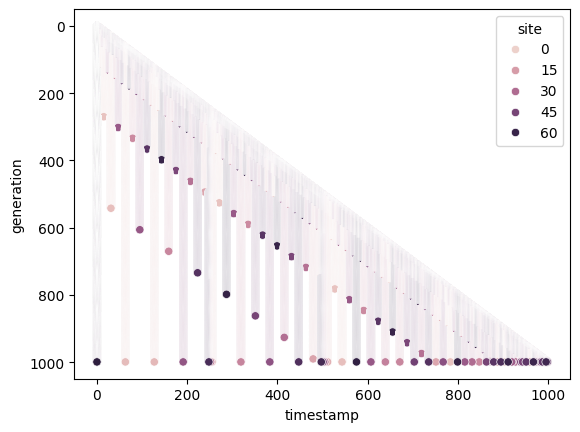

In [25]:
sns.scatterplot(
    data=surface_timestamps_df,
    x="timestamp",
    y="generation",
    hue="site",
).invert_yaxis()


<Axes: xlabel='generation', ylabel='timestamp'>

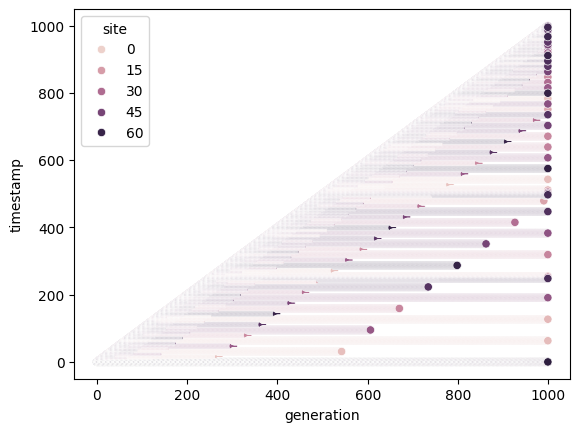

In [26]:
sns.scatterplot(
    data=surface_timestamps_df,
    x="generation",
    y="timestamp",
    hue="site",
)


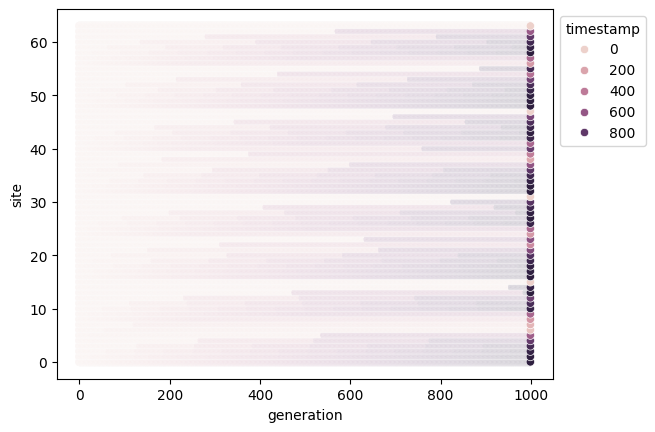

In [27]:
ax = sns.scatterplot(
    data=surface_timestamps_df,
    x="generation",
    y="site",
    hue="timestamp",
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


# 16-bit surface


In [28]:
surface_size = 16
num_generations = 100

surface_timestamps = [0] * surface_size
surface_values = [random.choice([0, 1]) for __ in range(surface_size)]


In [29]:
surface_timestamps_records = []
for generation in tqdm(range(num_generations)):
    target_site = get_ingest_site_at_rank(generation, surface_size)
    surface_values[target_site] = random.choice([0, 1])
    surface_timestamps[target_site] = generation

    assert [
        get_ingest_rank_at_site(site, surface_size, generation + 1)
        for site in range(surface_size)
    ] == surface_timestamps

    for site, timestamp in enumerate(surface_timestamps):
        surface_timestamps_records.append(
            {
                "generation": generation,
                "site": site,
                "timestamp": timestamp,
            }
        )


100%|██████████| 100/100 [00:00<00:00, 1444.59it/s]


In [30]:
surface_timestamps_df = pd.DataFrame.from_records(surface_timestamps_records)
surface_timestamps_df


,generation,site,timestamp
0,0,0,0
1,0,1,0
2,0,2,0
3,0,3,0
4,0,4,0
...,...,...,...
1595,99,11,87
1596,99,12,47
1597,99,13,95
1598,99,14,59


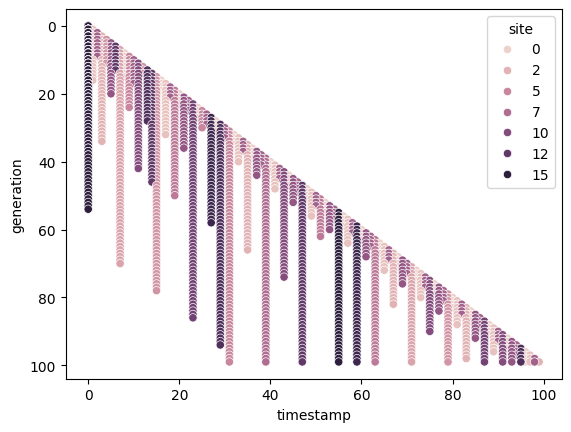

In [31]:
sns.scatterplot(
    data=surface_timestamps_df,
    x="timestamp",
    y="generation",
    hue="site",
).invert_yaxis()


<Axes: xlabel='generation', ylabel='timestamp'>

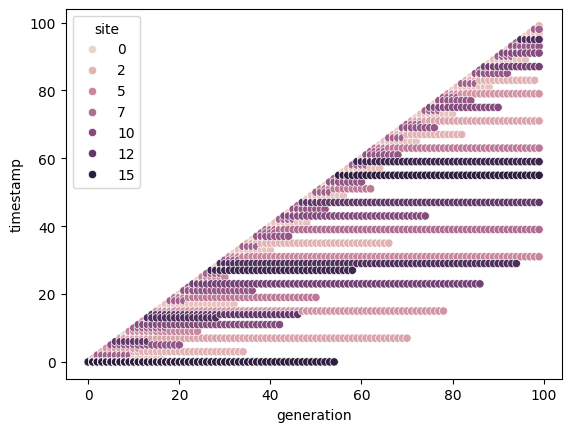

In [32]:
sns.scatterplot(
    data=surface_timestamps_df,
    x="generation",
    y="timestamp",
    hue="site",
)


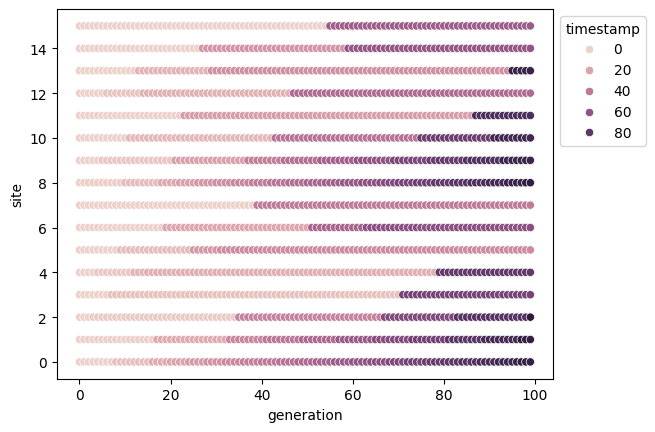

In [33]:
ax = sns.scatterplot(
    data=surface_timestamps_df,
    x="generation",
    y="site",
    hue="timestamp",
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


# 8-bit surface


In [34]:
surface_size = 8
num_generations = 50

surface_timestamps = [0] * surface_size
surface_values = [random.choice([0, 1]) for __ in range(surface_size)]


In [35]:
surface_timestamps_records = []
for generation in tqdm(range(num_generations)):
    target_site = get_ingest_site_at_rank(generation, surface_size)
    surface_values[target_site] = random.choice([0, 1])
    surface_timestamps[target_site] = generation

    assert [
        get_ingest_rank_at_site(site, surface_size, generation + 1)
        for site in range(surface_size)
    ] == surface_timestamps

    for site, timestamp in enumerate(surface_timestamps):
        surface_timestamps_records.append(
            {
                "generation": generation,
                "site": site,
                "timestamp": timestamp,
            }
        )


100%|██████████| 50/50 [00:00<00:00, 6157.95it/s]


In [36]:
surface_timestamps_df = pd.DataFrame.from_records(surface_timestamps_records)
surface_timestamps_df


,generation,site,timestamp
0,0,0,0
1,0,1,0
2,0,2,0
3,0,3,0
4,0,4,0
...,...,...,...
395,49,3,39
396,49,4,47
397,49,5,31
398,49,6,43


In [37]:
def scatter_invert(*args, **kwargs):
    ax = sns.scatterplot(*args, **kwargs)
    ax.invert_yaxis()


teeplots/03/hue=site+viz=scatter-invert+x=timestamp+y=generation+ext=.pdf
teeplots/03/hue=site+viz=scatter-invert+x=timestamp+y=generation+ext=.png


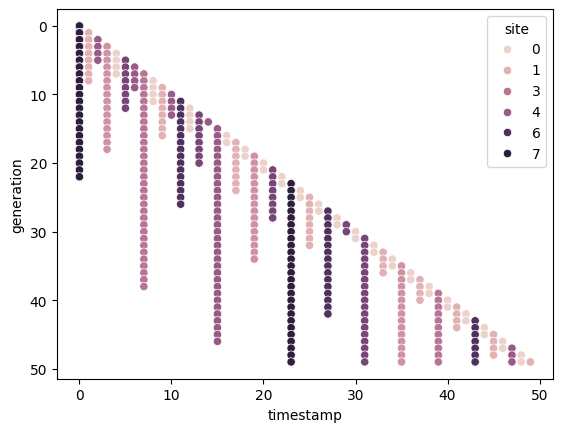

In [38]:
pylib.tee_release(
    scatter_invert,
    data=surface_timestamps_df,
    x="timestamp",
    y="generation",
    hue="site",
    teeplot_subdir="03",
)


teeplots/03/hue=site+viz=scatterplot+x=generation+y=timestamp+ext=.pdf
teeplots/03/hue=site+viz=scatterplot+x=generation+y=timestamp+ext=.png


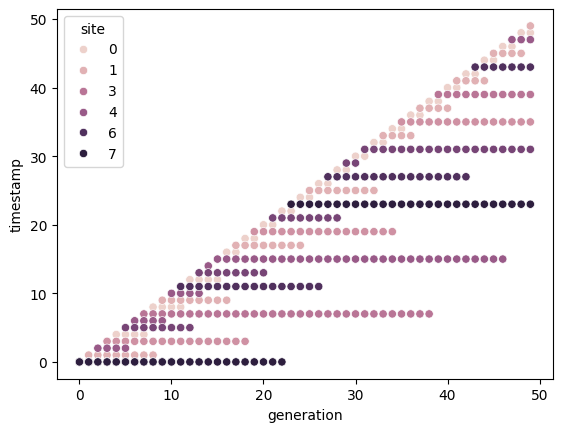

<Axes: xlabel='generation', ylabel='timestamp'>

In [39]:
pylib.tee_release(
    sns.scatterplot,
    data=surface_timestamps_df,
    x="generation",
    y="timestamp",
    hue="site",
    teeplot_subdir="03",
)


In [40]:
def scatterplot_legout(*args, **kwargs):
    ax = sns.scatterplot(
        *args,
        **kwargs,
    )
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


teeplots/03/hue=timestamp+viz=scatterplot-legout+x=generation+y=site+ext=.pdf
teeplots/03/hue=timestamp+viz=scatterplot-legout+x=generation+y=site+ext=.png


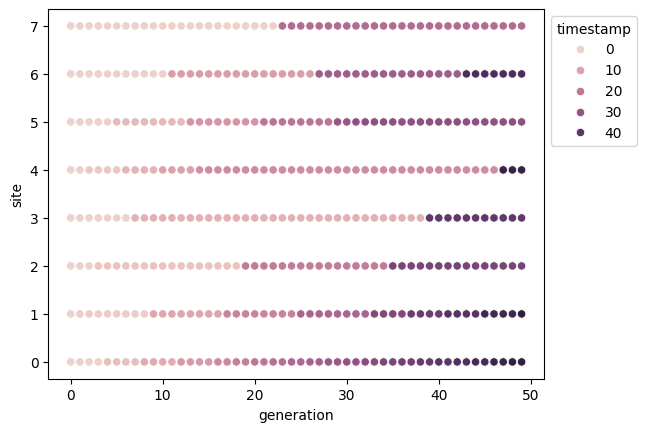

In [41]:
pylib.tee_release(
    scatterplot_legout,
    data=surface_timestamps_df,
    x="generation",
    y="site",
    hue="timestamp",
    teeplot_subdir="03",
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


# Visualize


In [42]:
def get_surface_rank_capacity(surface_size: int) -> int:
    return pylib.hanoi.get_index_of_hanoi_value_nth_incidence(surface_size, 0)


100%|██████████| 127/127 [00:00<00:00, 121007.86it/s]


teeplots/03/num-generations=127+surface-size=8+viz=site-differentia-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/num-generations=127+surface-size=8+viz=site-differentia-by-rank-heatmap+ynorm=log+ext=.png


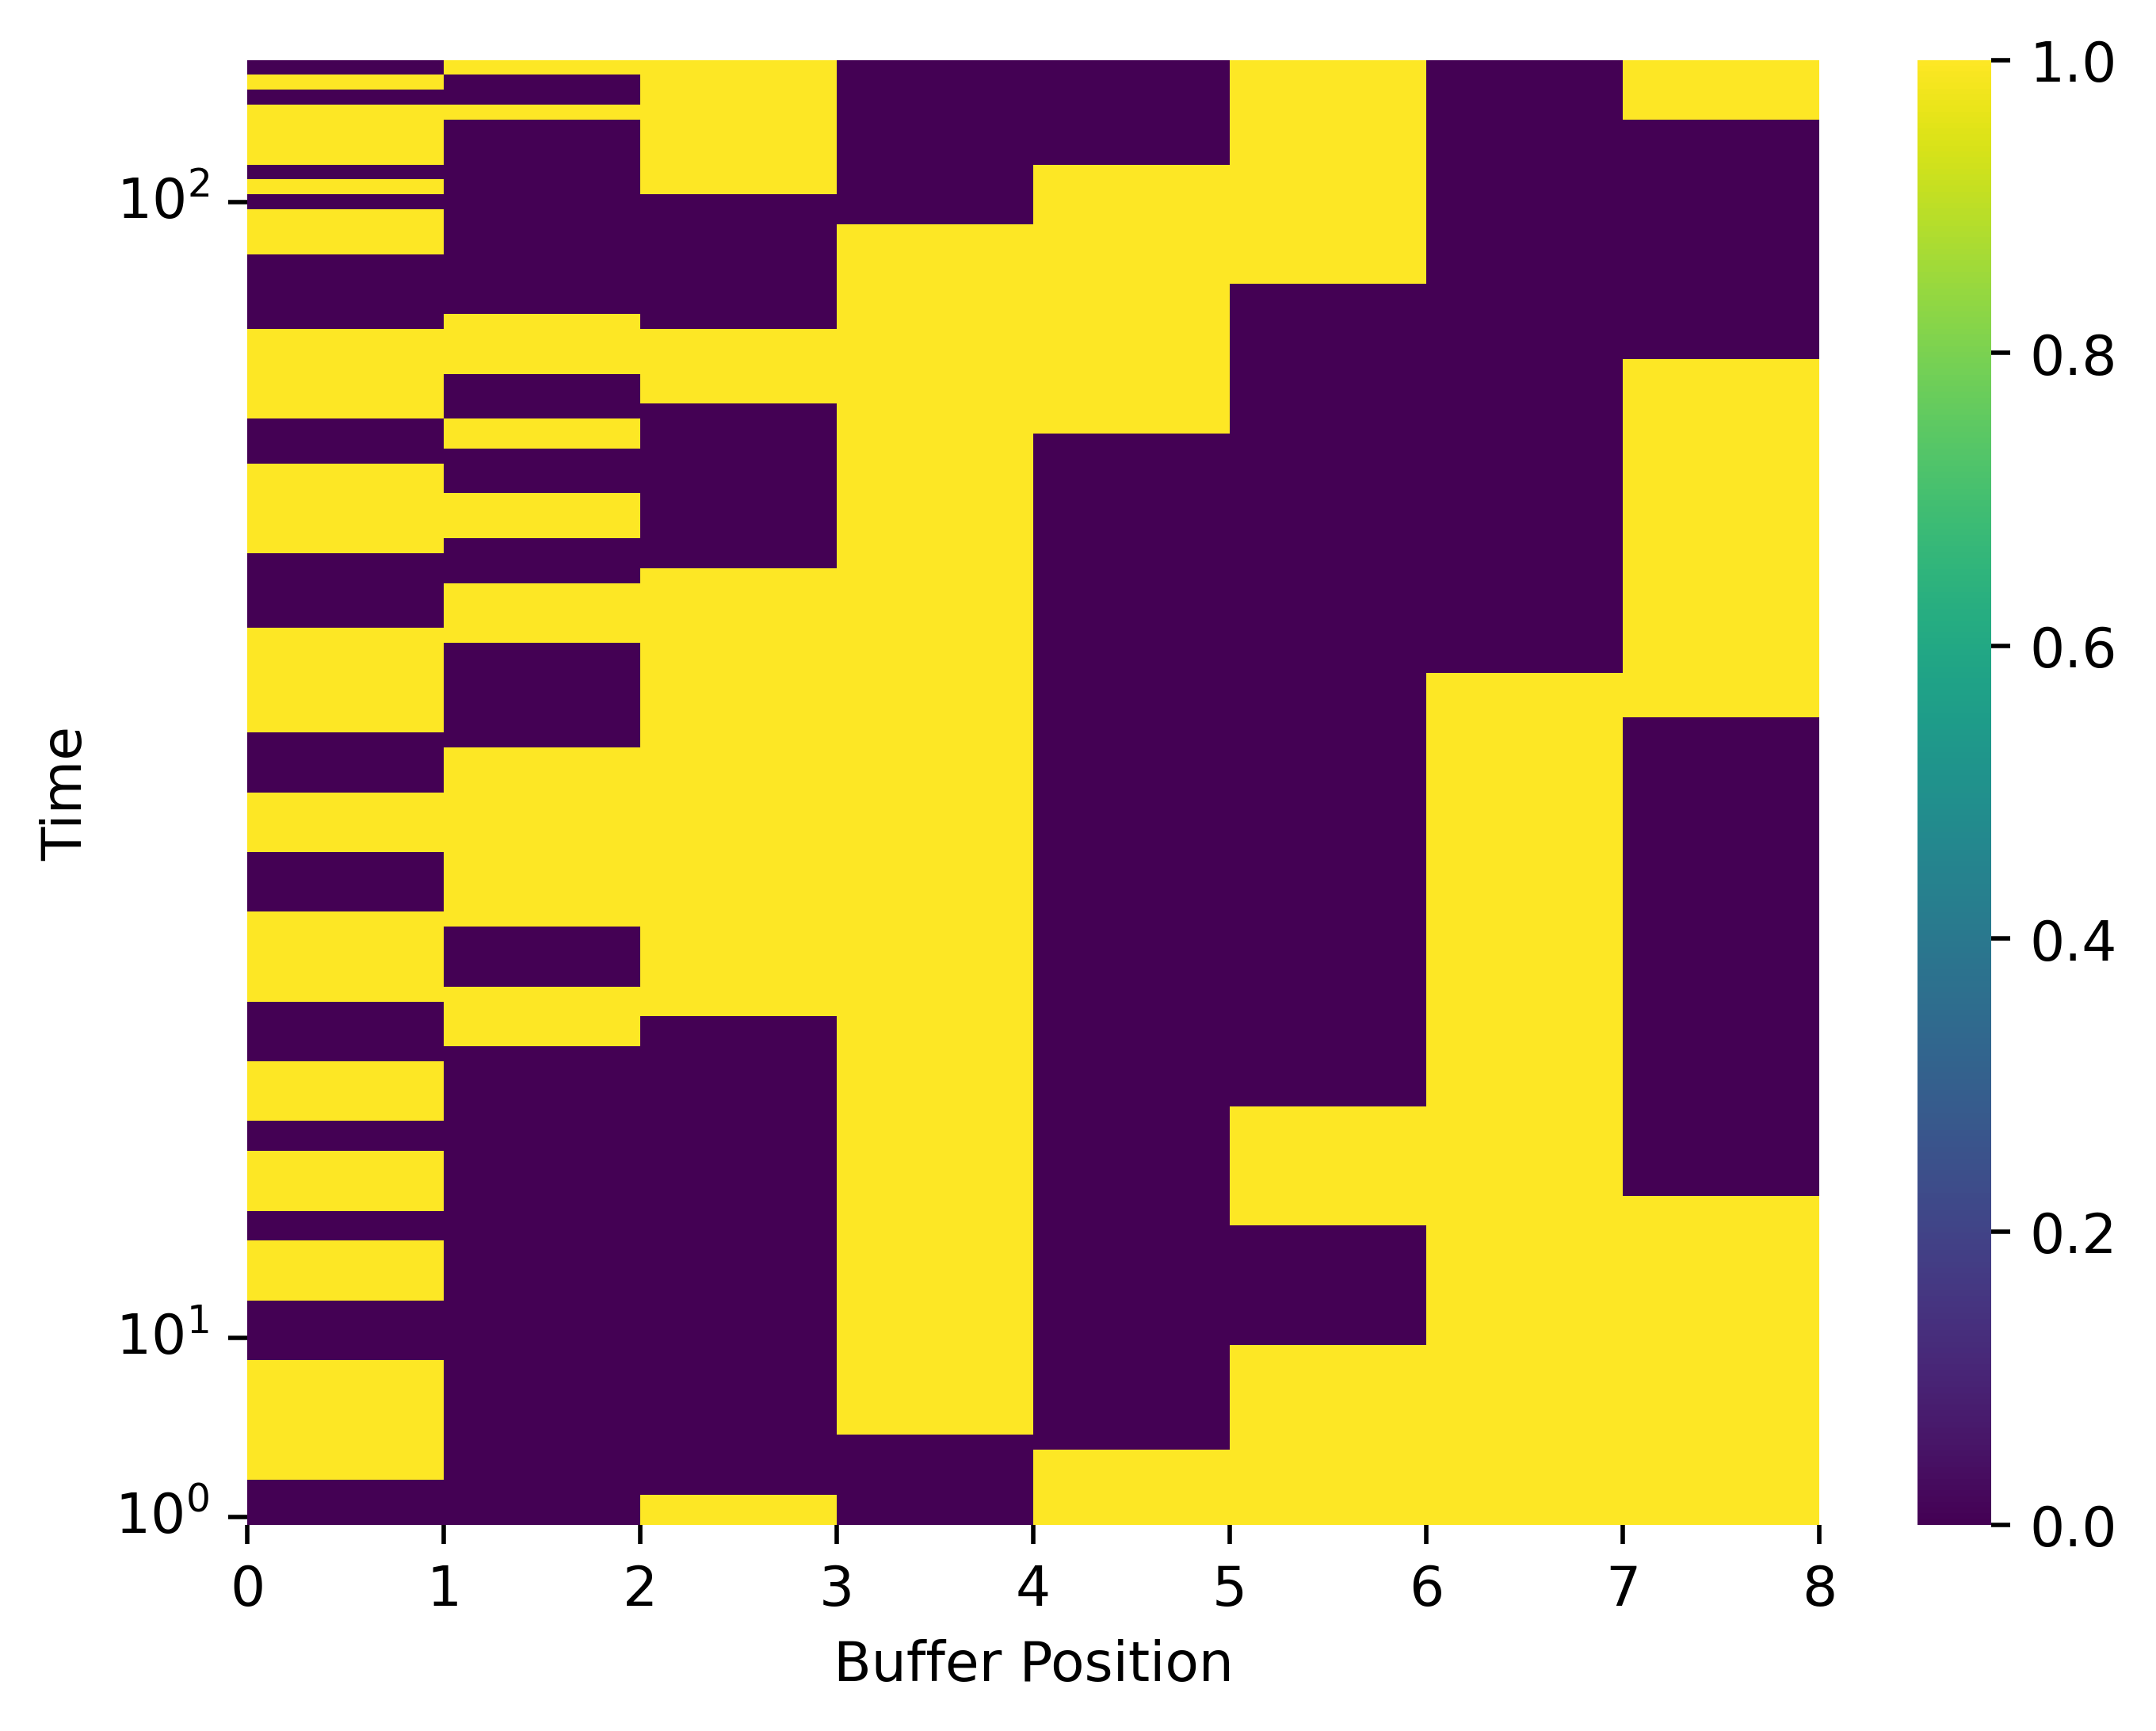

teeplots/03/num-generations=127+surface-size=8+viz=site-differentia-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/num-generations=127+surface-size=8+viz=site-differentia-by-rank-heatmap+ynorm=linear+ext=.png


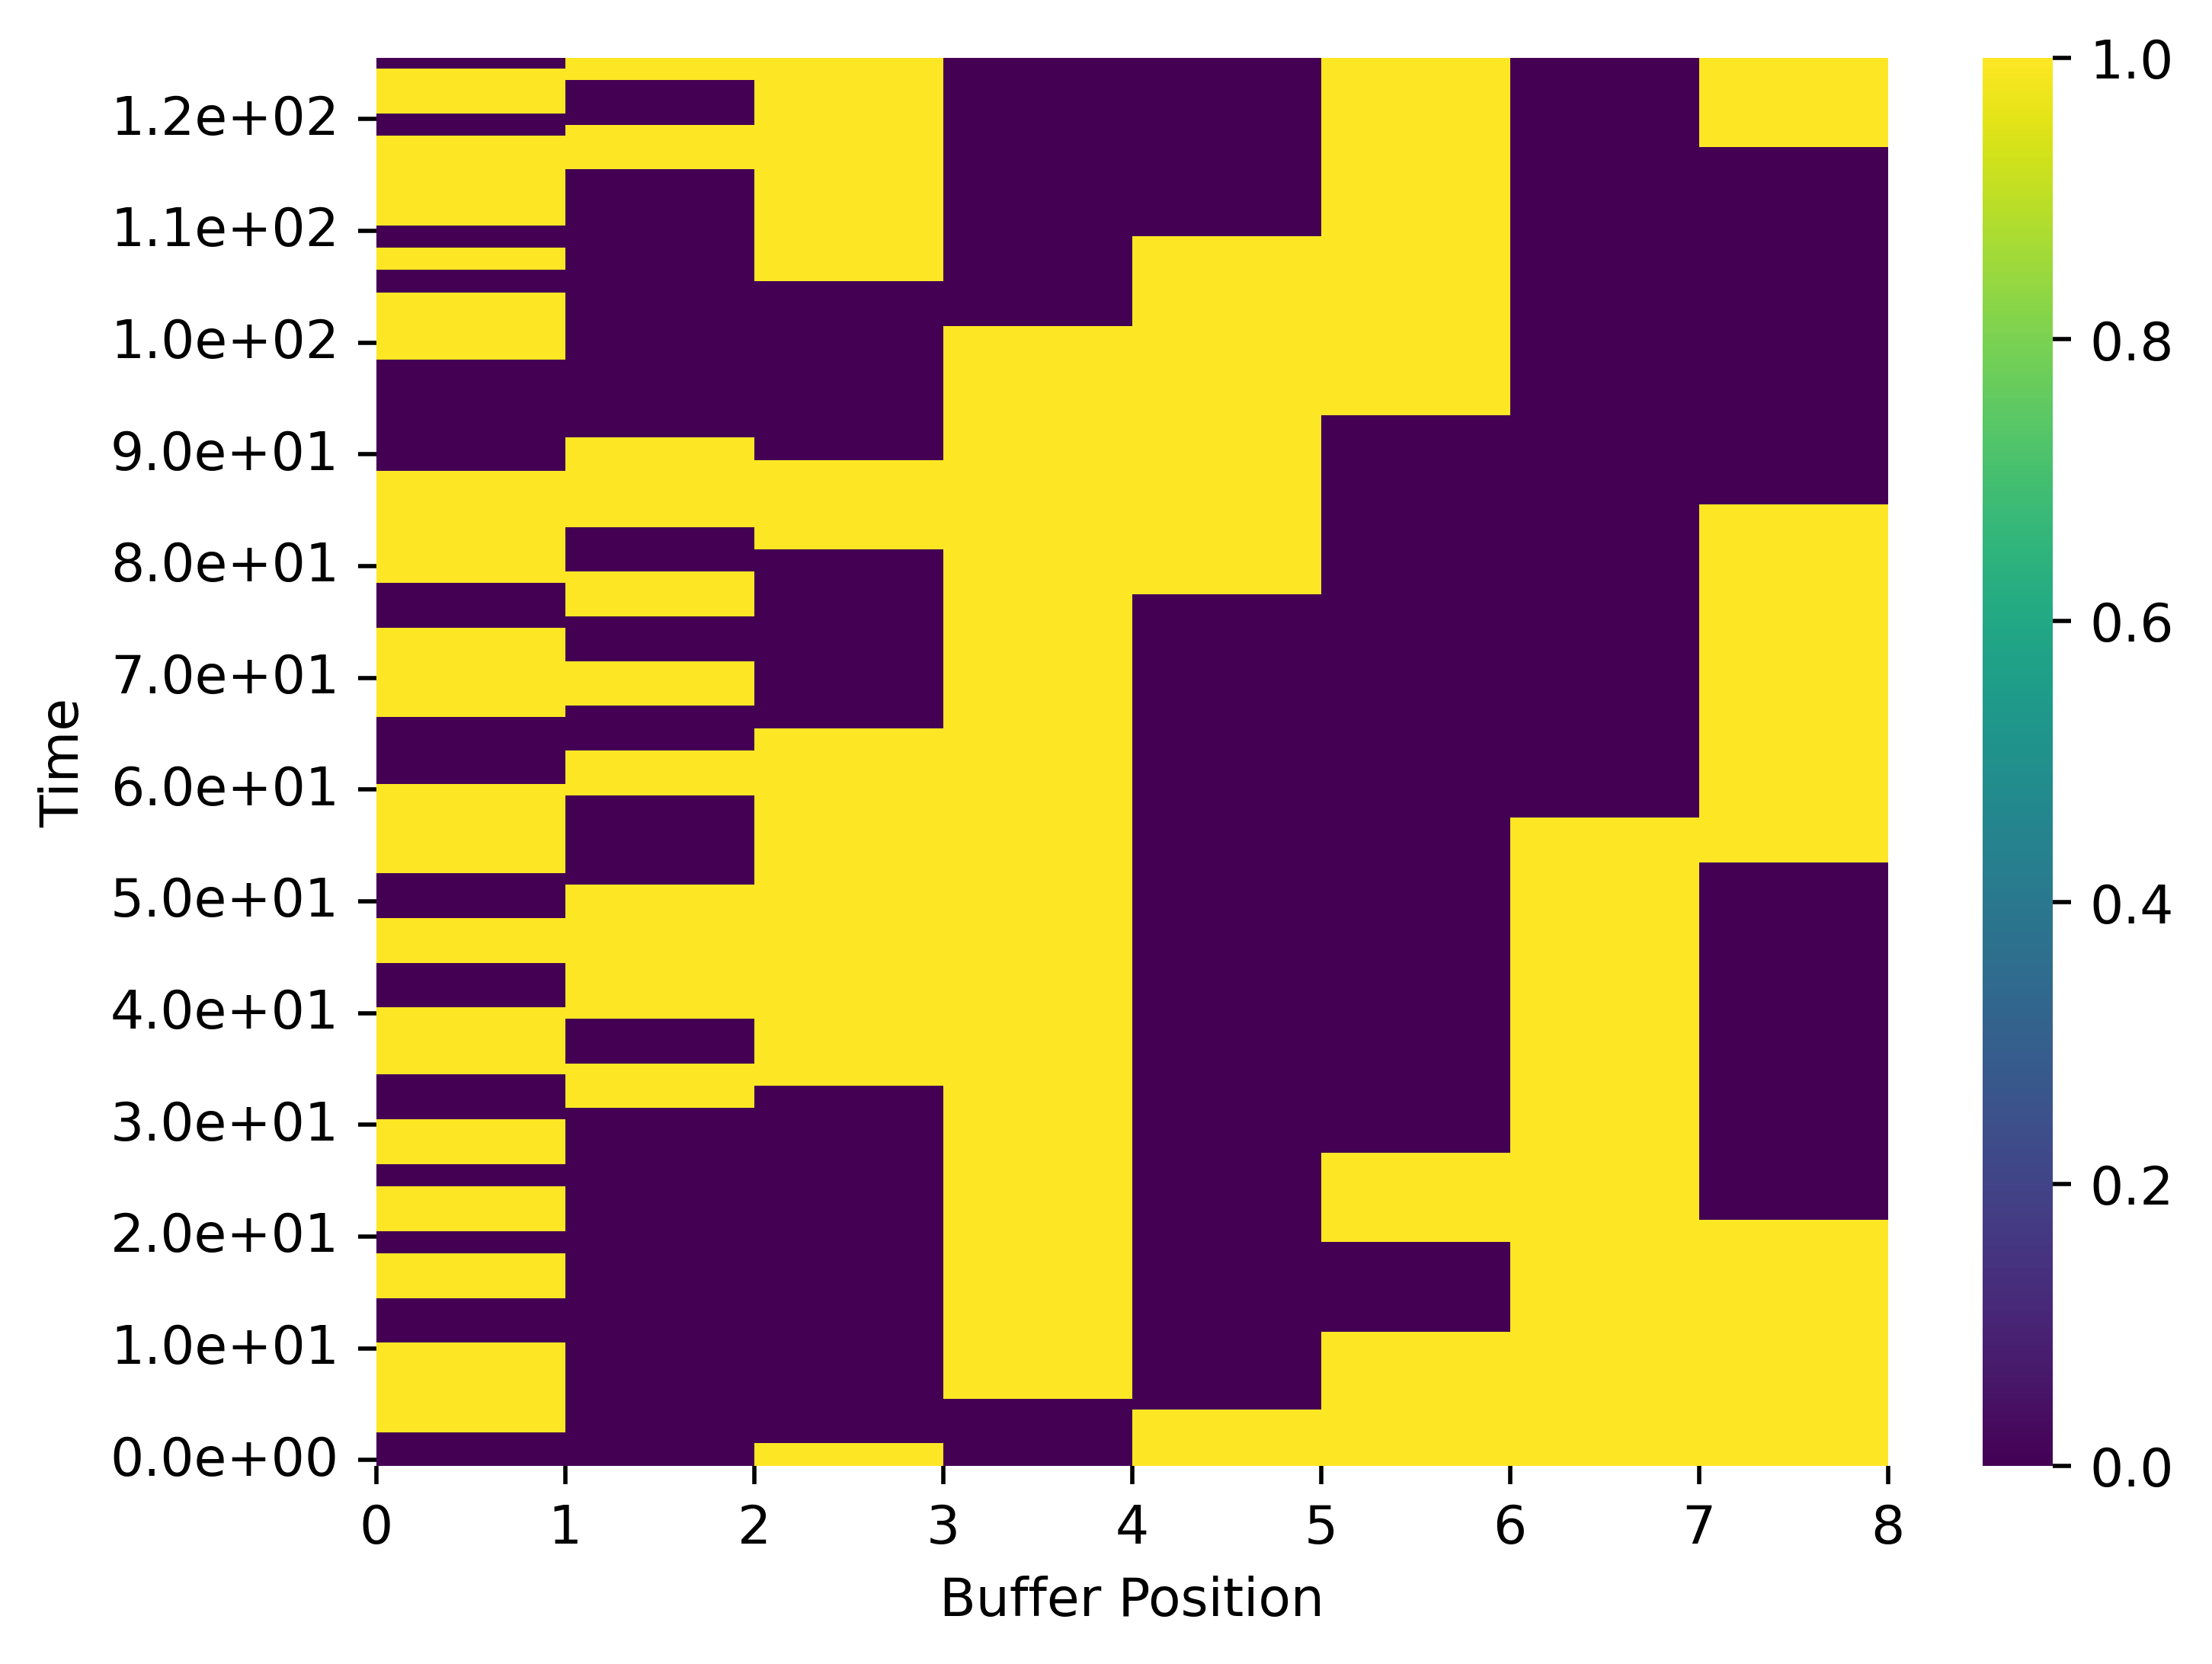

teeplots/03/cnorm=log+num-generations=127+surface-size=8+viz=site-ingest-rank-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/cnorm=log+num-generations=127+surface-size=8+viz=site-ingest-rank-by-rank-heatmap+ynorm=log+ext=.png


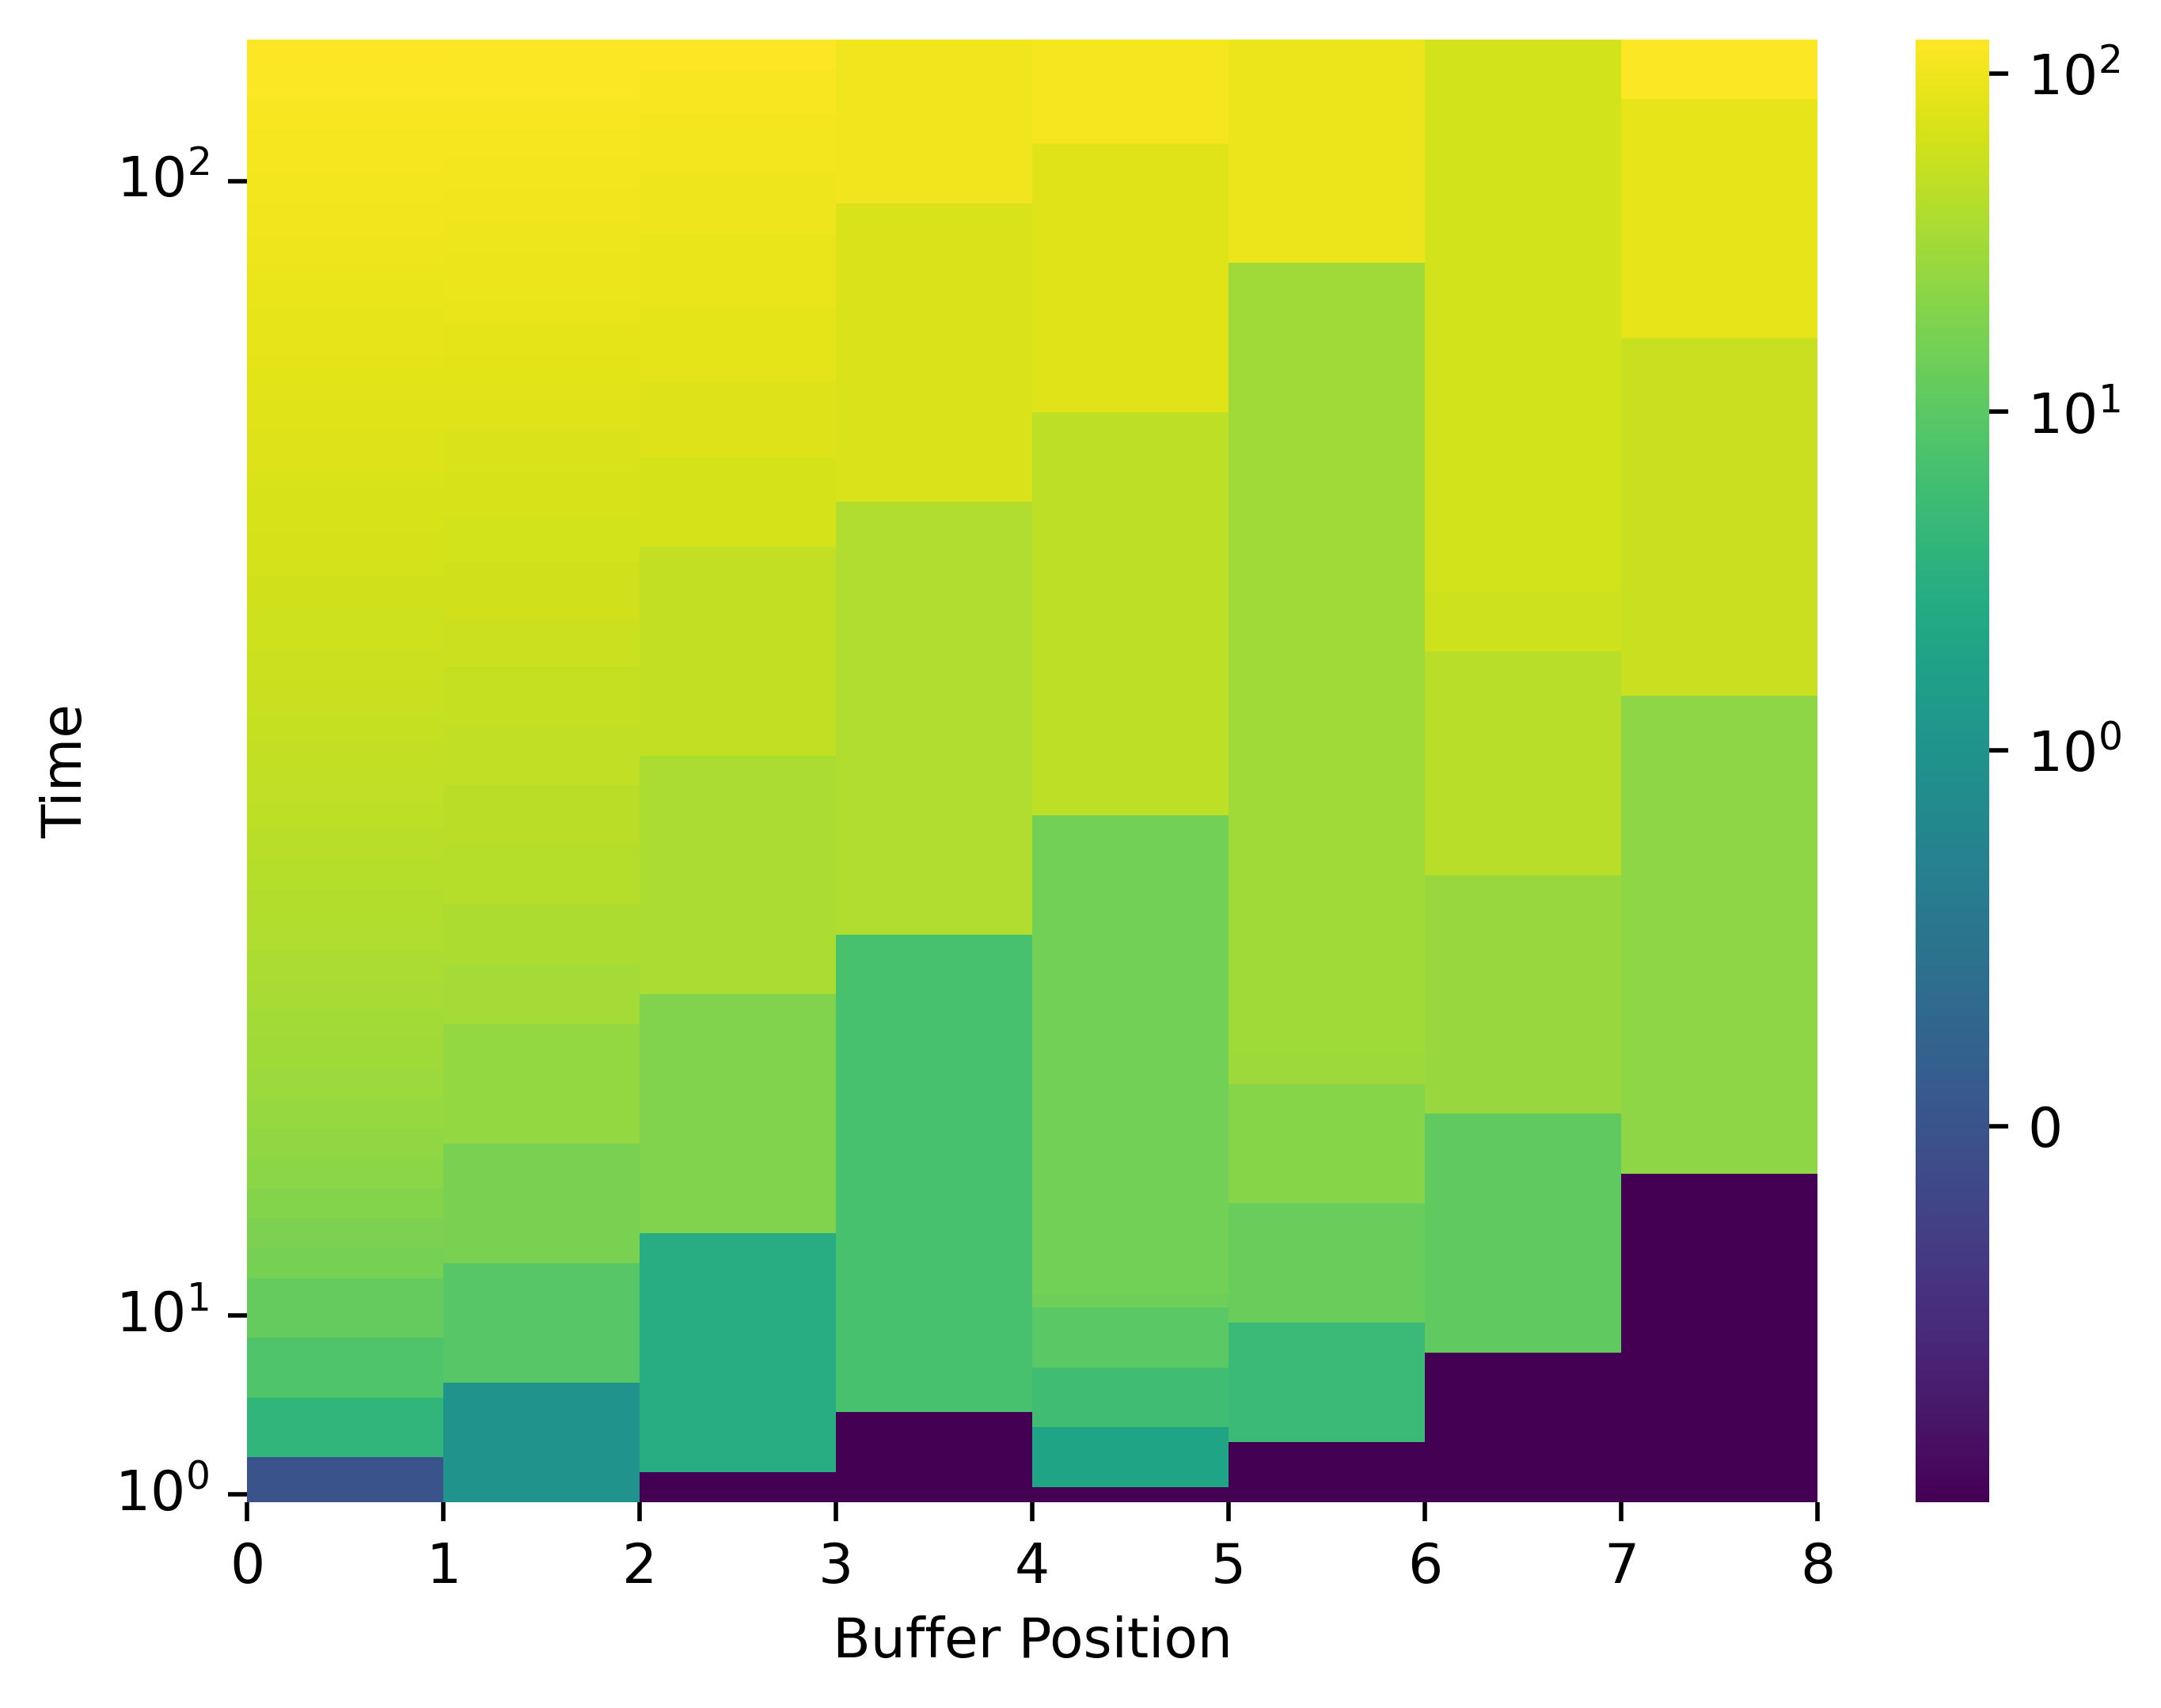

teeplots/03/cnorm=None+num-generations=127+surface-size=8+viz=site-ingest-rank-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/cnorm=None+num-generations=127+surface-size=8+viz=site-ingest-rank-by-rank-heatmap+ynorm=linear+ext=.png


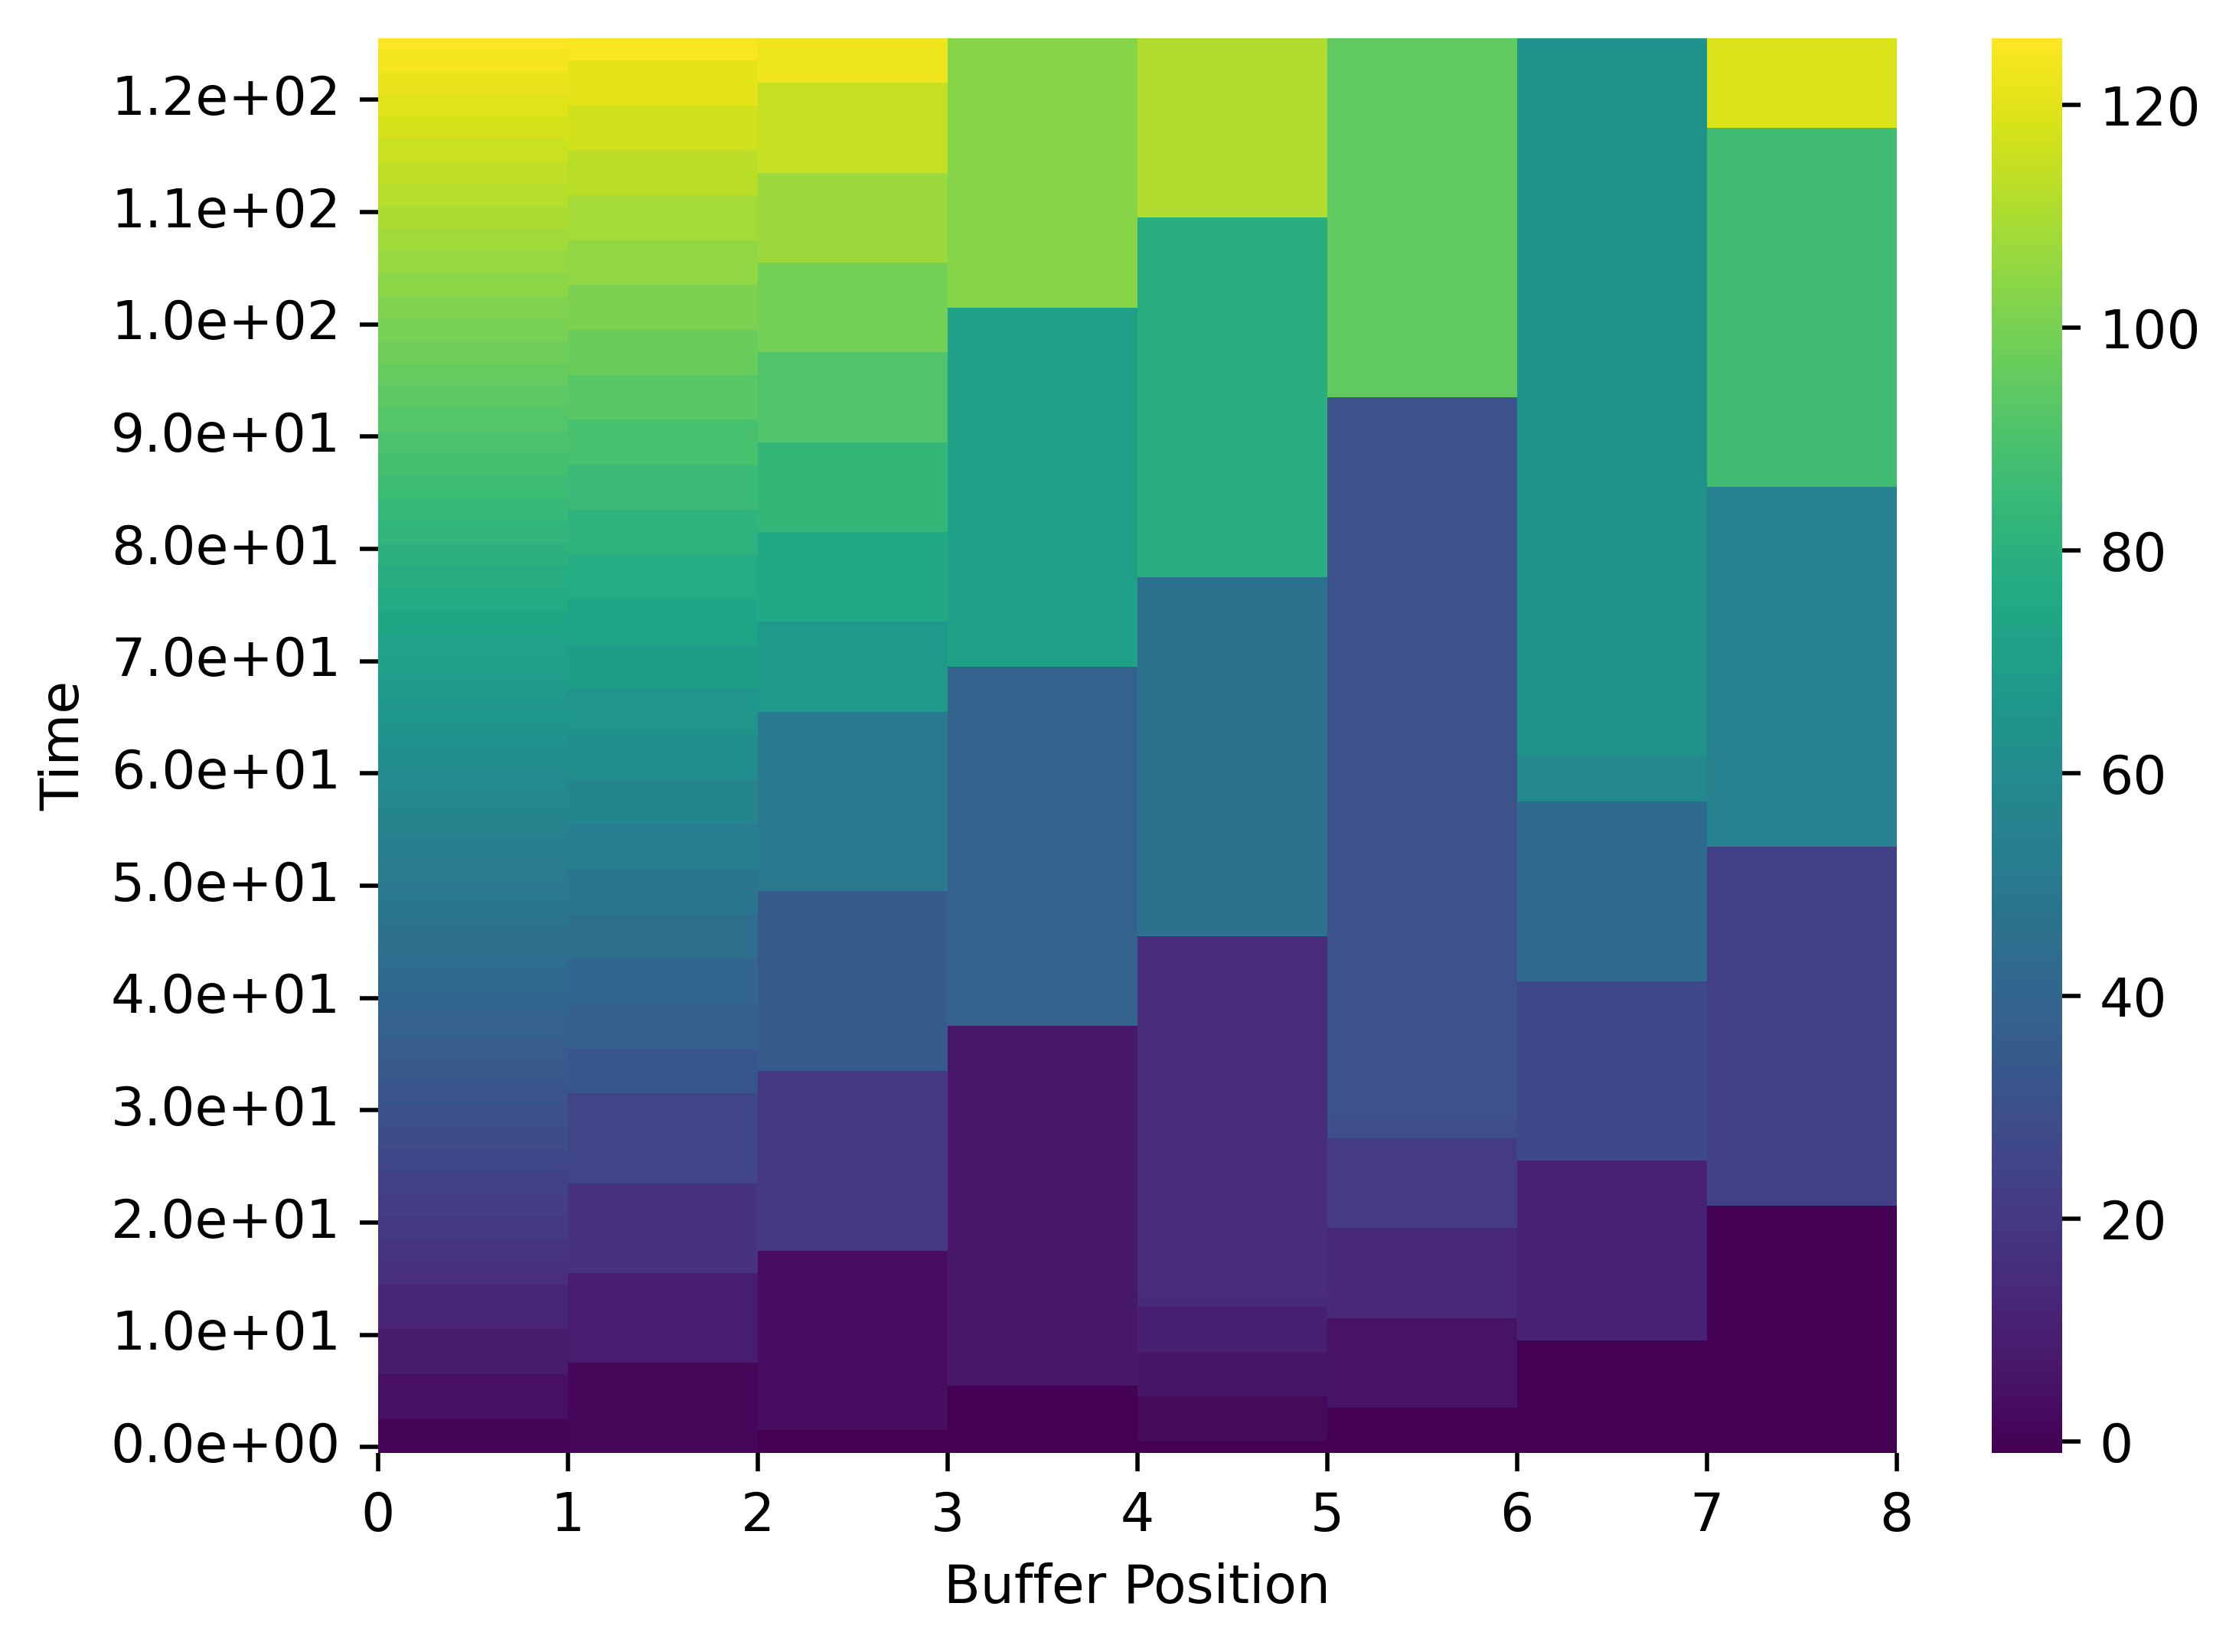

teeplots/03/num-generations=127+surface-size=8+viz=site-hanoi-value-by-rank-heatmap+ext=.pdf
teeplots/03/num-generations=127+surface-size=8+viz=site-hanoi-value-by-rank-heatmap+ext=.png


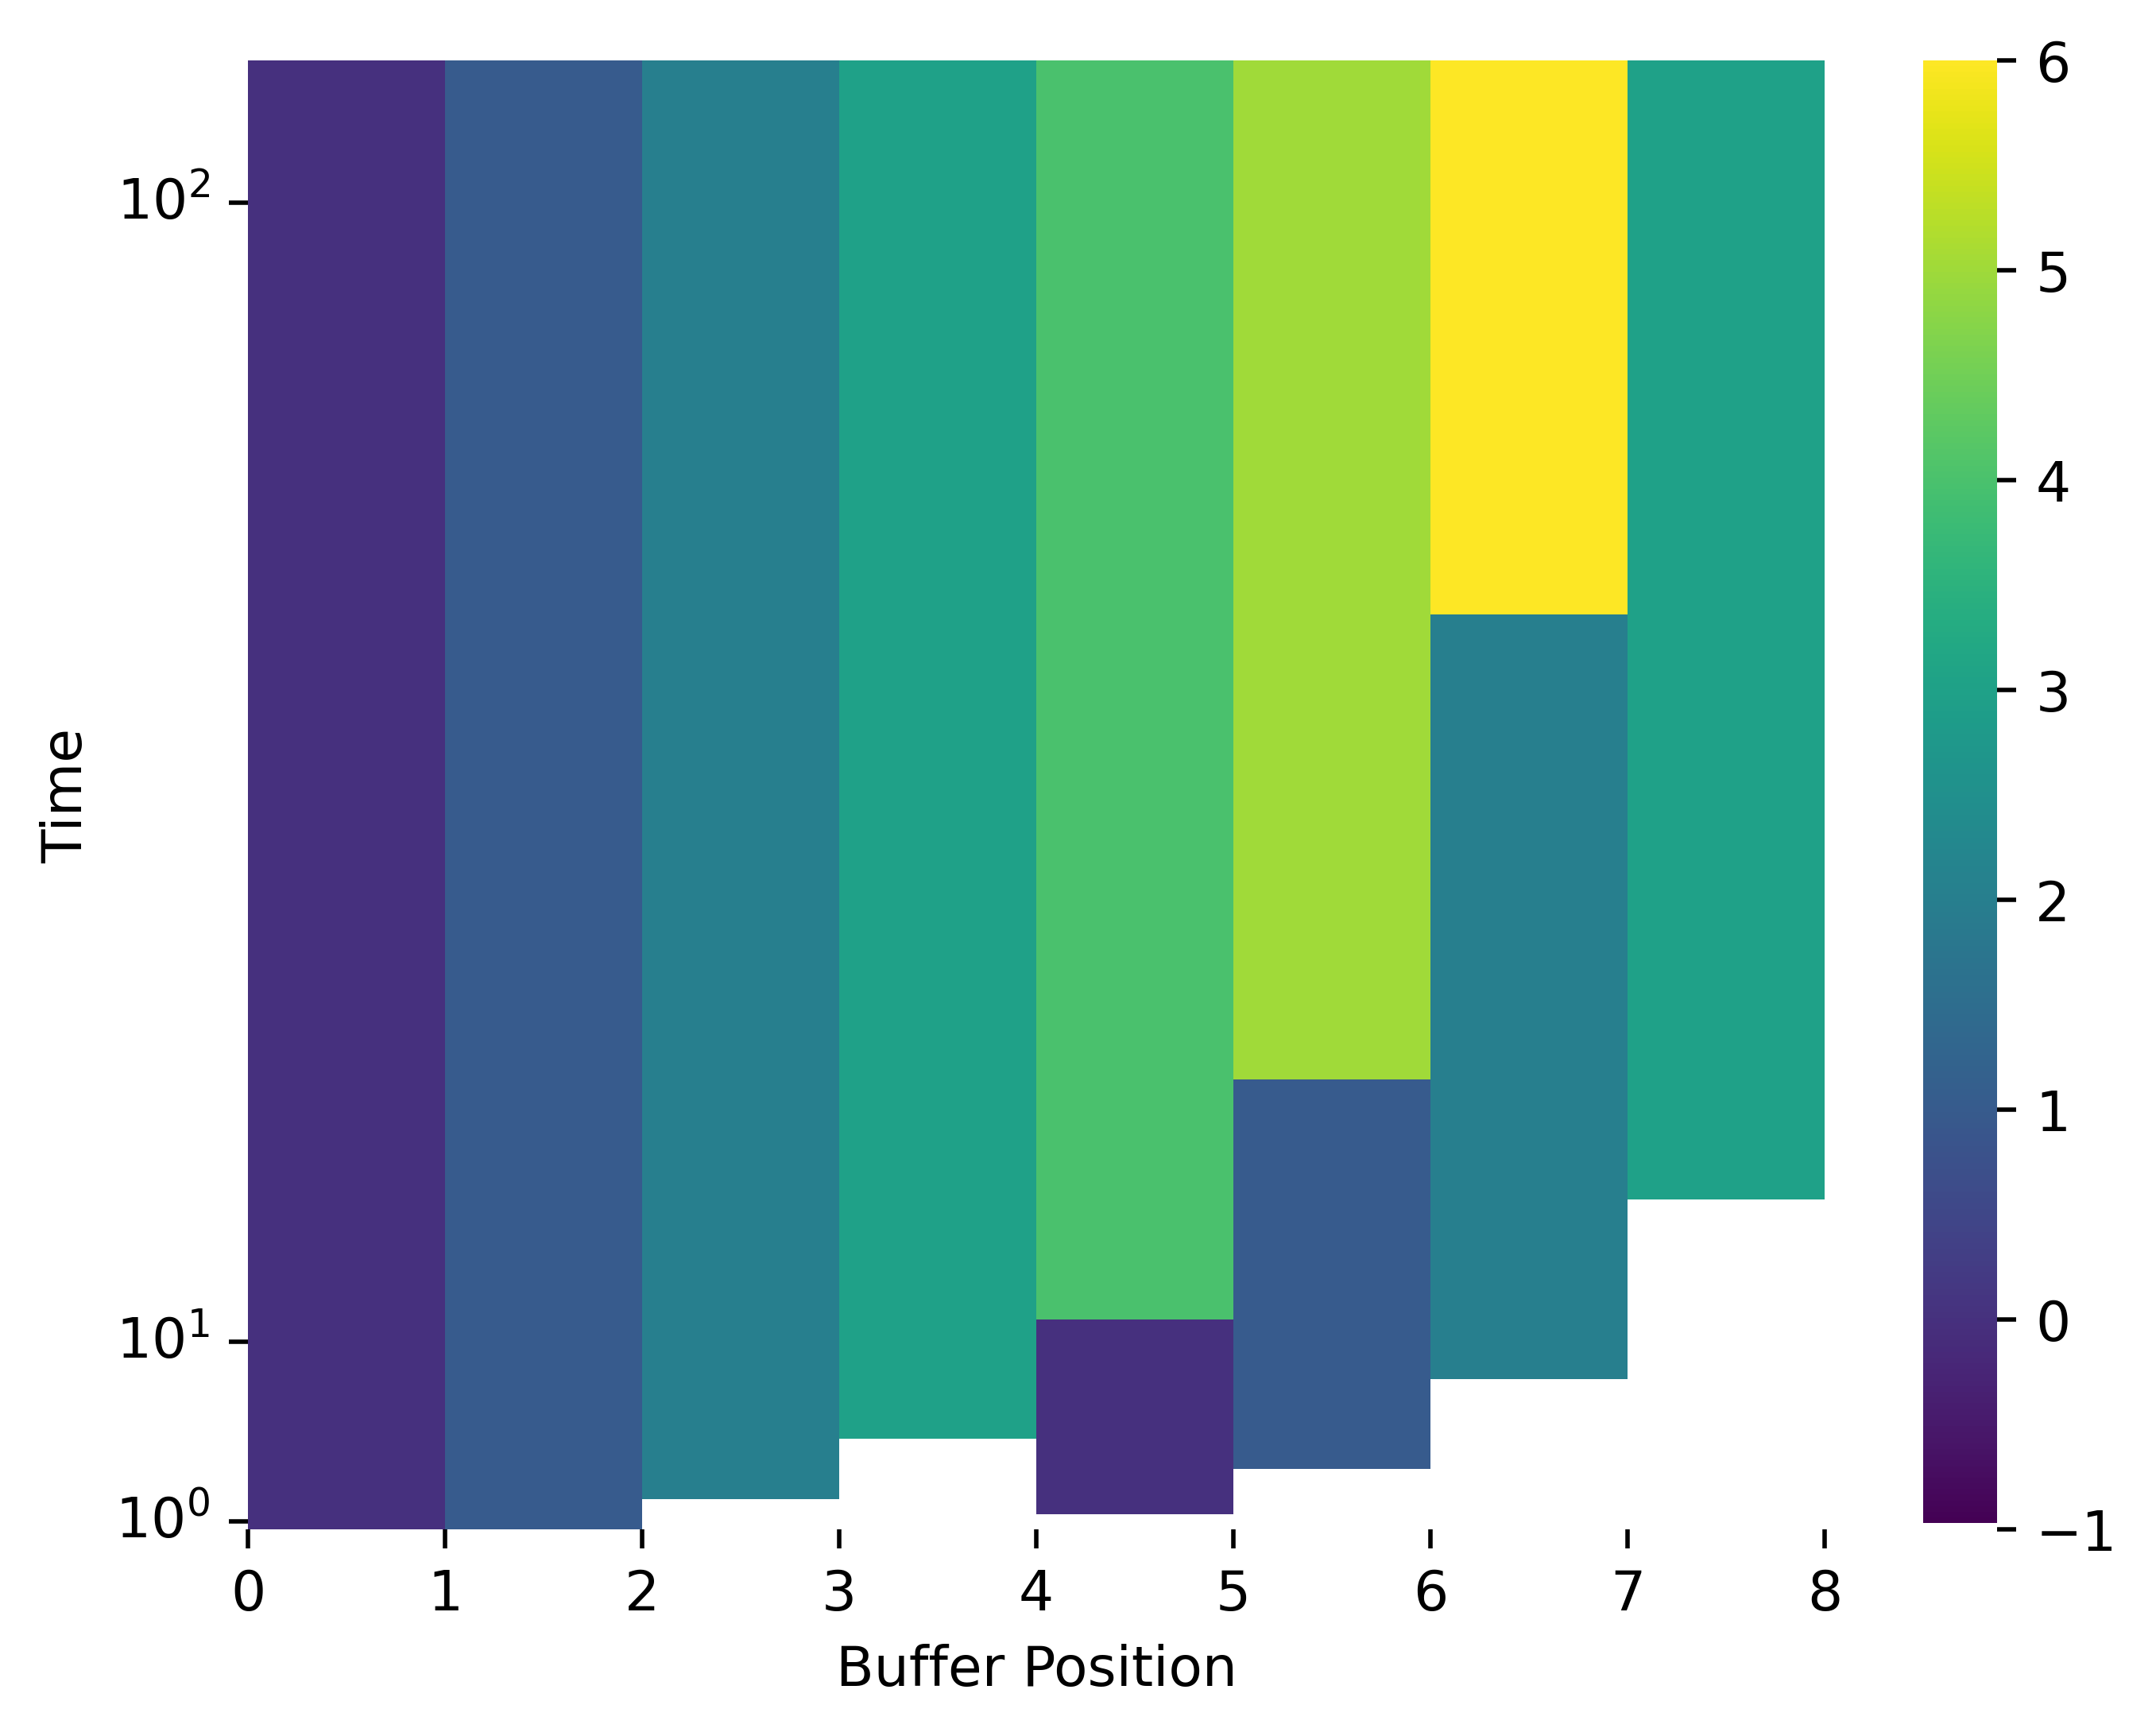

teeplots/03/num-generations=127+surface-size=8+viz=site-hanoi-value-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/num-generations=127+surface-size=8+viz=site-hanoi-value-by-rank-heatmap+ynorm=linear+ext=.png


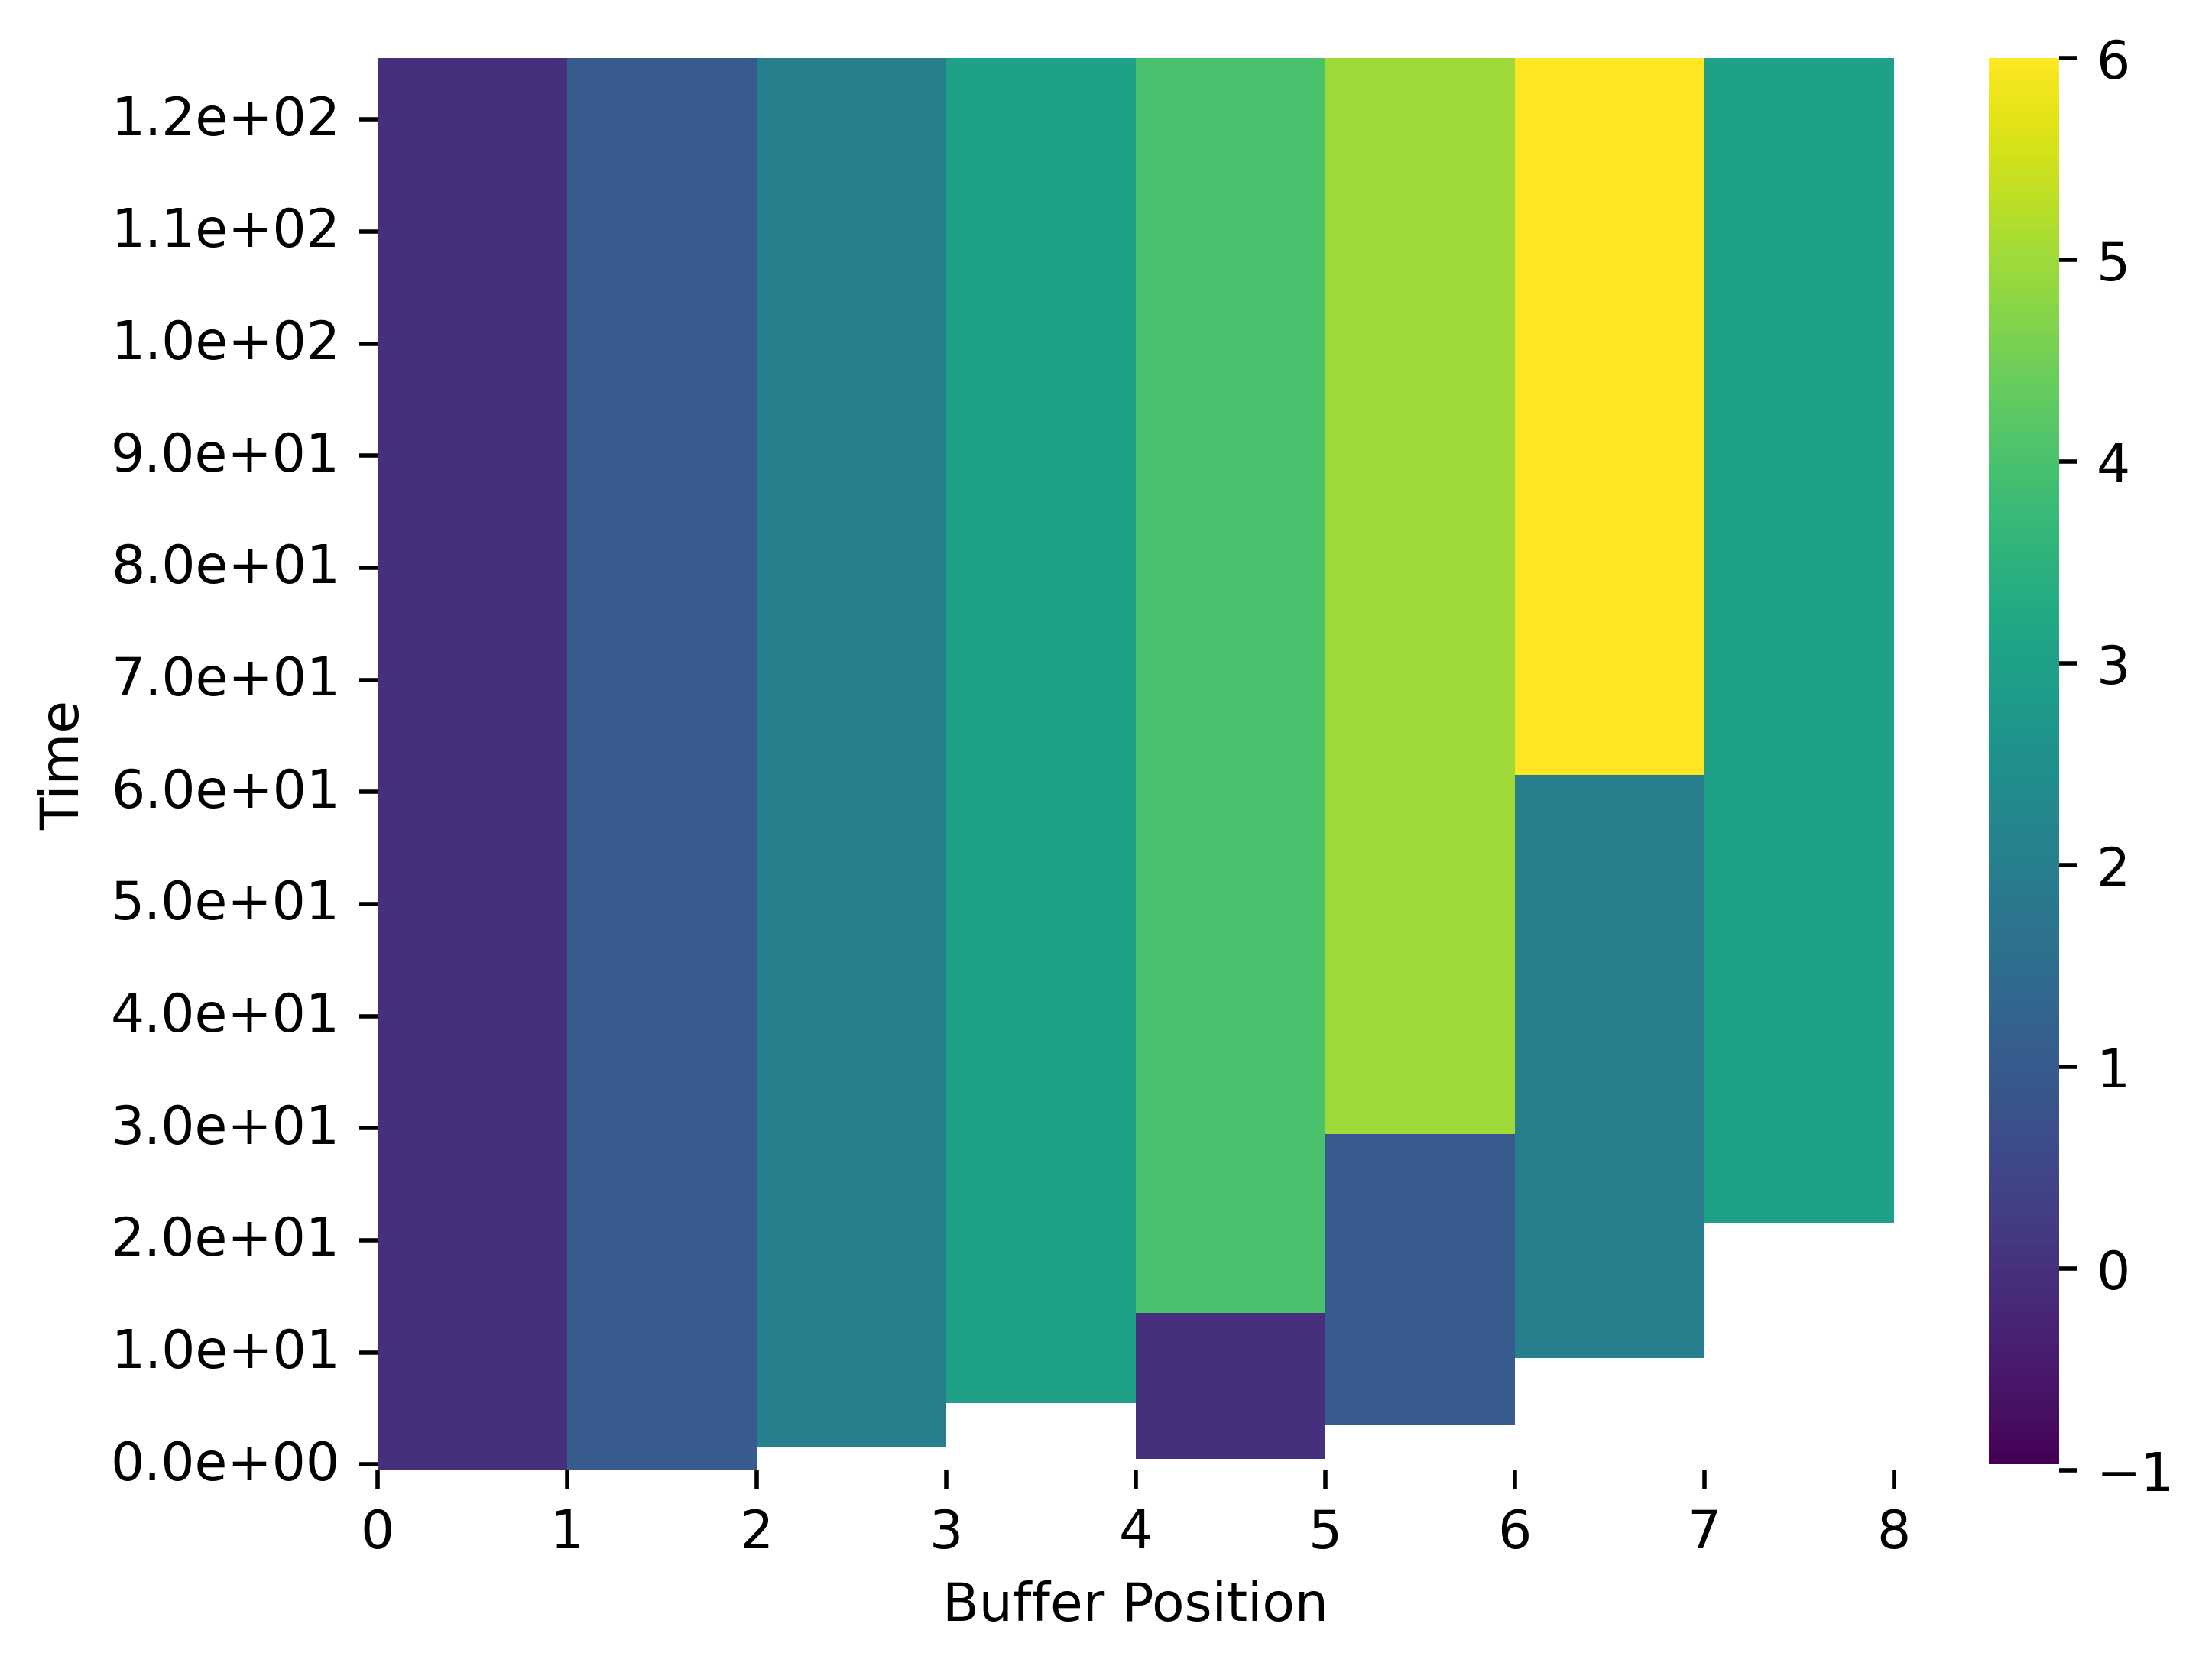

teeplots/03/cnorm=log+num-generations=127+surface-size=8+viz=site-ingest-depth-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/cnorm=log+num-generations=127+surface-size=8+viz=site-ingest-depth-by-rank-heatmap+ynorm=log+ext=.png


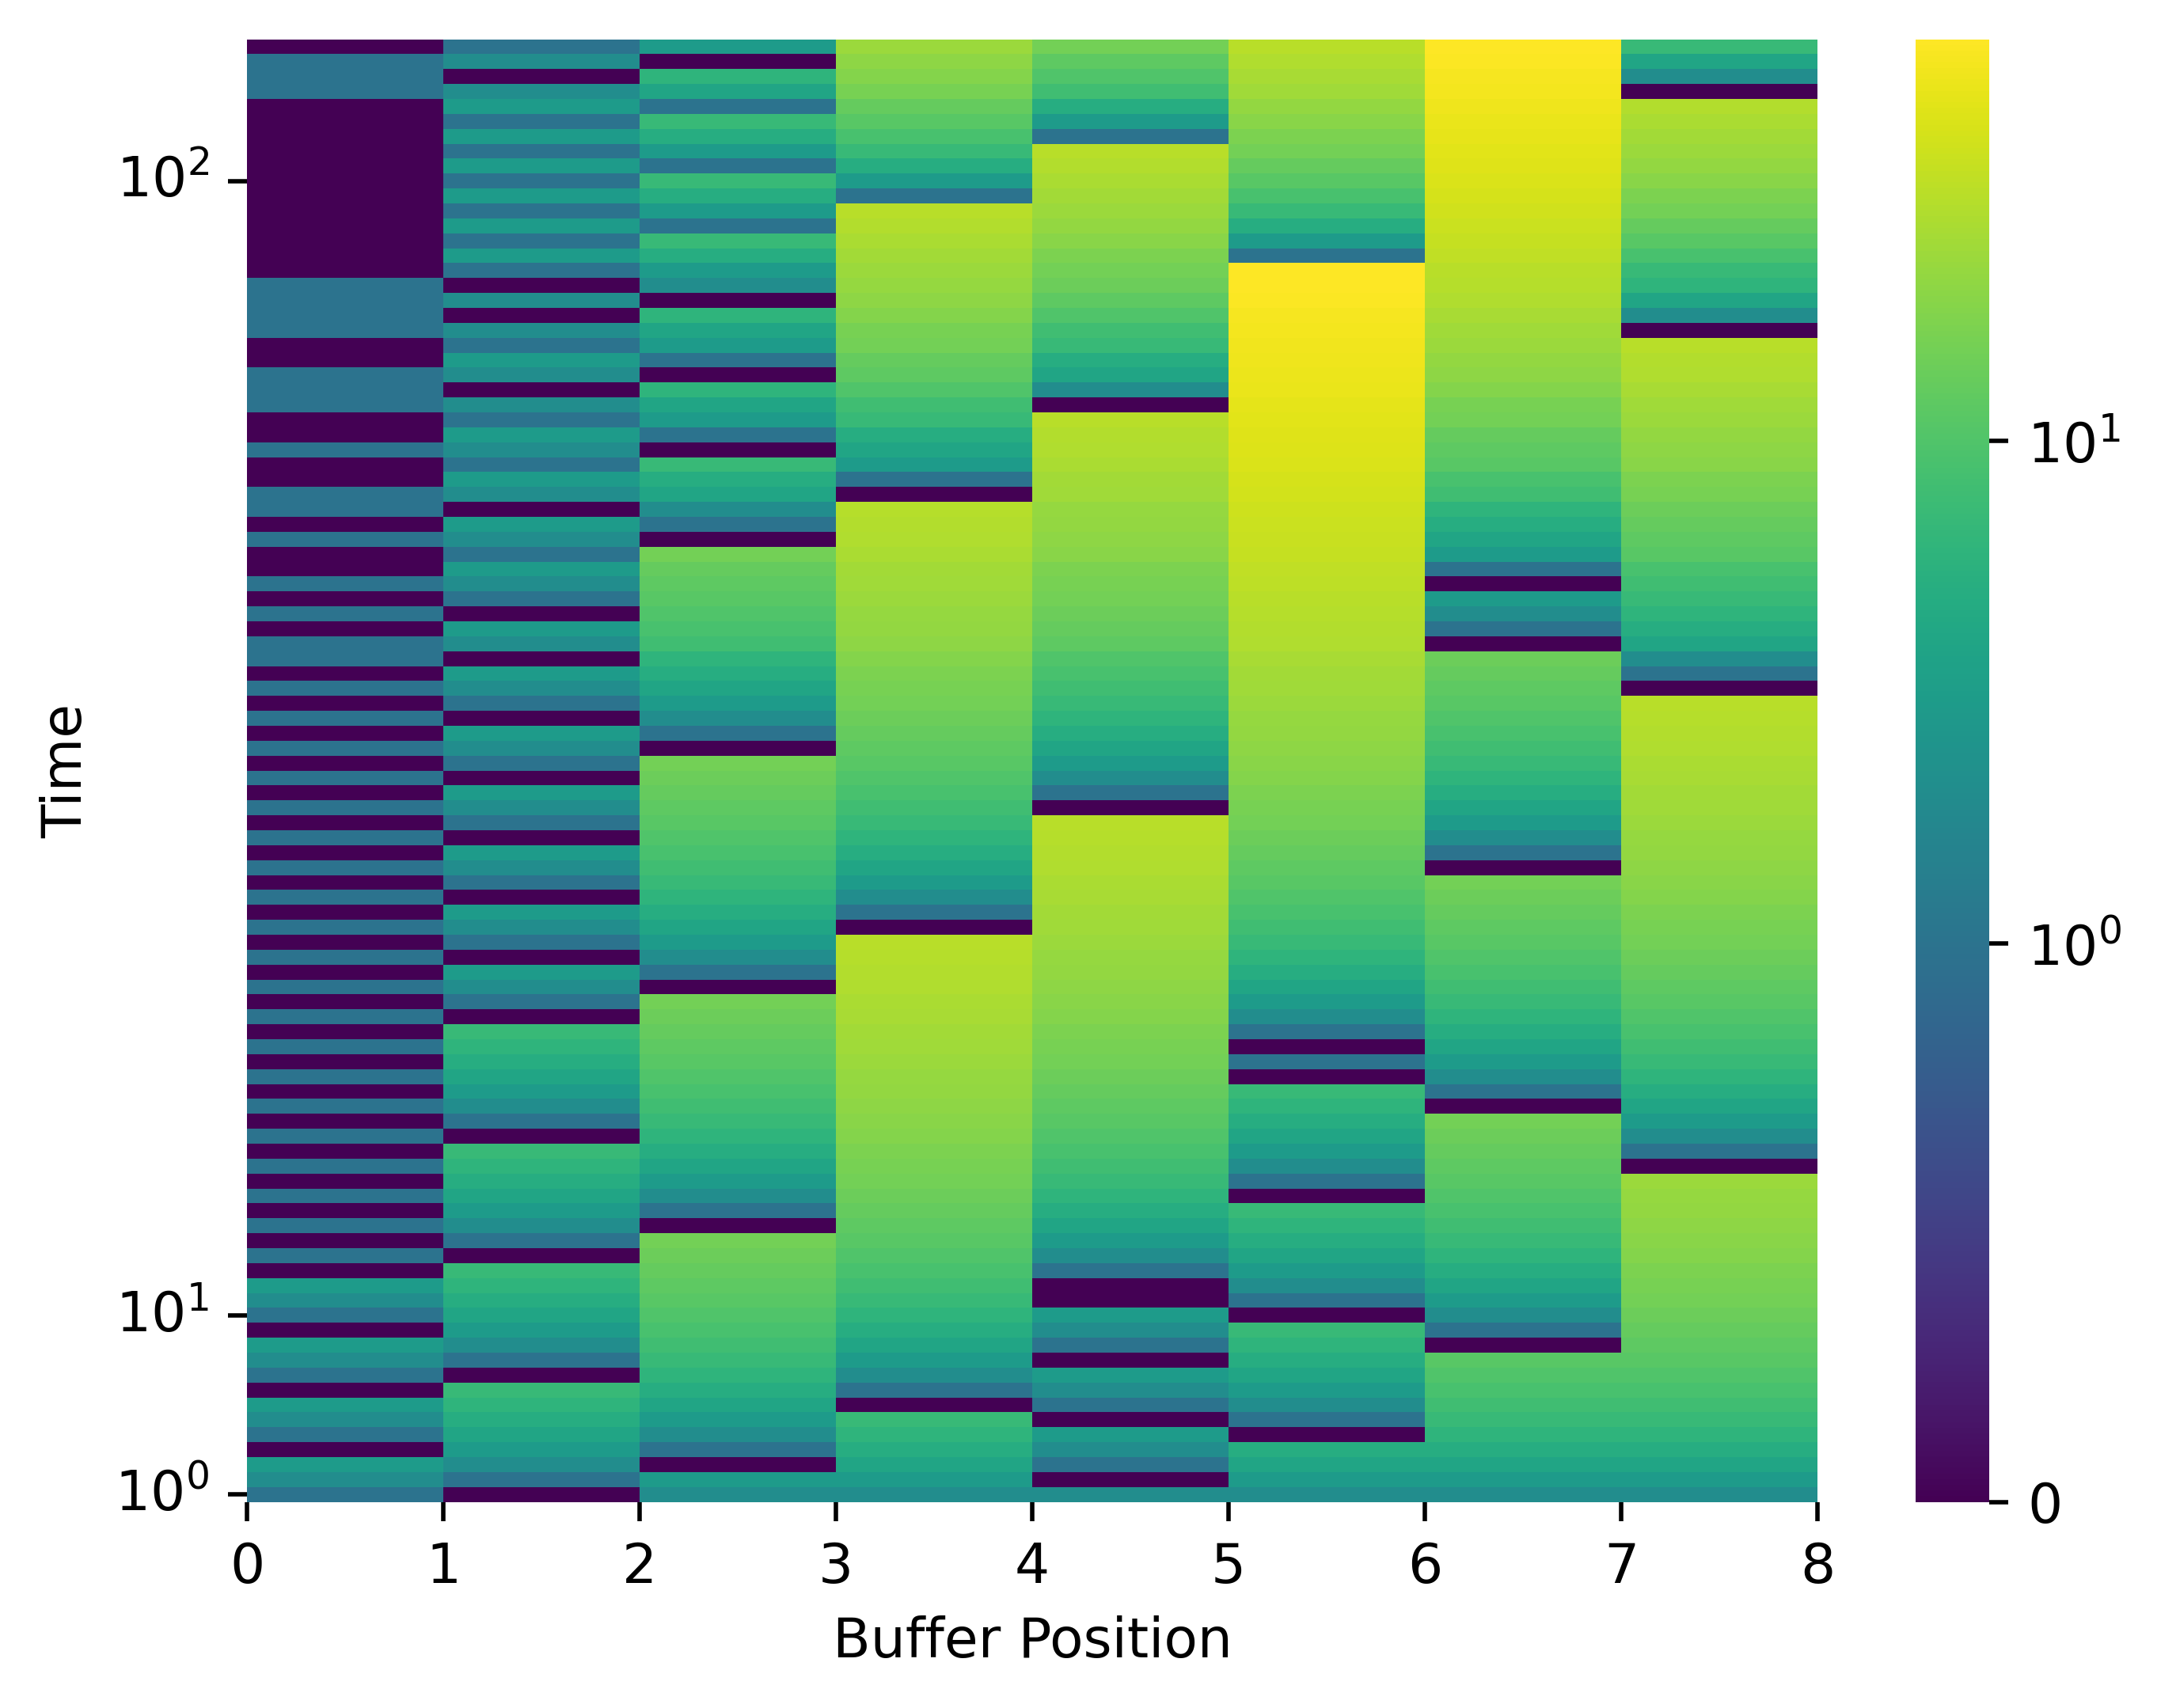

teeplots/03/cnorm=log+num-generations=127+surface-size=8+viz=site-ingest-depth-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/cnorm=log+num-generations=127+surface-size=8+viz=site-ingest-depth-by-rank-heatmap+ynorm=linear+ext=.png


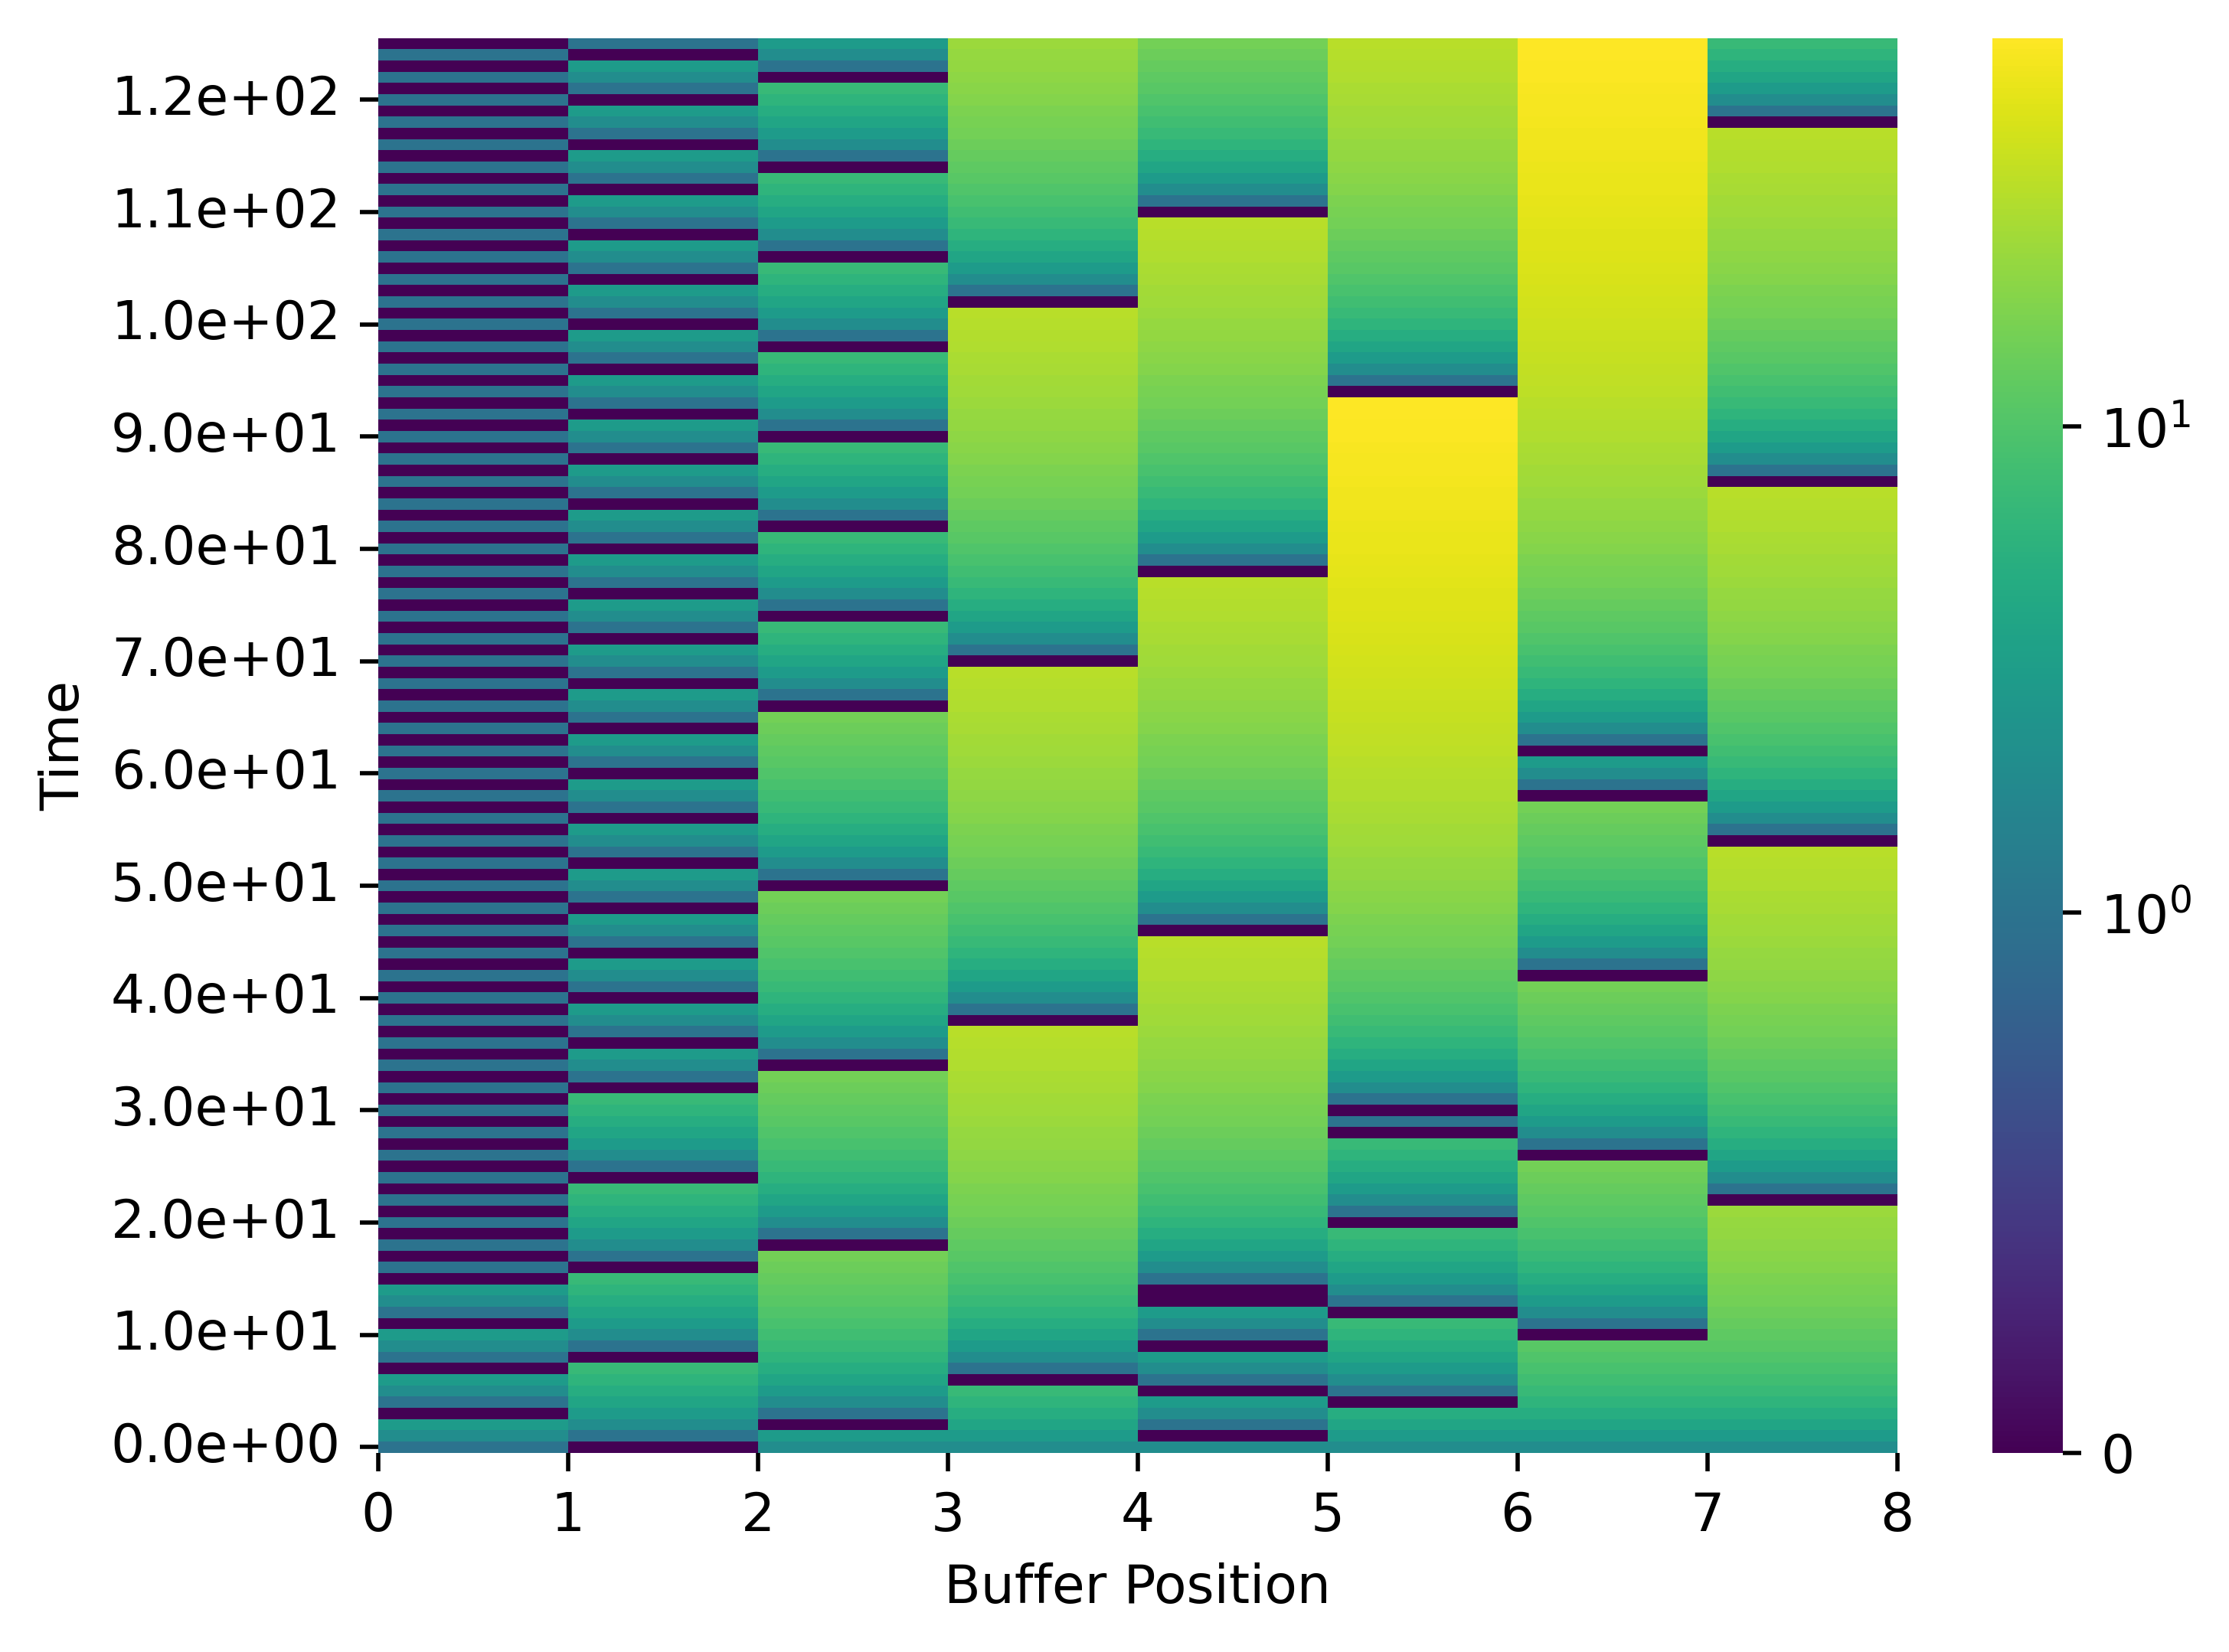

100%|██████████| 125/125 [00:00<00:00, 433.41it/s]


teeplots/03/num-generations=127+surface-size=8+viz=stratum-persistence-dripplot+ext=.pdf
teeplots/03/num-generations=127+surface-size=8+viz=stratum-persistence-dripplot+ext=.png


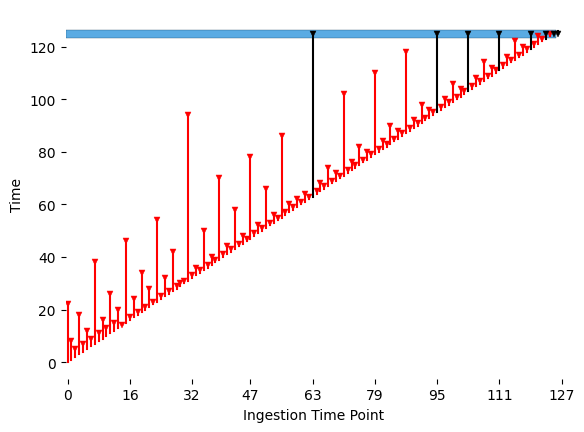

100%|██████████| 262144/262144 [00:04<00:00, 59081.00it/s]


teeplots/03/num-generations=262144+surface-size=32+viz=site-differentia-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/num-generations=262144+surface-size=32+viz=site-differentia-by-rank-heatmap+ynorm=log+ext=.png


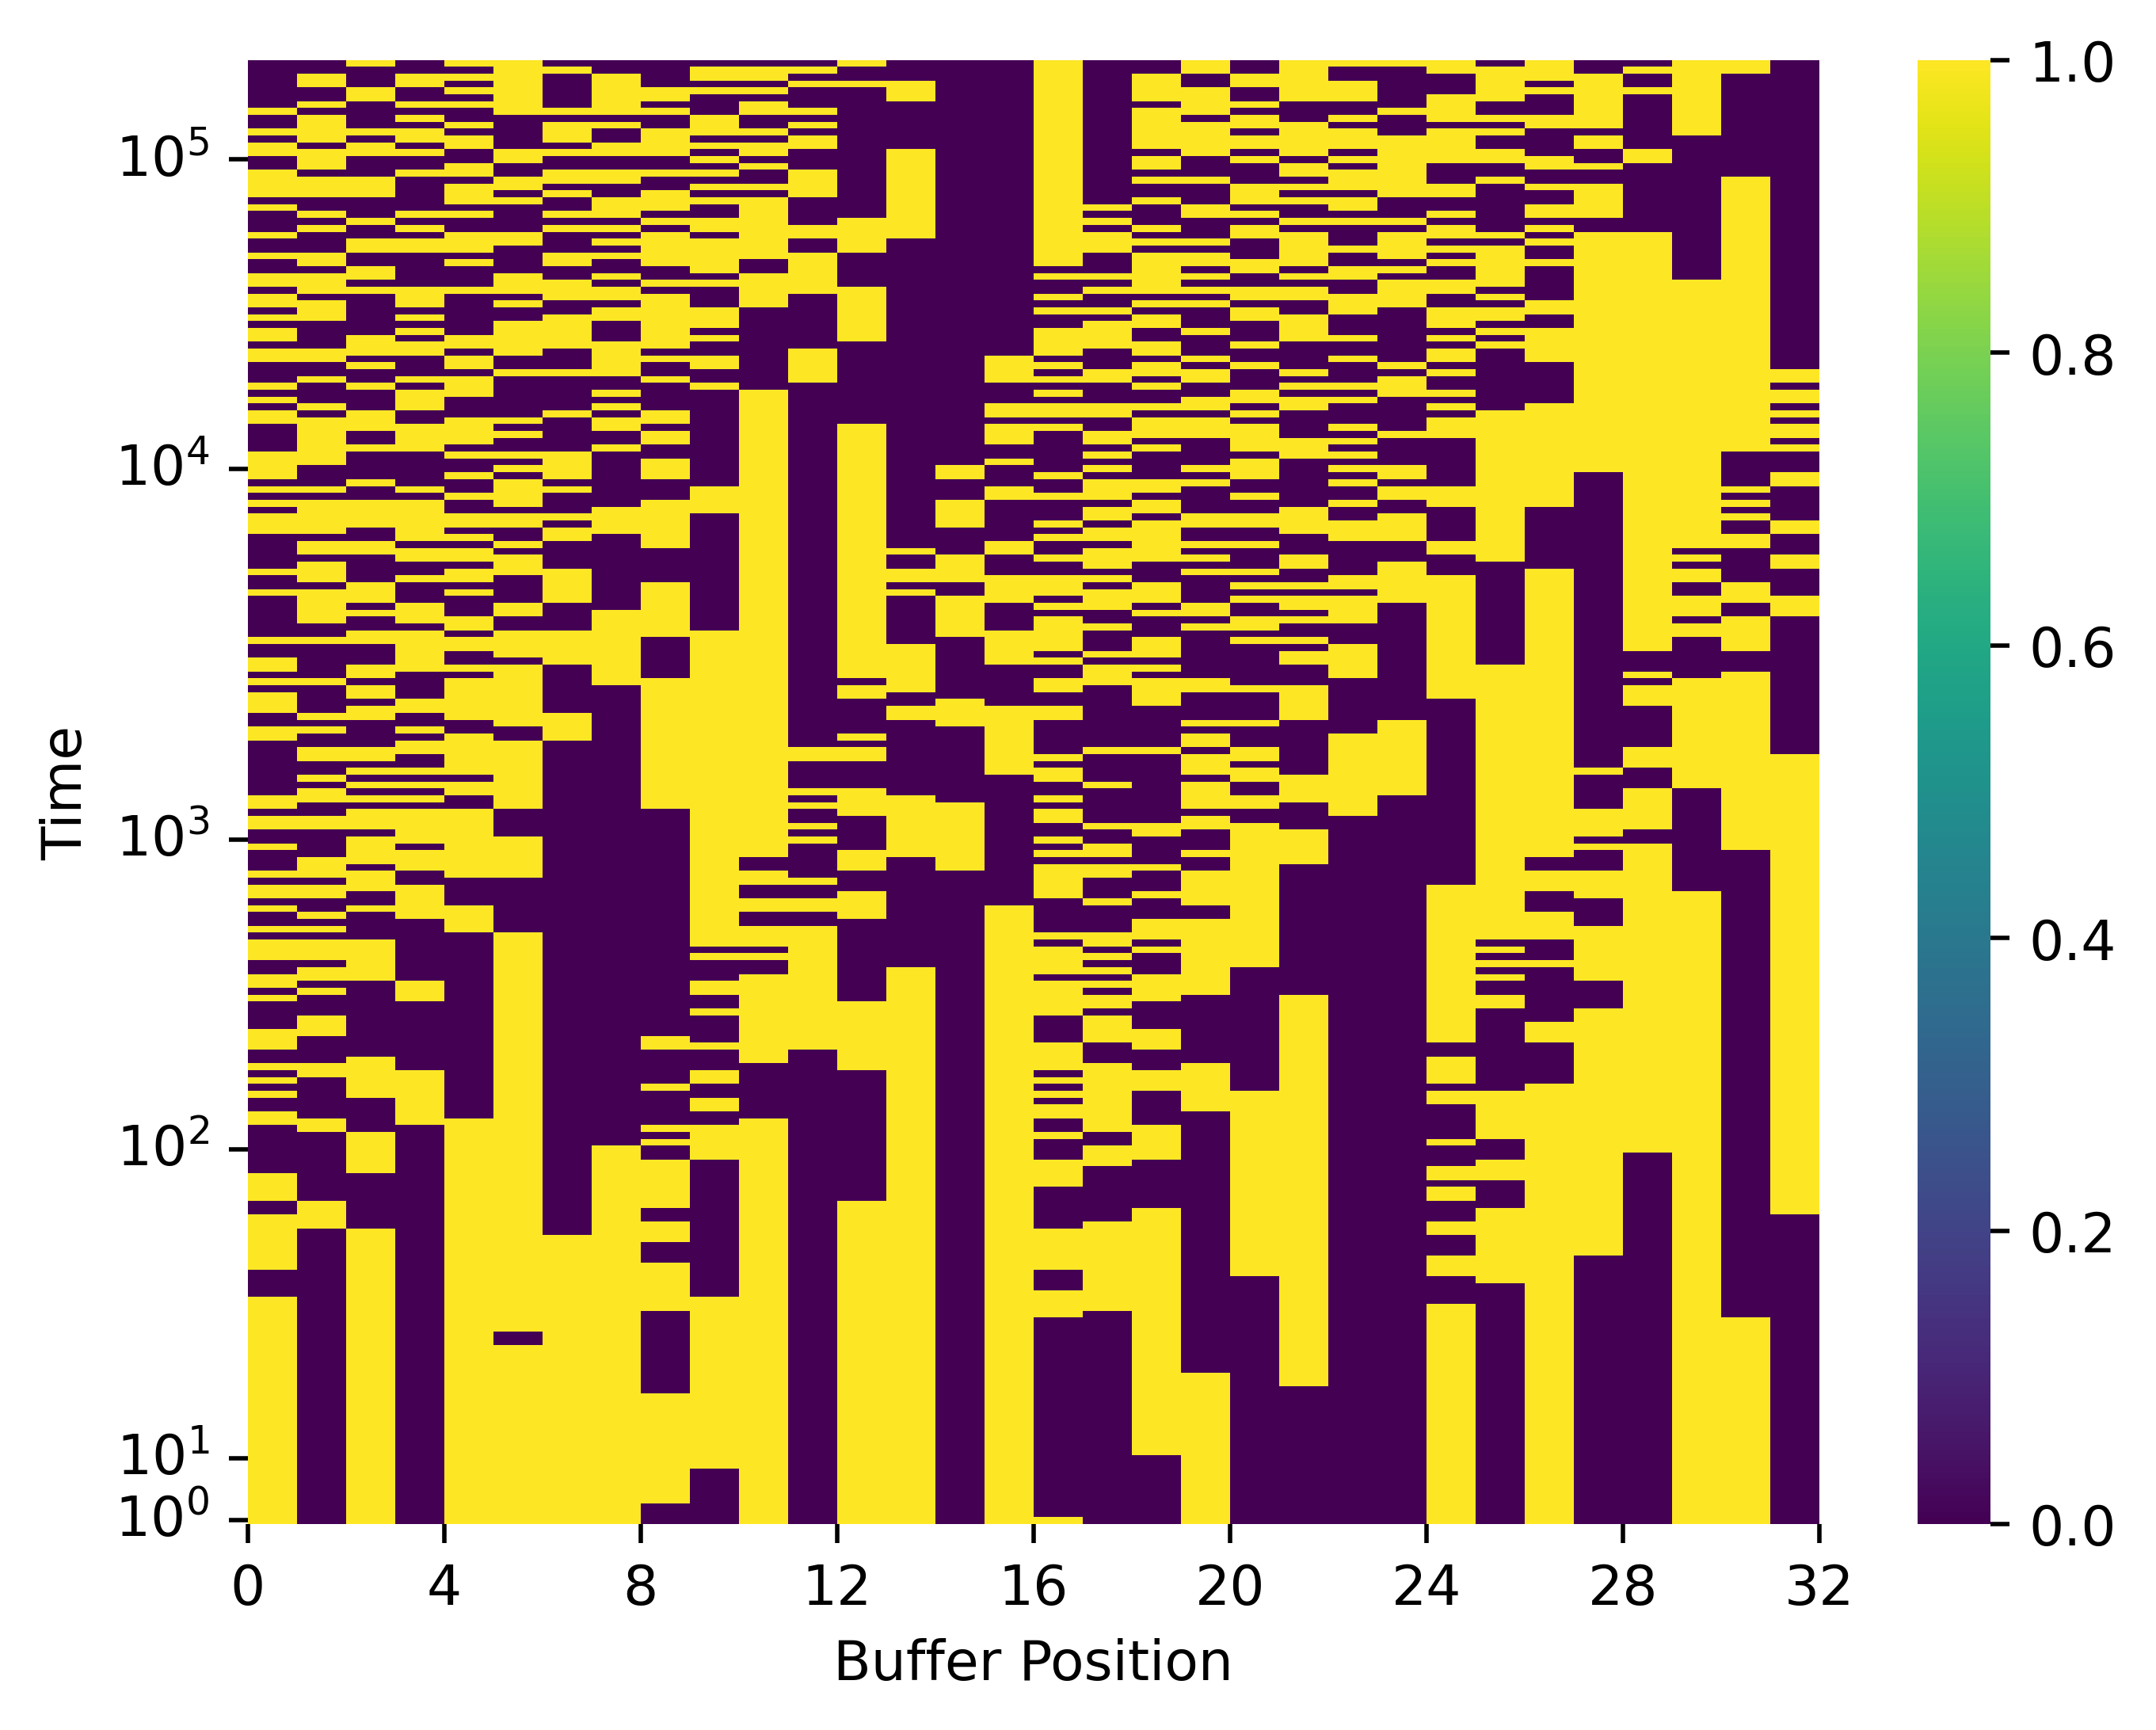

teeplots/03/num-generations=262144+surface-size=32+viz=site-differentia-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/num-generations=262144+surface-size=32+viz=site-differentia-by-rank-heatmap+ynorm=linear+ext=.png


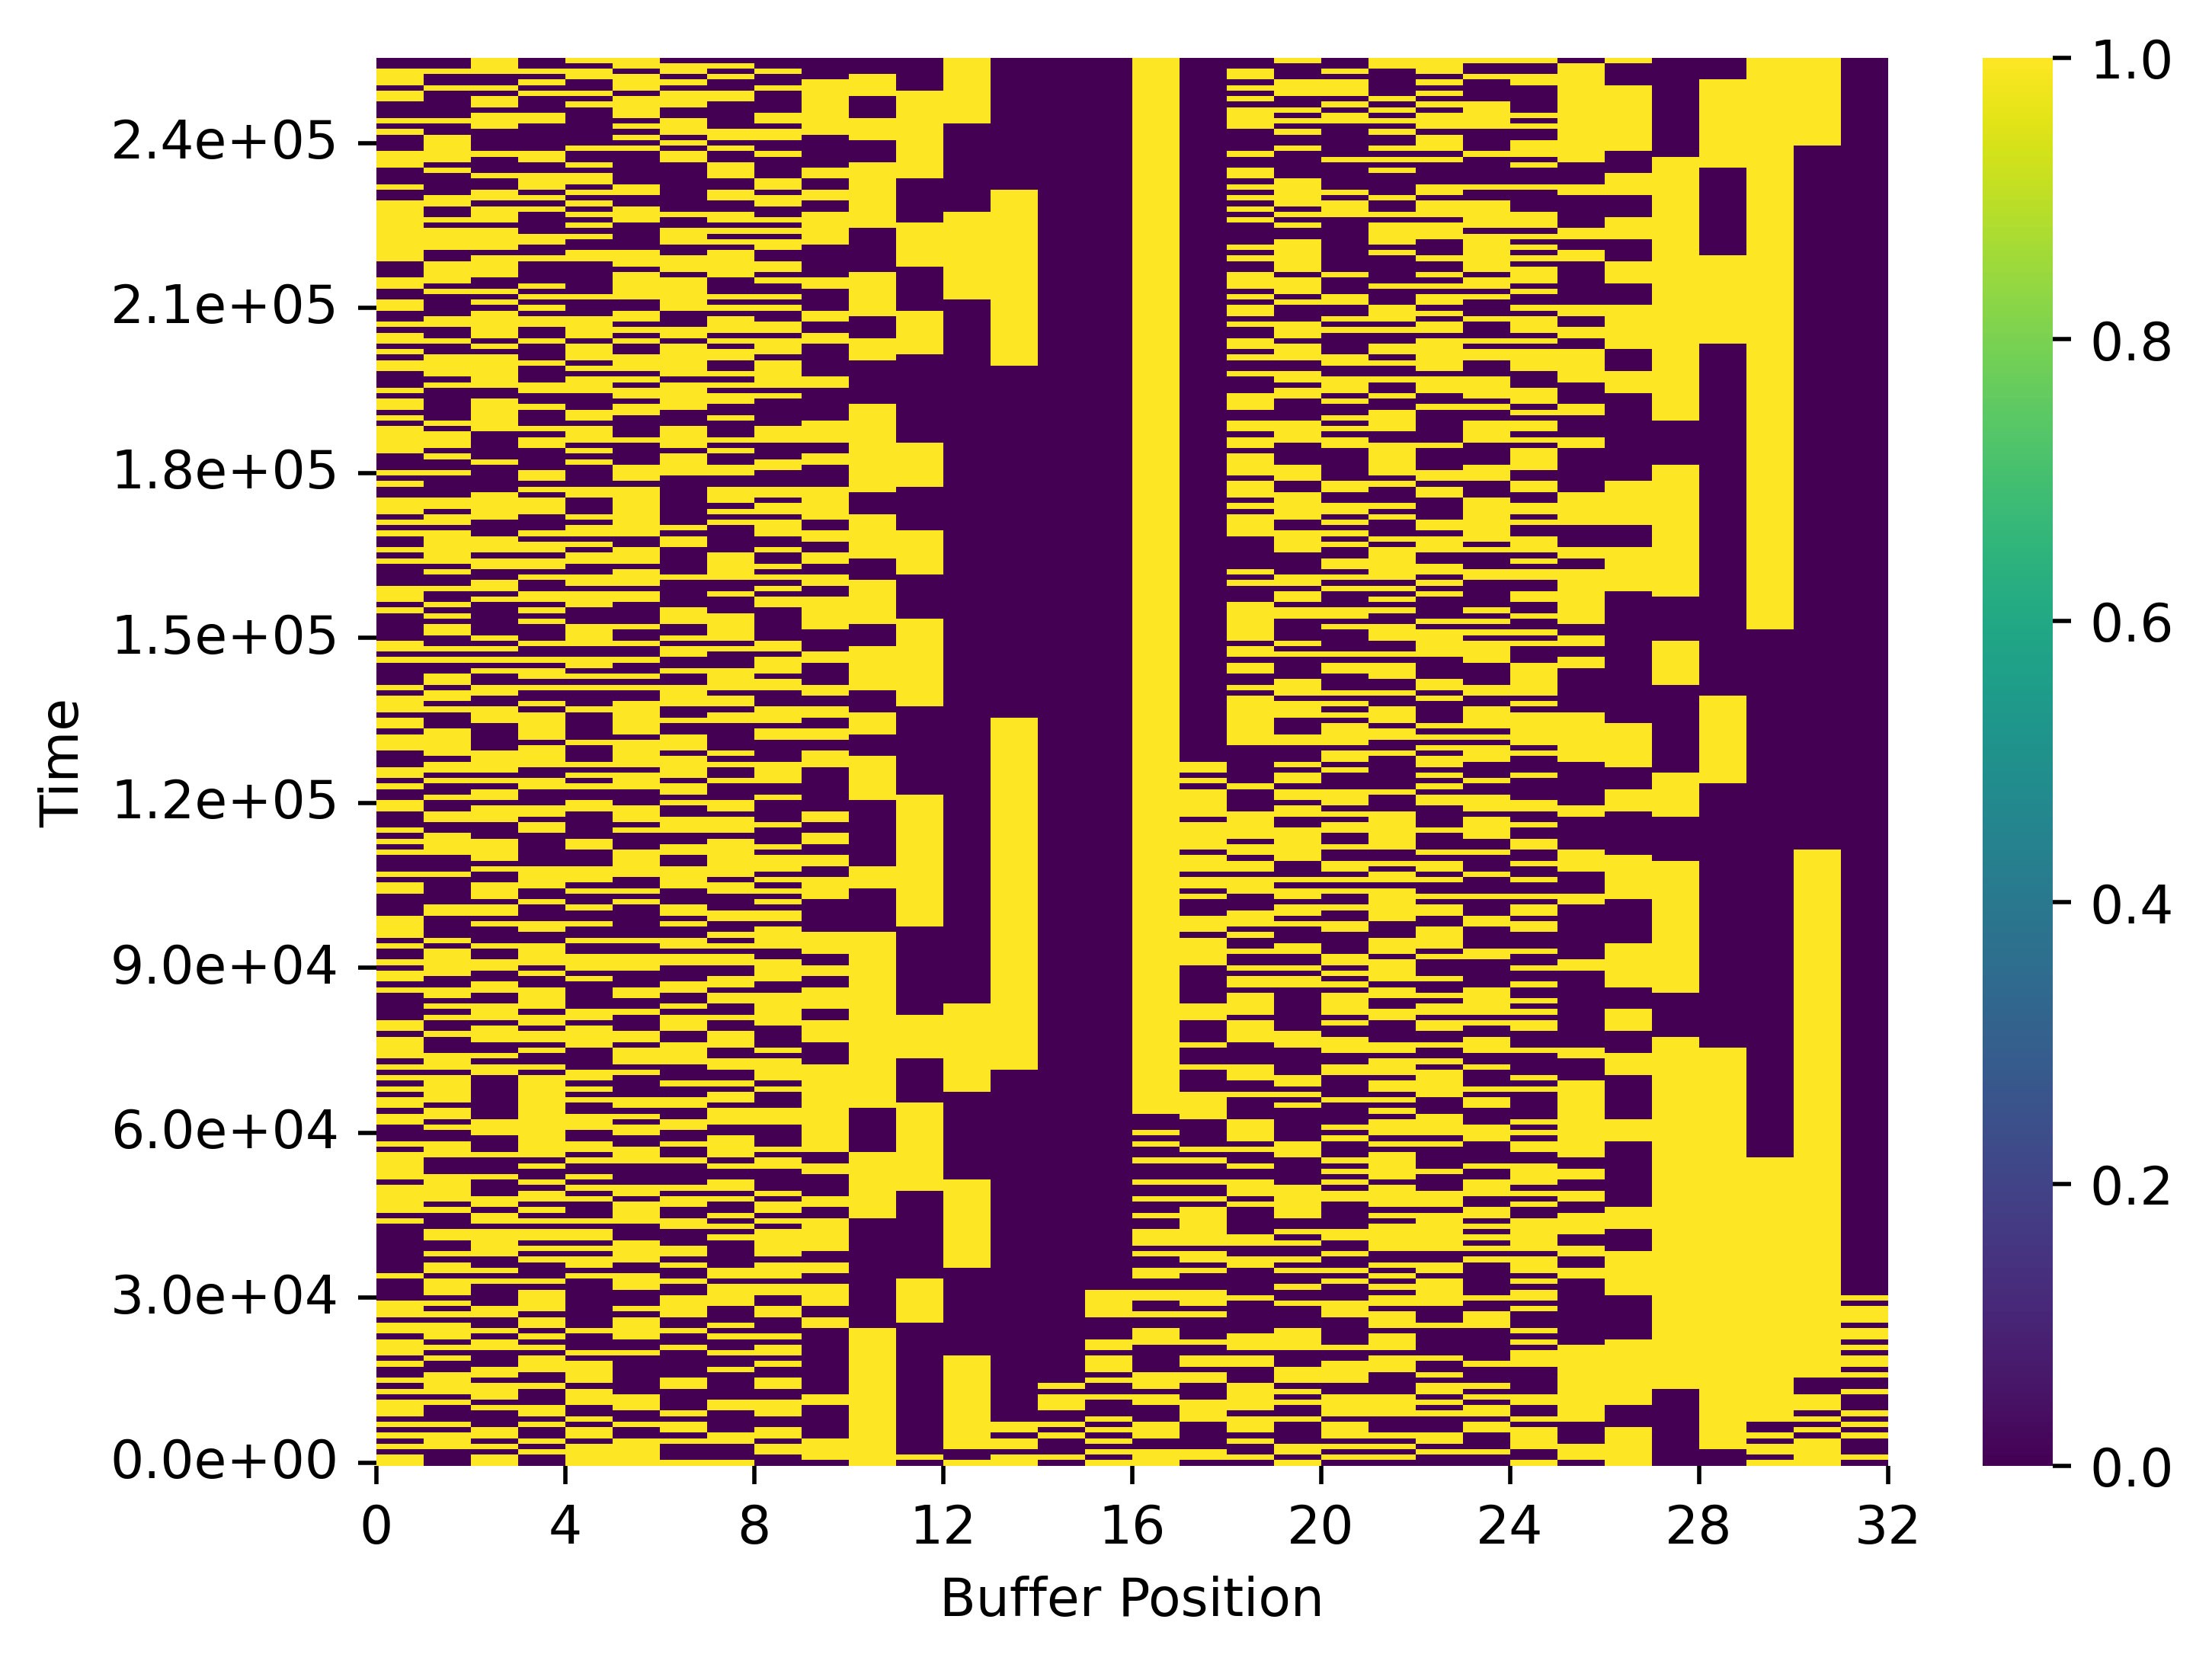

teeplots/03/cnorm=log+num-generations=262144+surface-size=32+viz=site-ingest-rank-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/cnorm=log+num-generations=262144+surface-size=32+viz=site-ingest-rank-by-rank-heatmap+ynorm=log+ext=.png


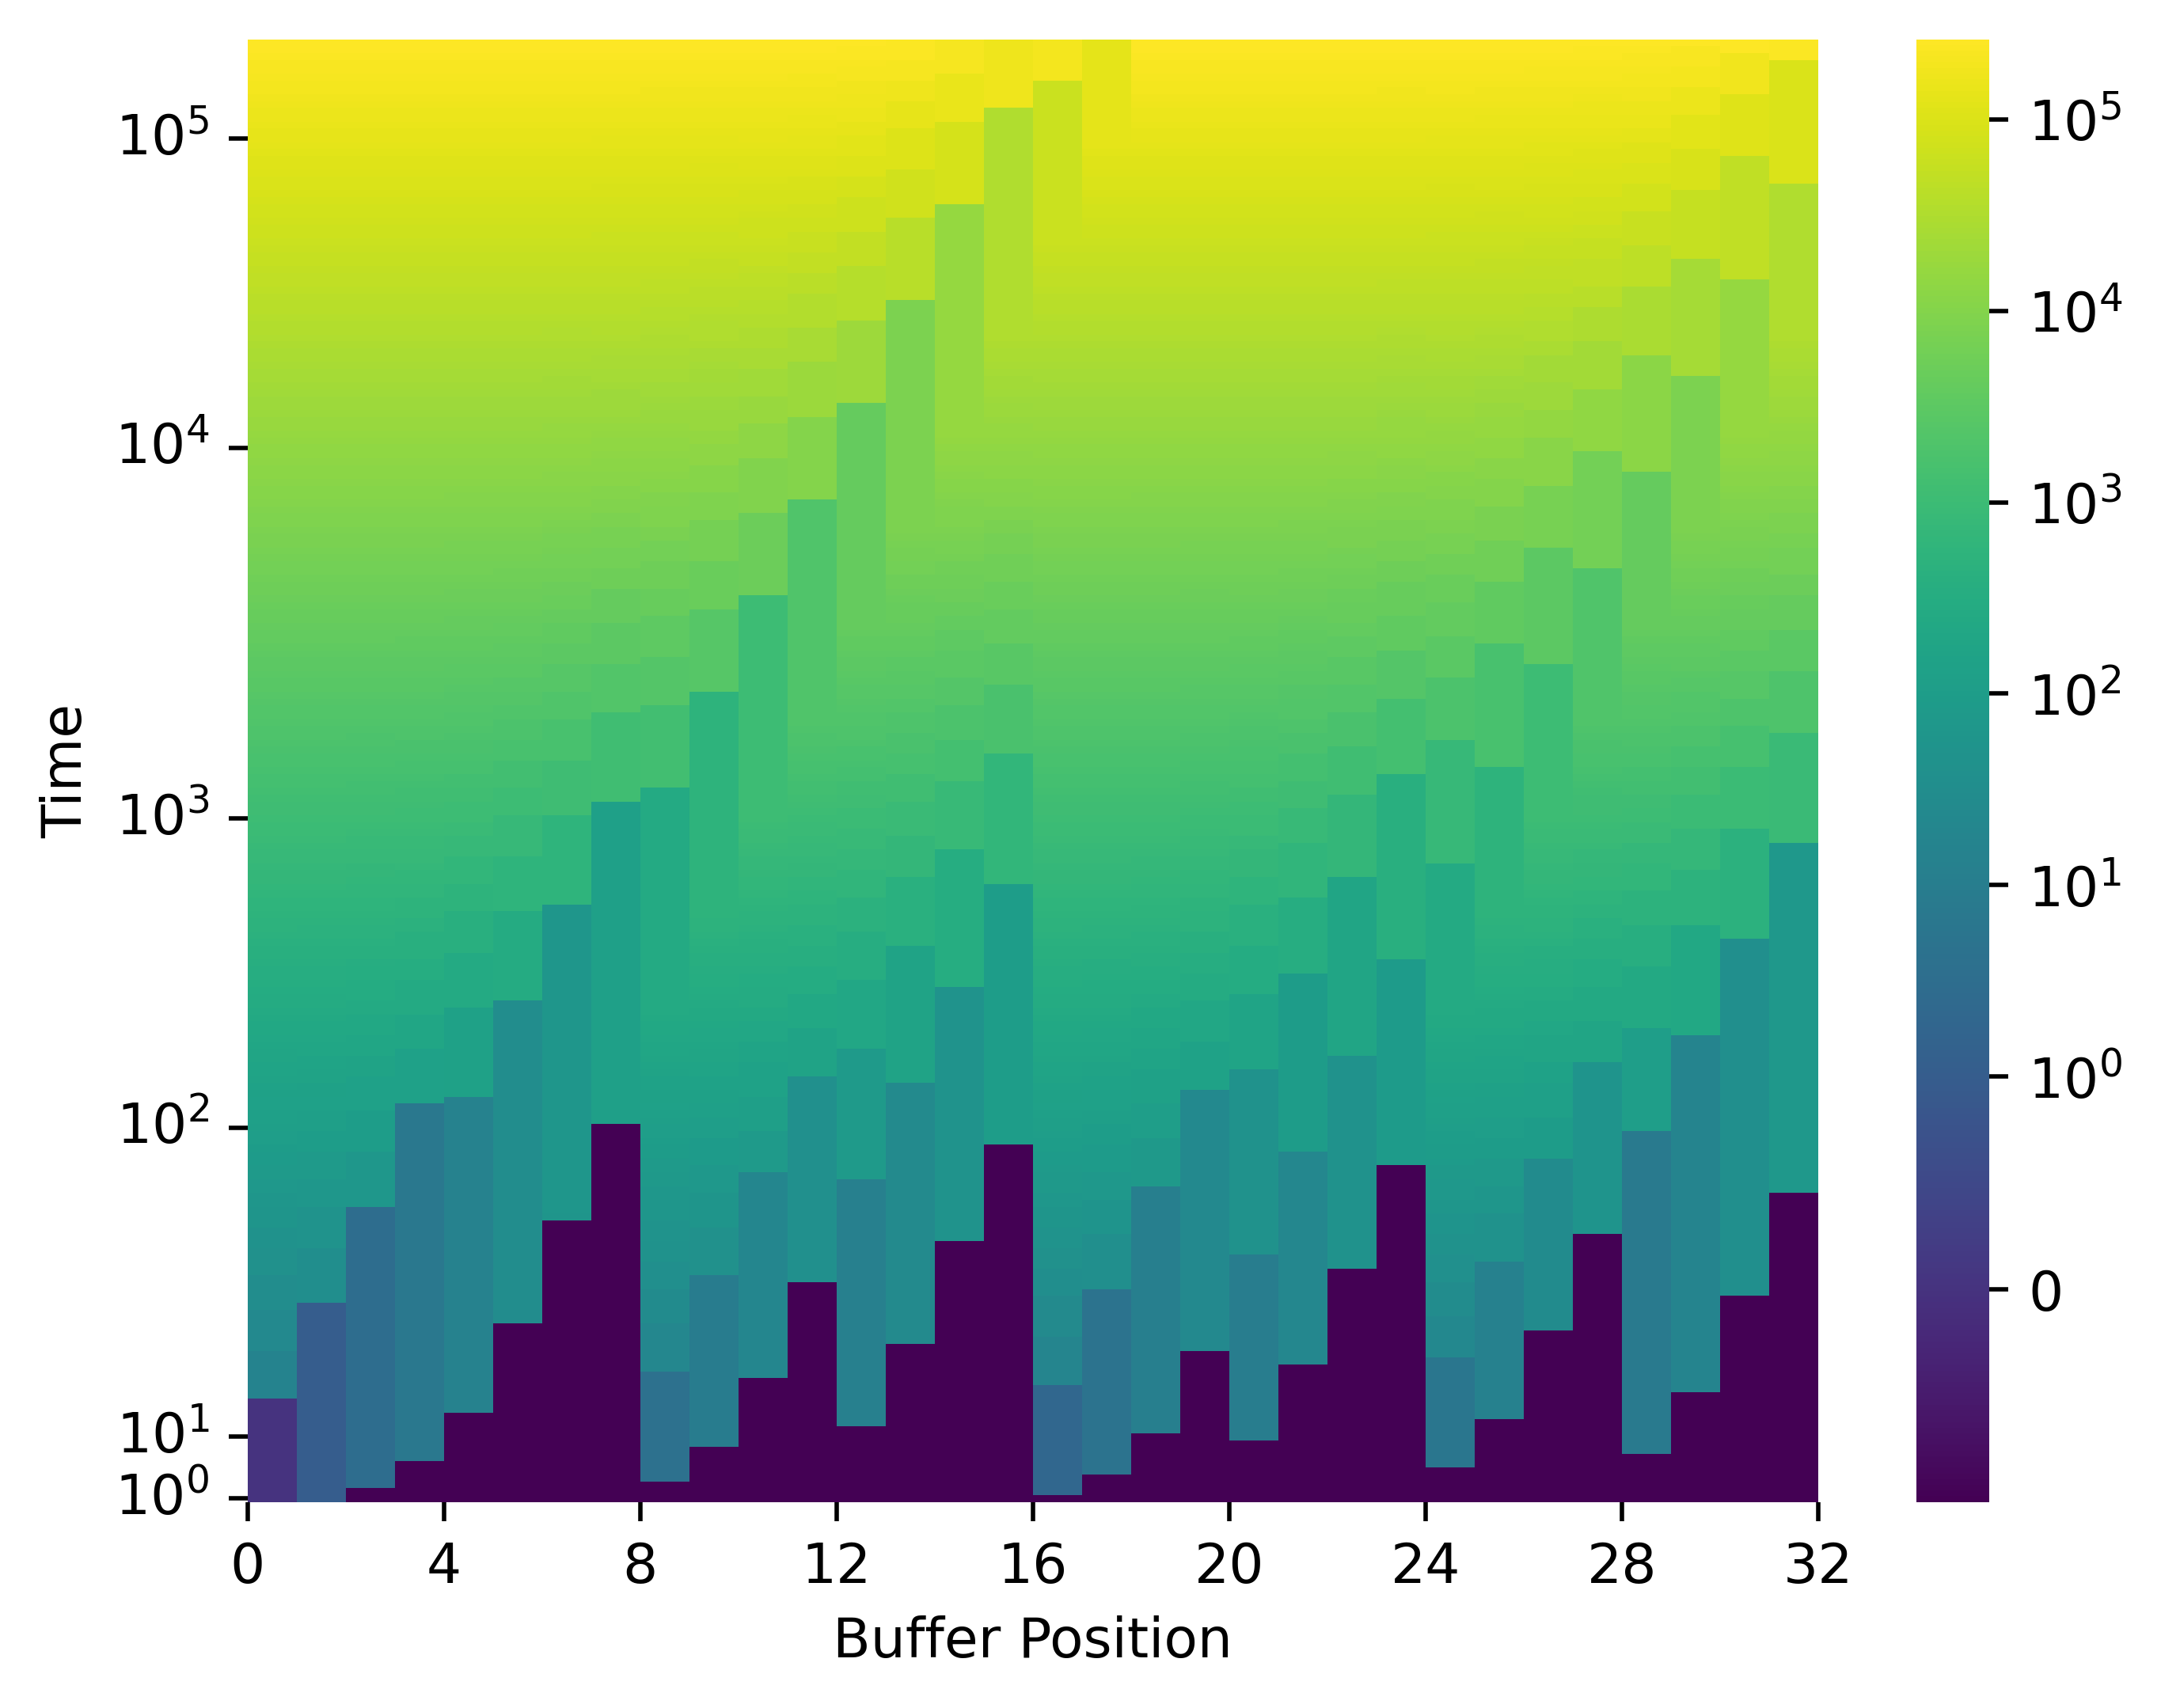

teeplots/03/cnorm=None+num-generations=262144+surface-size=32+viz=site-ingest-rank-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/cnorm=None+num-generations=262144+surface-size=32+viz=site-ingest-rank-by-rank-heatmap+ynorm=linear+ext=.png


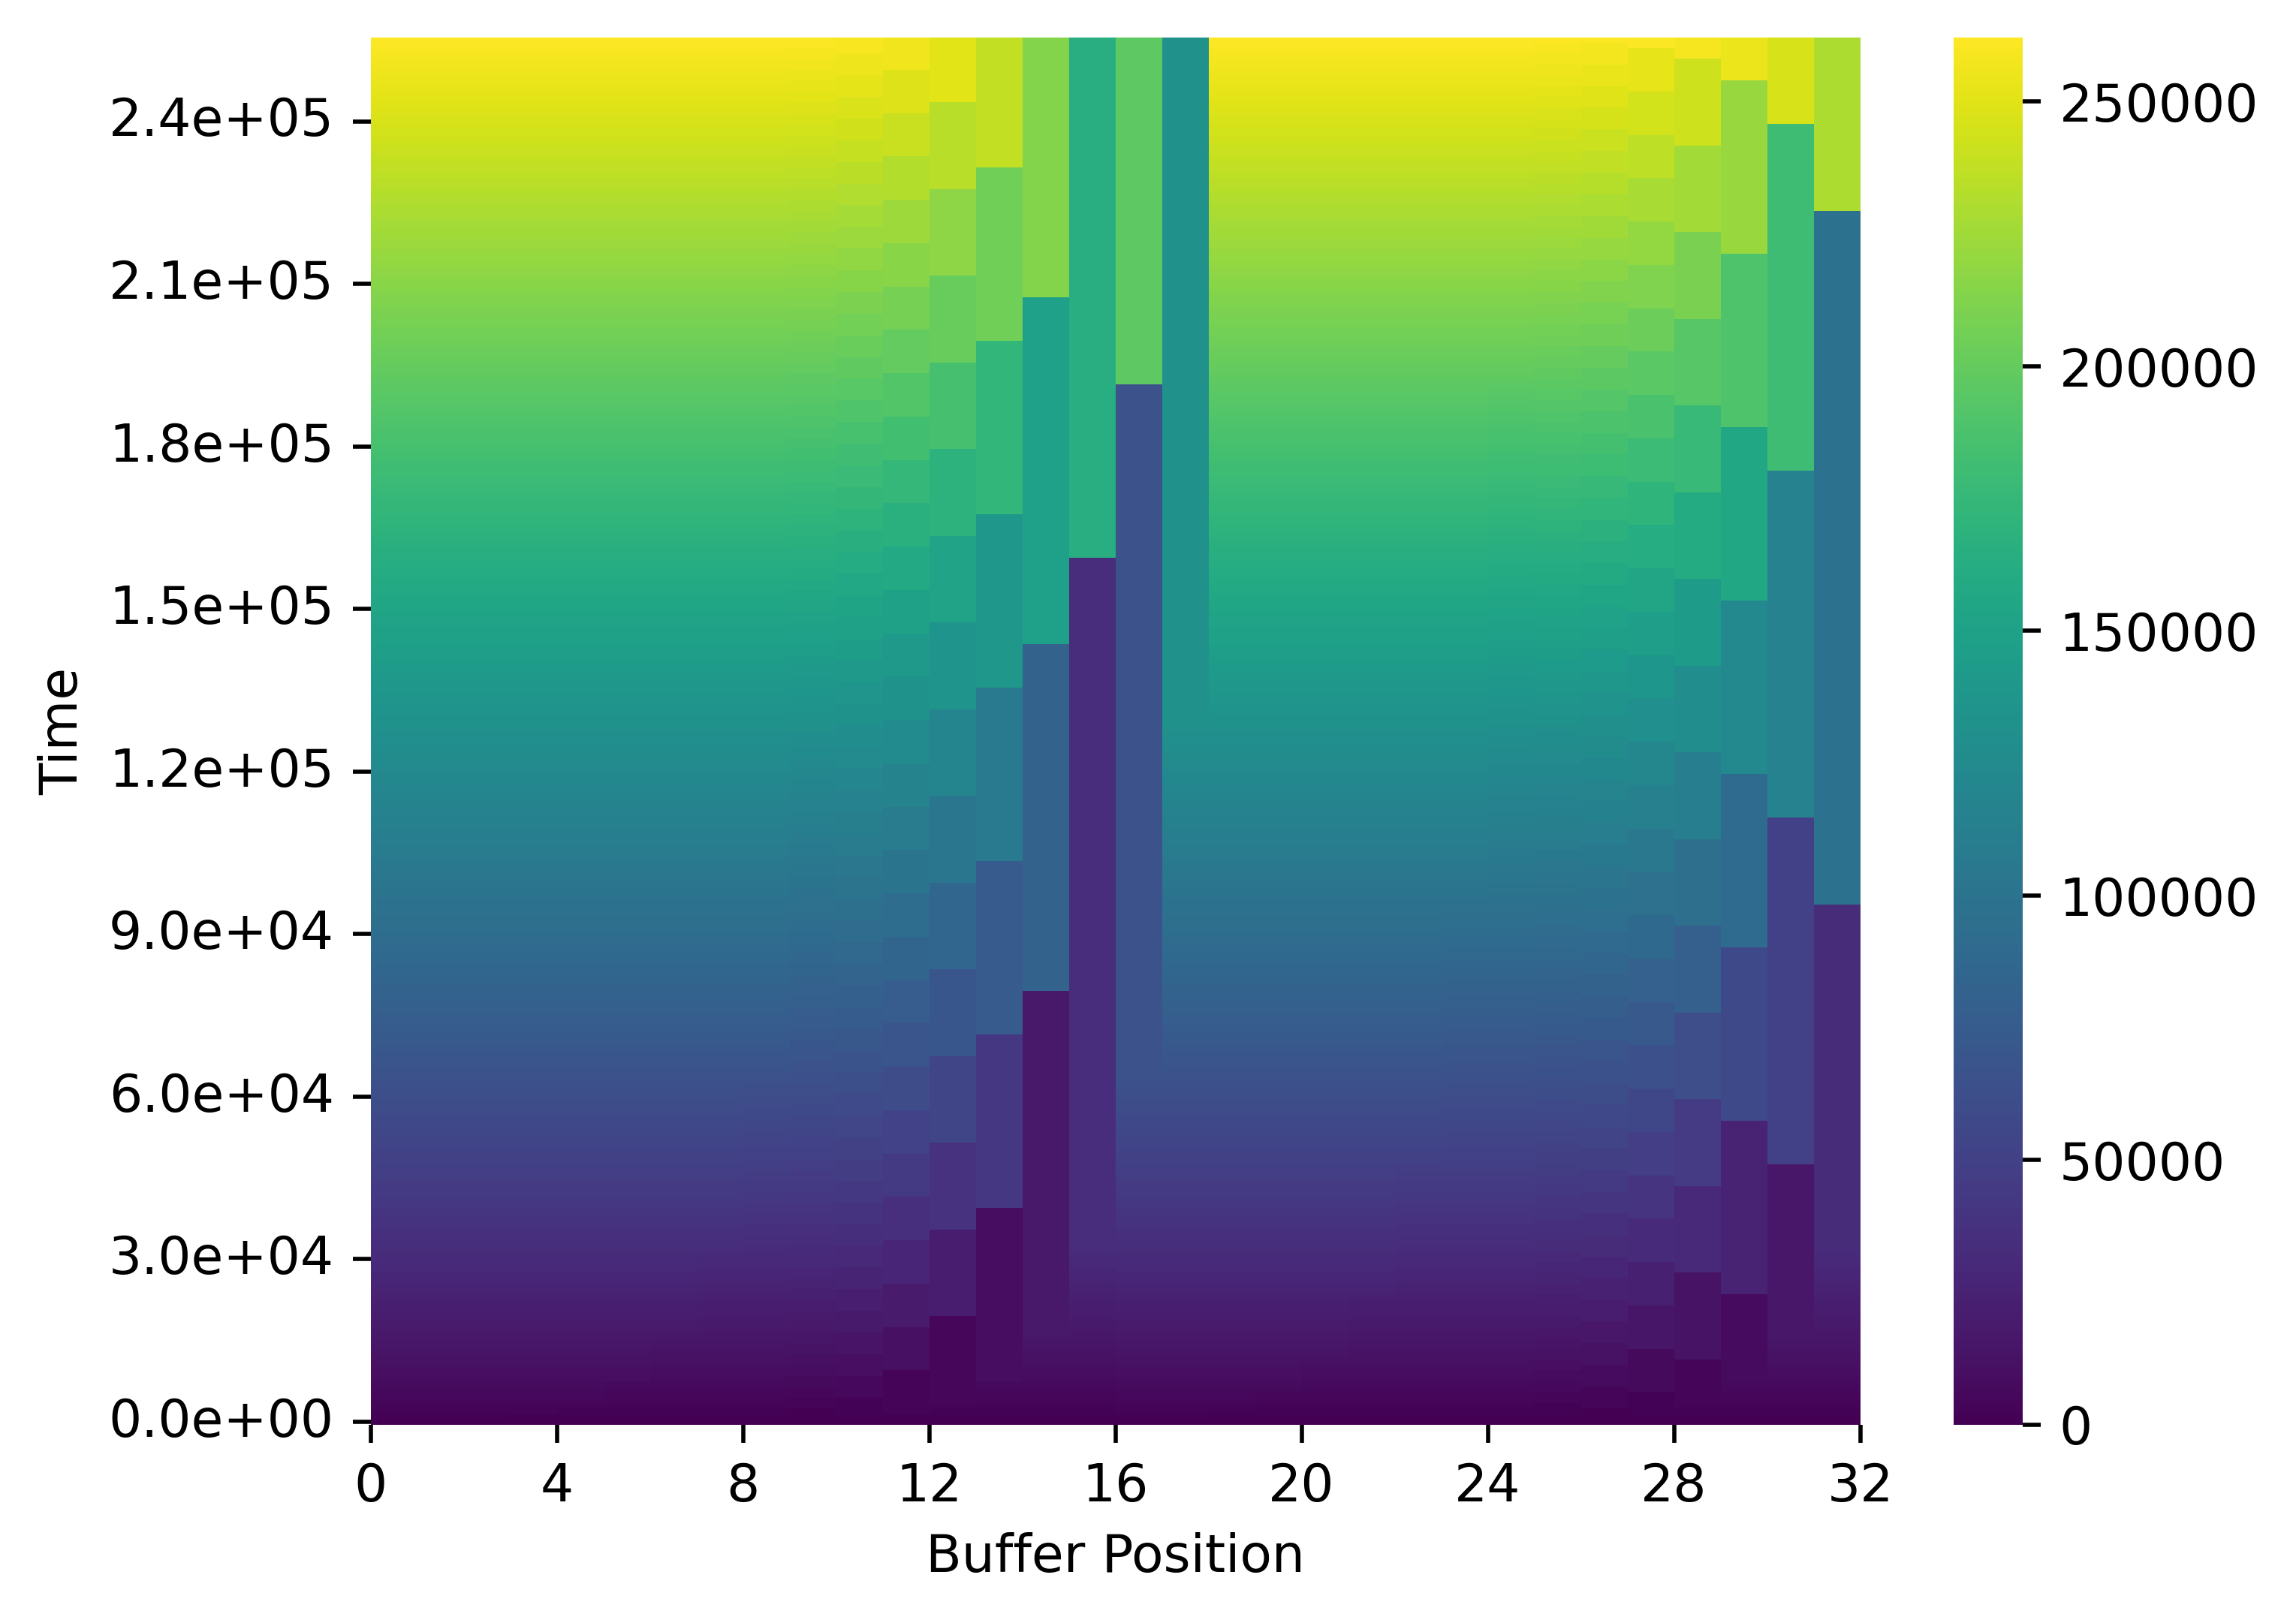

teeplots/03/num-generations=262144+surface-size=32+viz=site-hanoi-value-by-rank-heatmap+ext=.pdf
teeplots/03/num-generations=262144+surface-size=32+viz=site-hanoi-value-by-rank-heatmap+ext=.png


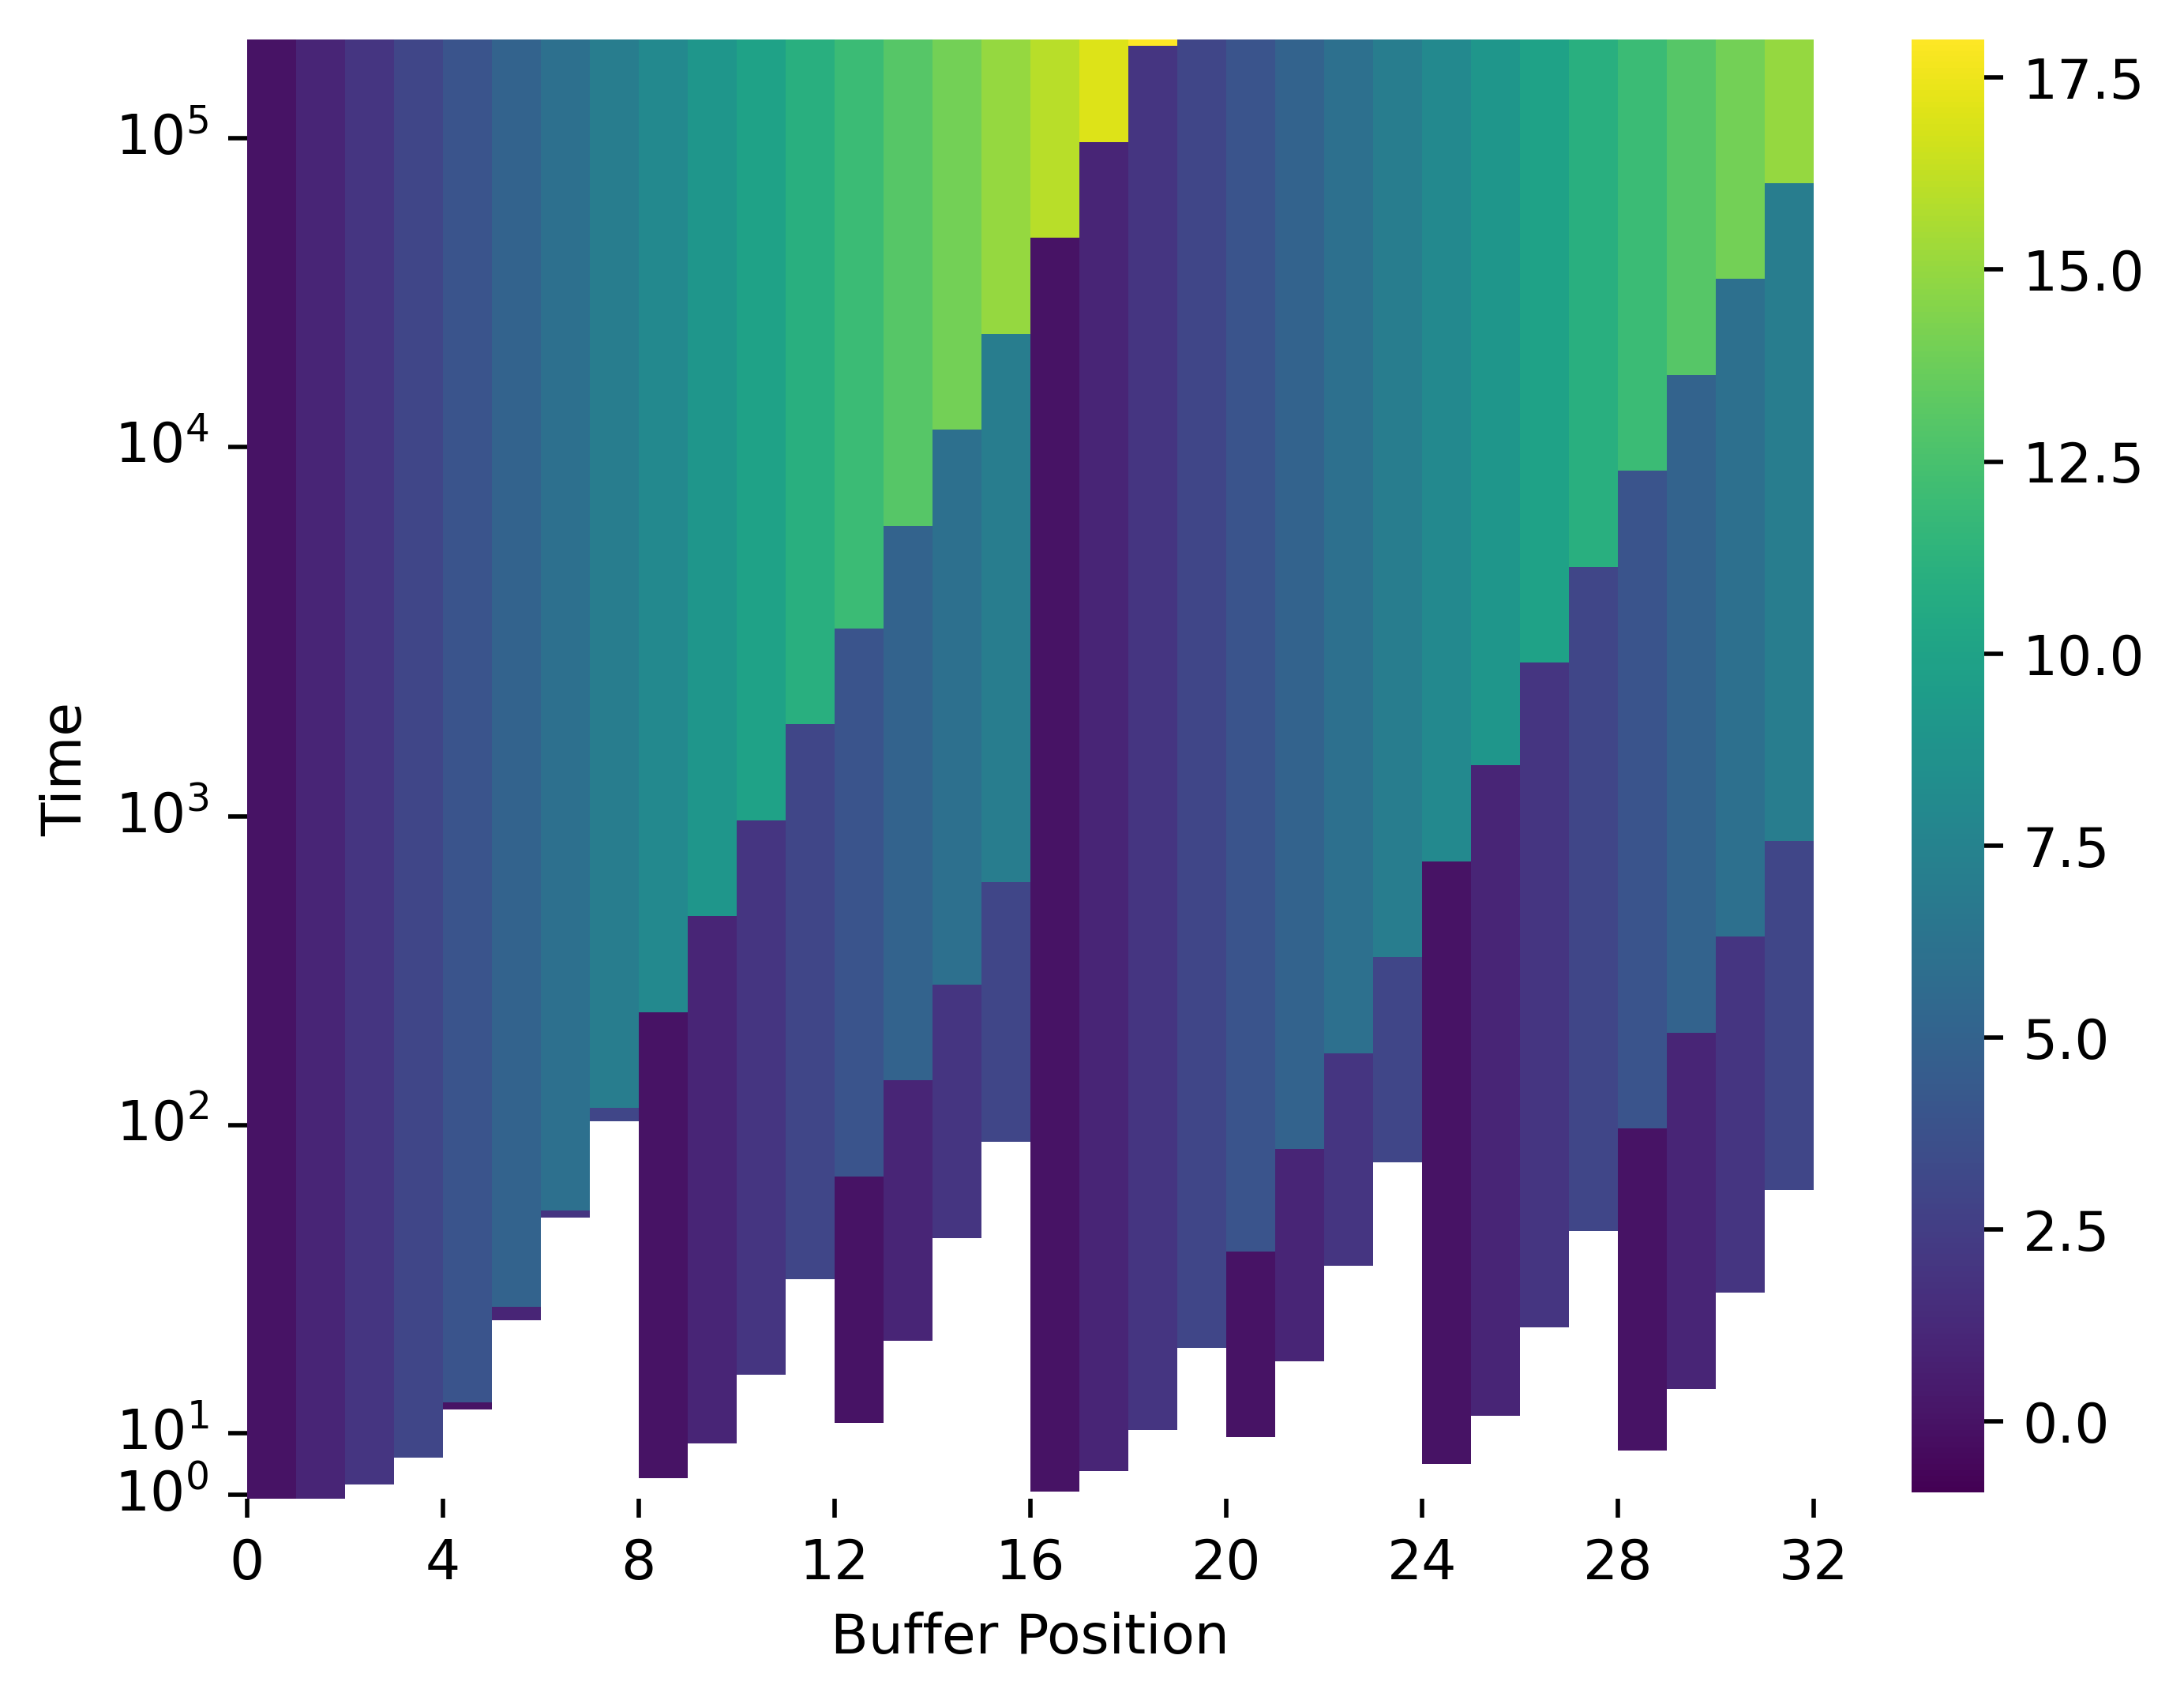

teeplots/03/num-generations=262144+surface-size=32+viz=site-hanoi-value-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/num-generations=262144+surface-size=32+viz=site-hanoi-value-by-rank-heatmap+ynorm=linear+ext=.png


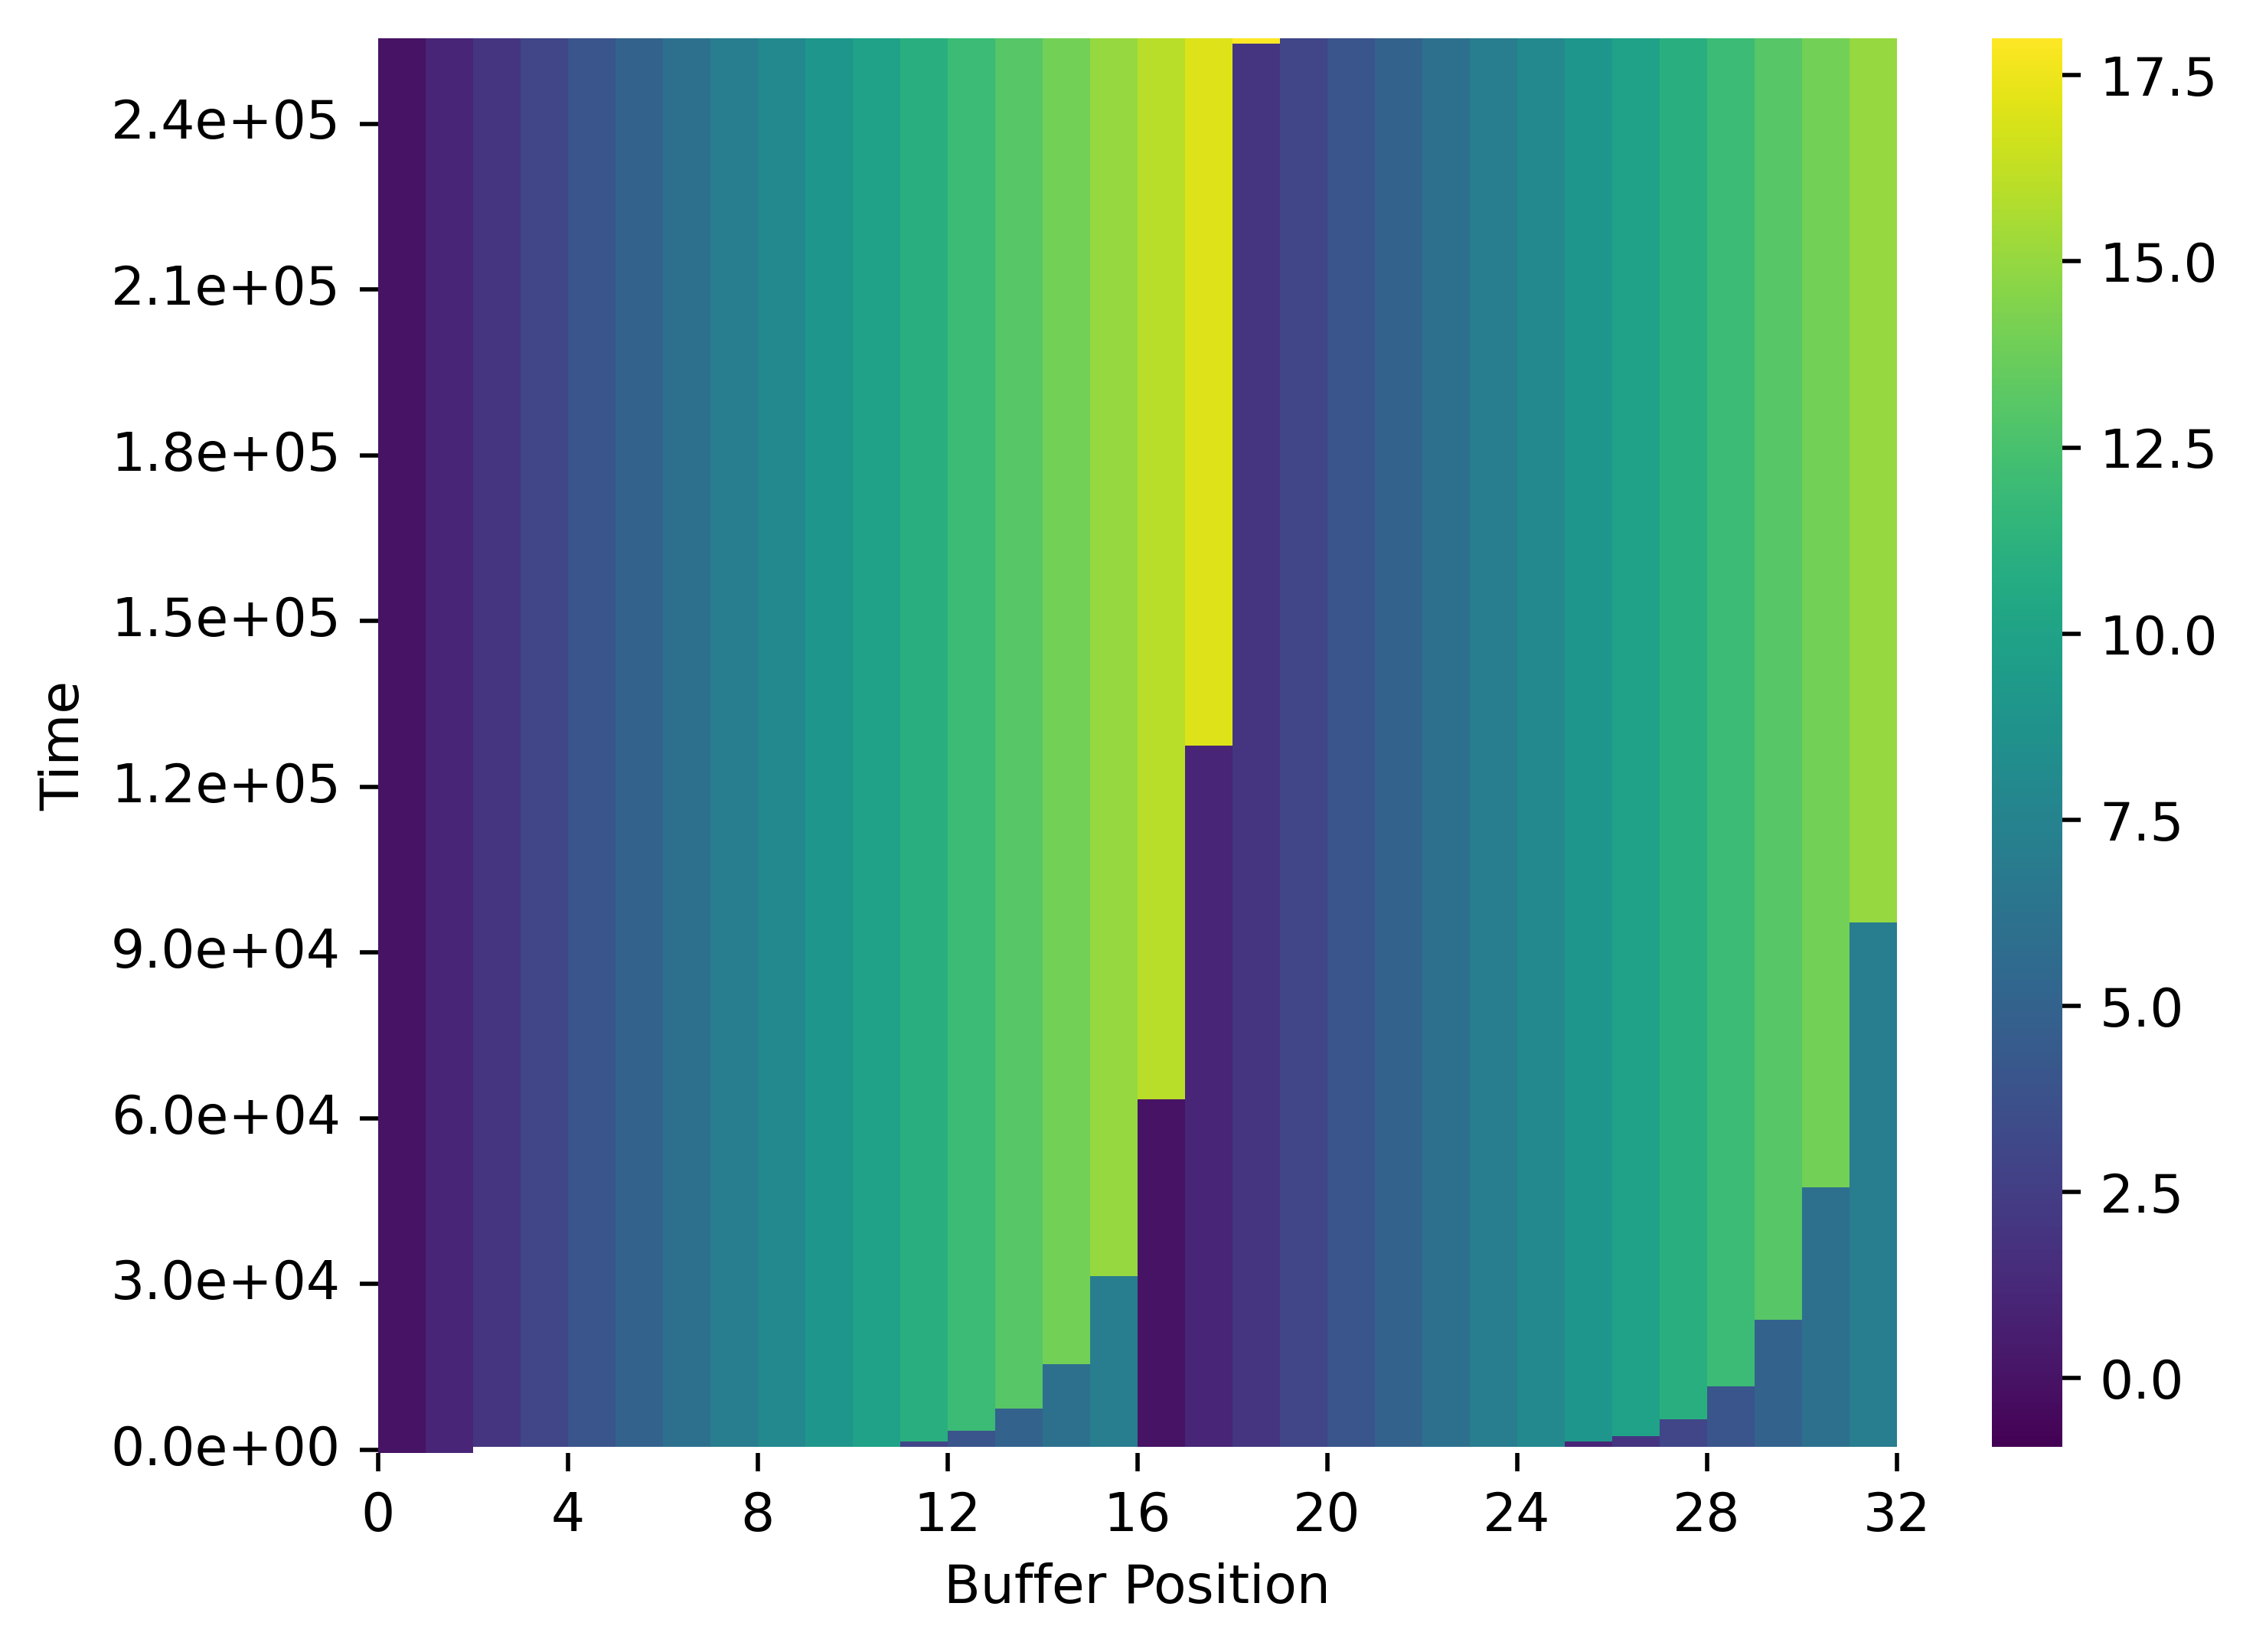

teeplots/03/cnorm=log+num-generations=262144+surface-size=32+viz=site-ingest-depth-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/cnorm=log+num-generations=262144+surface-size=32+viz=site-ingest-depth-by-rank-heatmap+ynorm=log+ext=.png


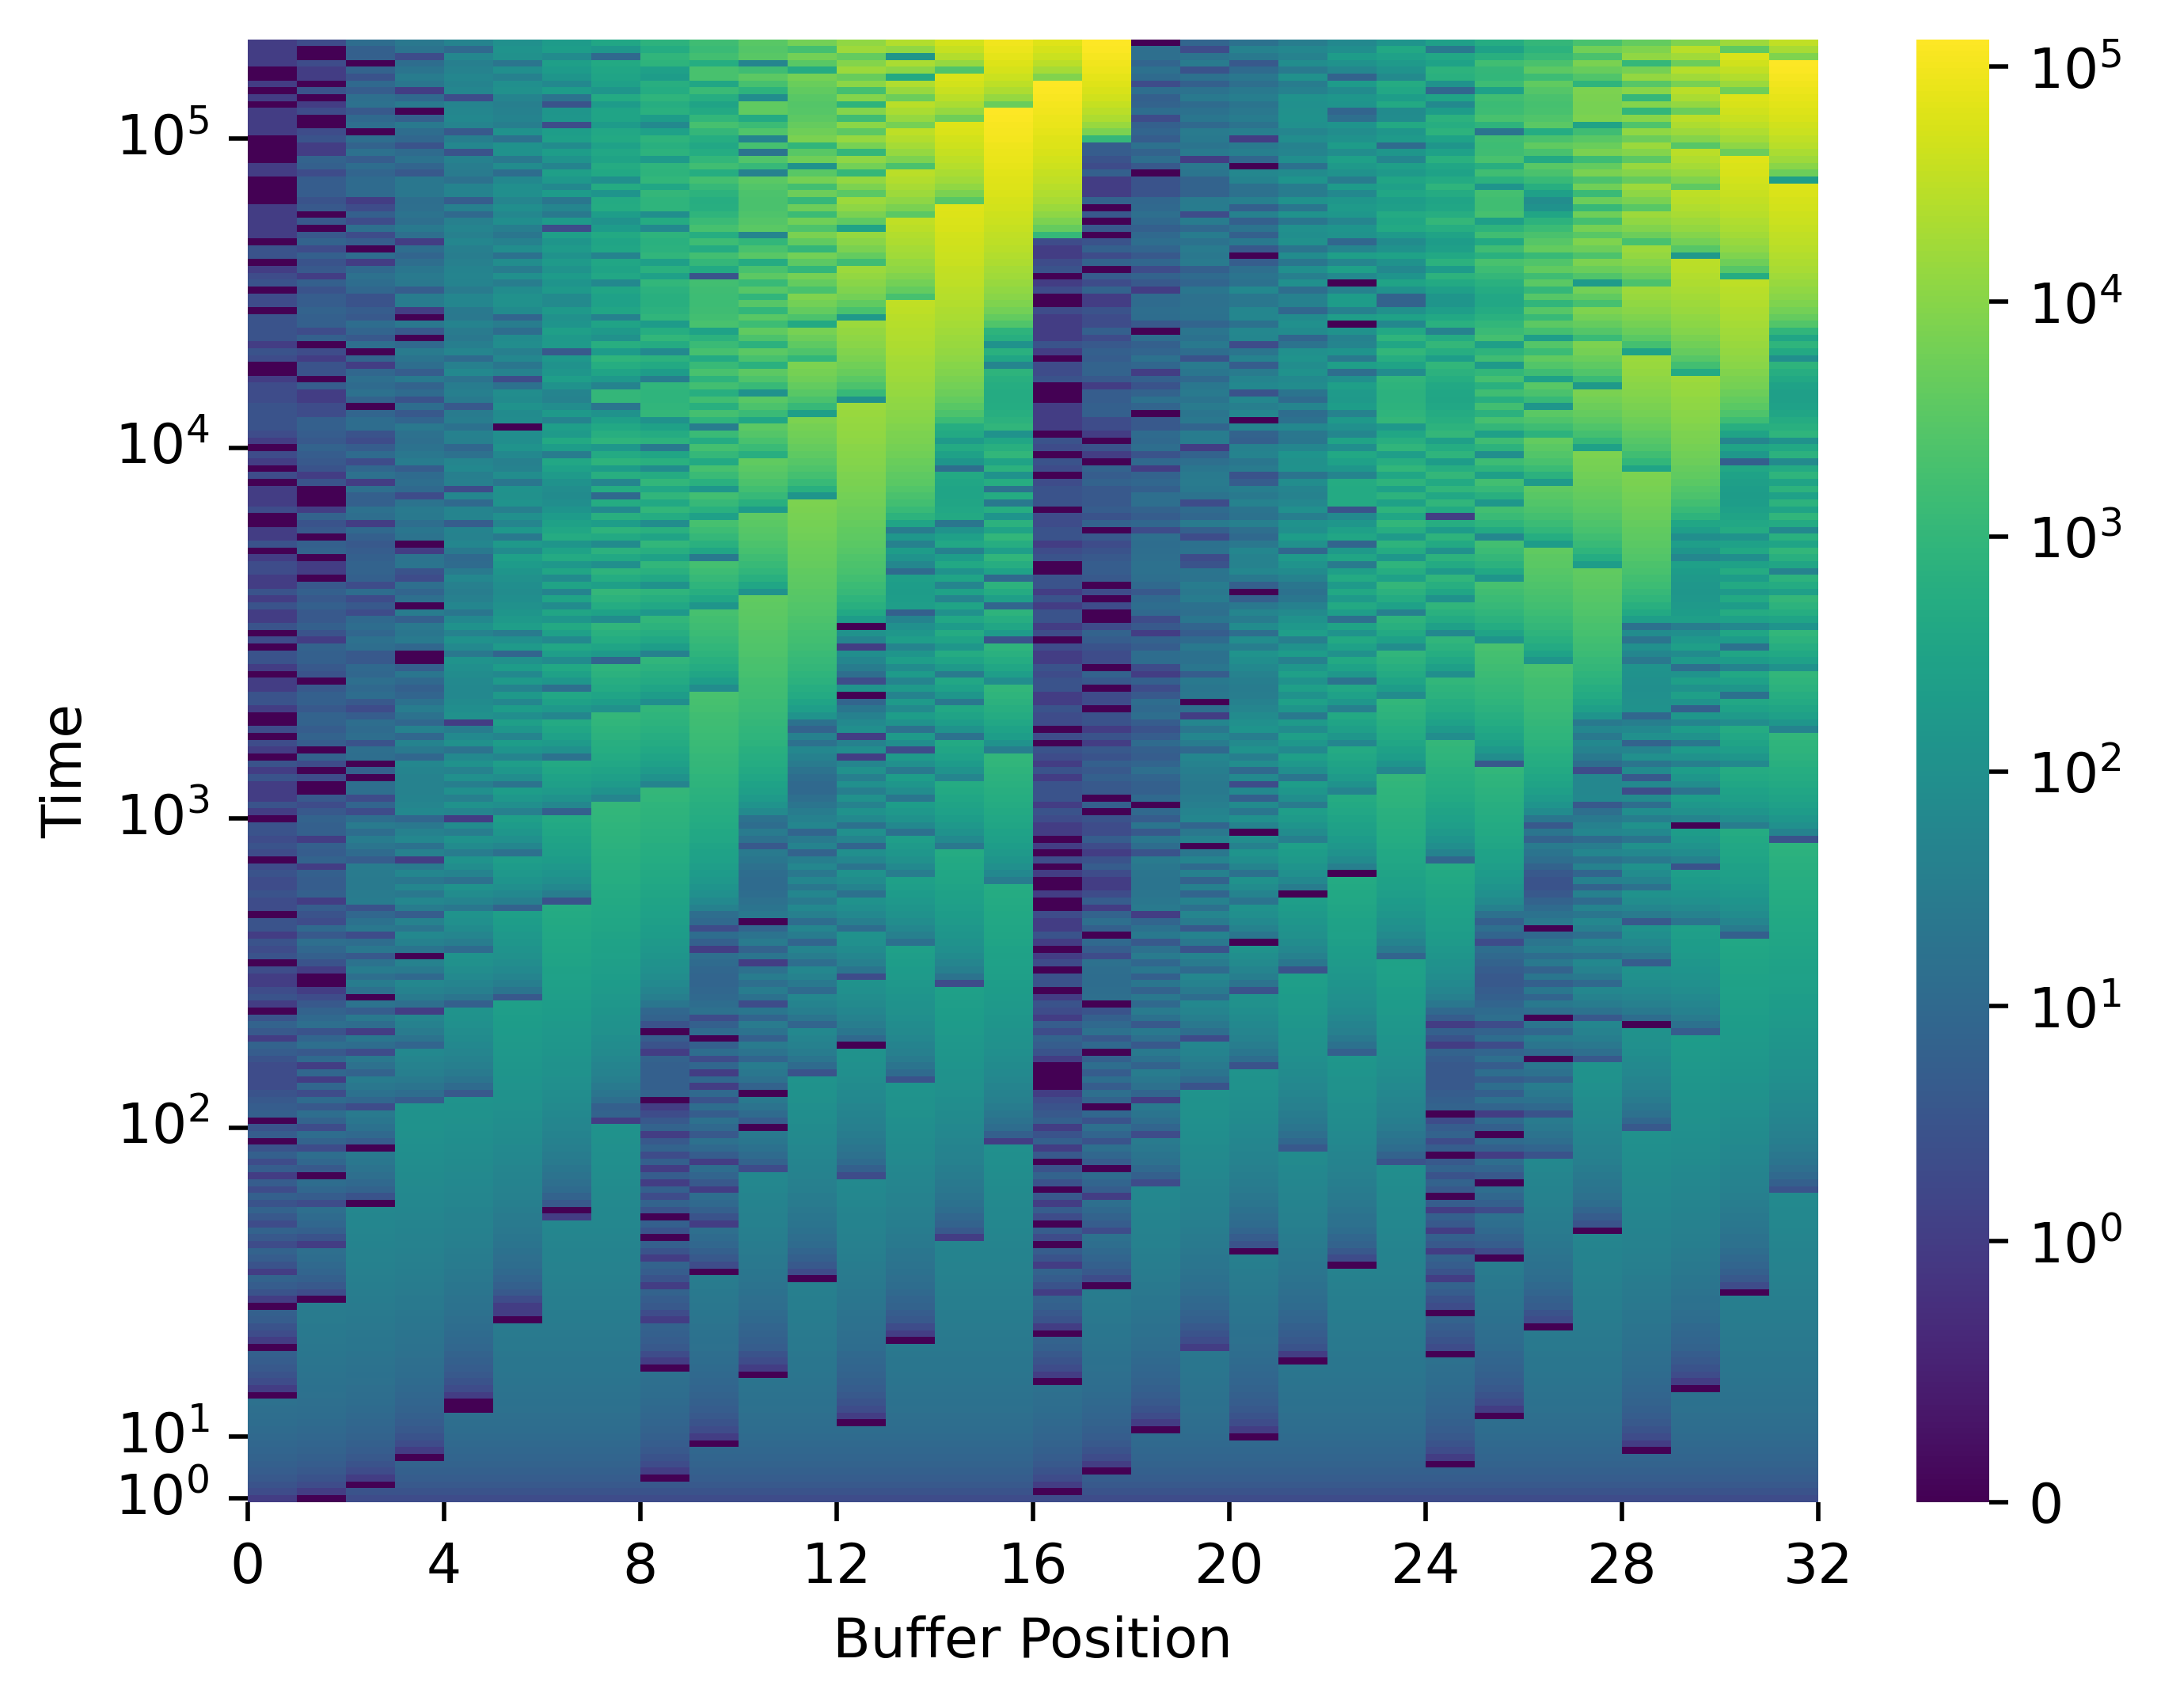

teeplots/03/cnorm=log+num-generations=262144+surface-size=32+viz=site-ingest-depth-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/cnorm=log+num-generations=262144+surface-size=32+viz=site-ingest-depth-by-rank-heatmap+ynorm=linear+ext=.png


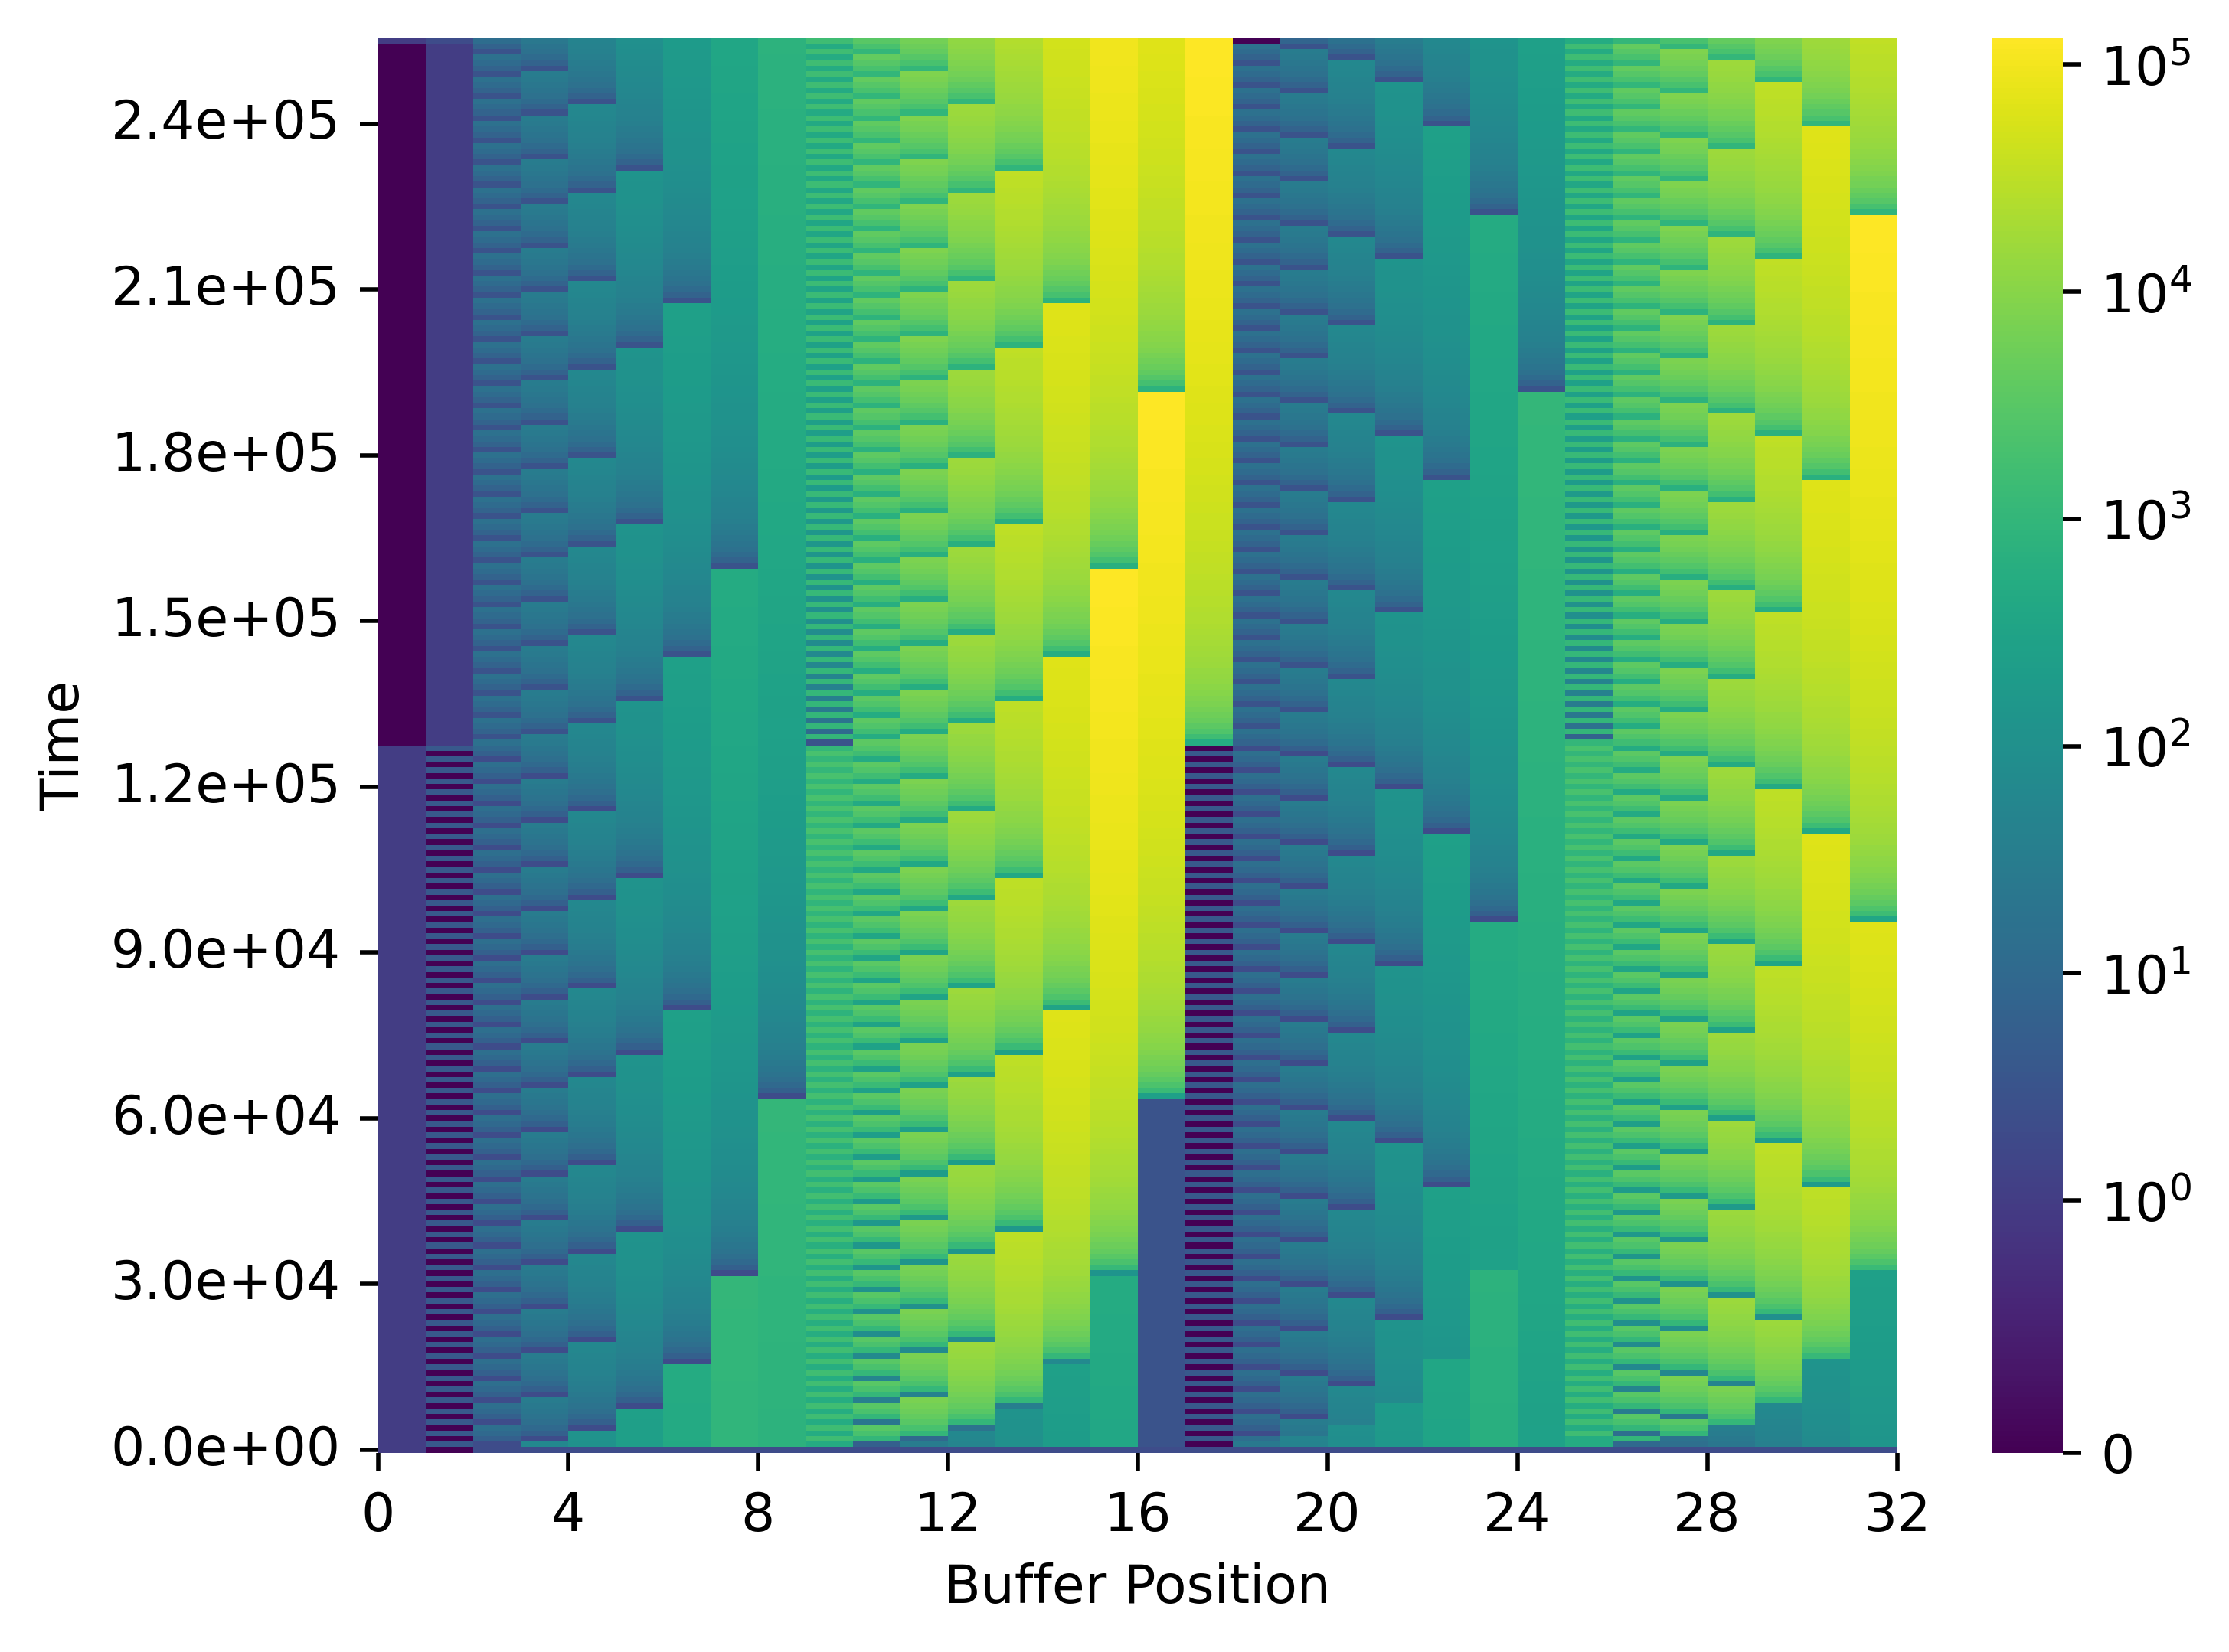

100%|██████████| 2998/2998 [00:08<00:00, 353.32it/s]


teeplots/03/num-generations=262144+surface-size=32+viz=stratum-persistence-dripplot+ext=.pdf
teeplots/03/num-generations=262144+surface-size=32+viz=stratum-persistence-dripplot+ext=.png


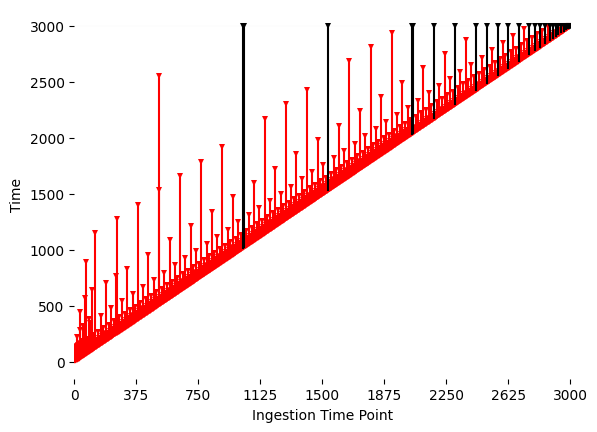

100%|██████████| 4096/4096 [00:00<00:00, 19086.09it/s]


teeplots/03/num-generations=4096+surface-size=128+viz=site-differentia-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/num-generations=4096+surface-size=128+viz=site-differentia-by-rank-heatmap+ynorm=log+ext=.png


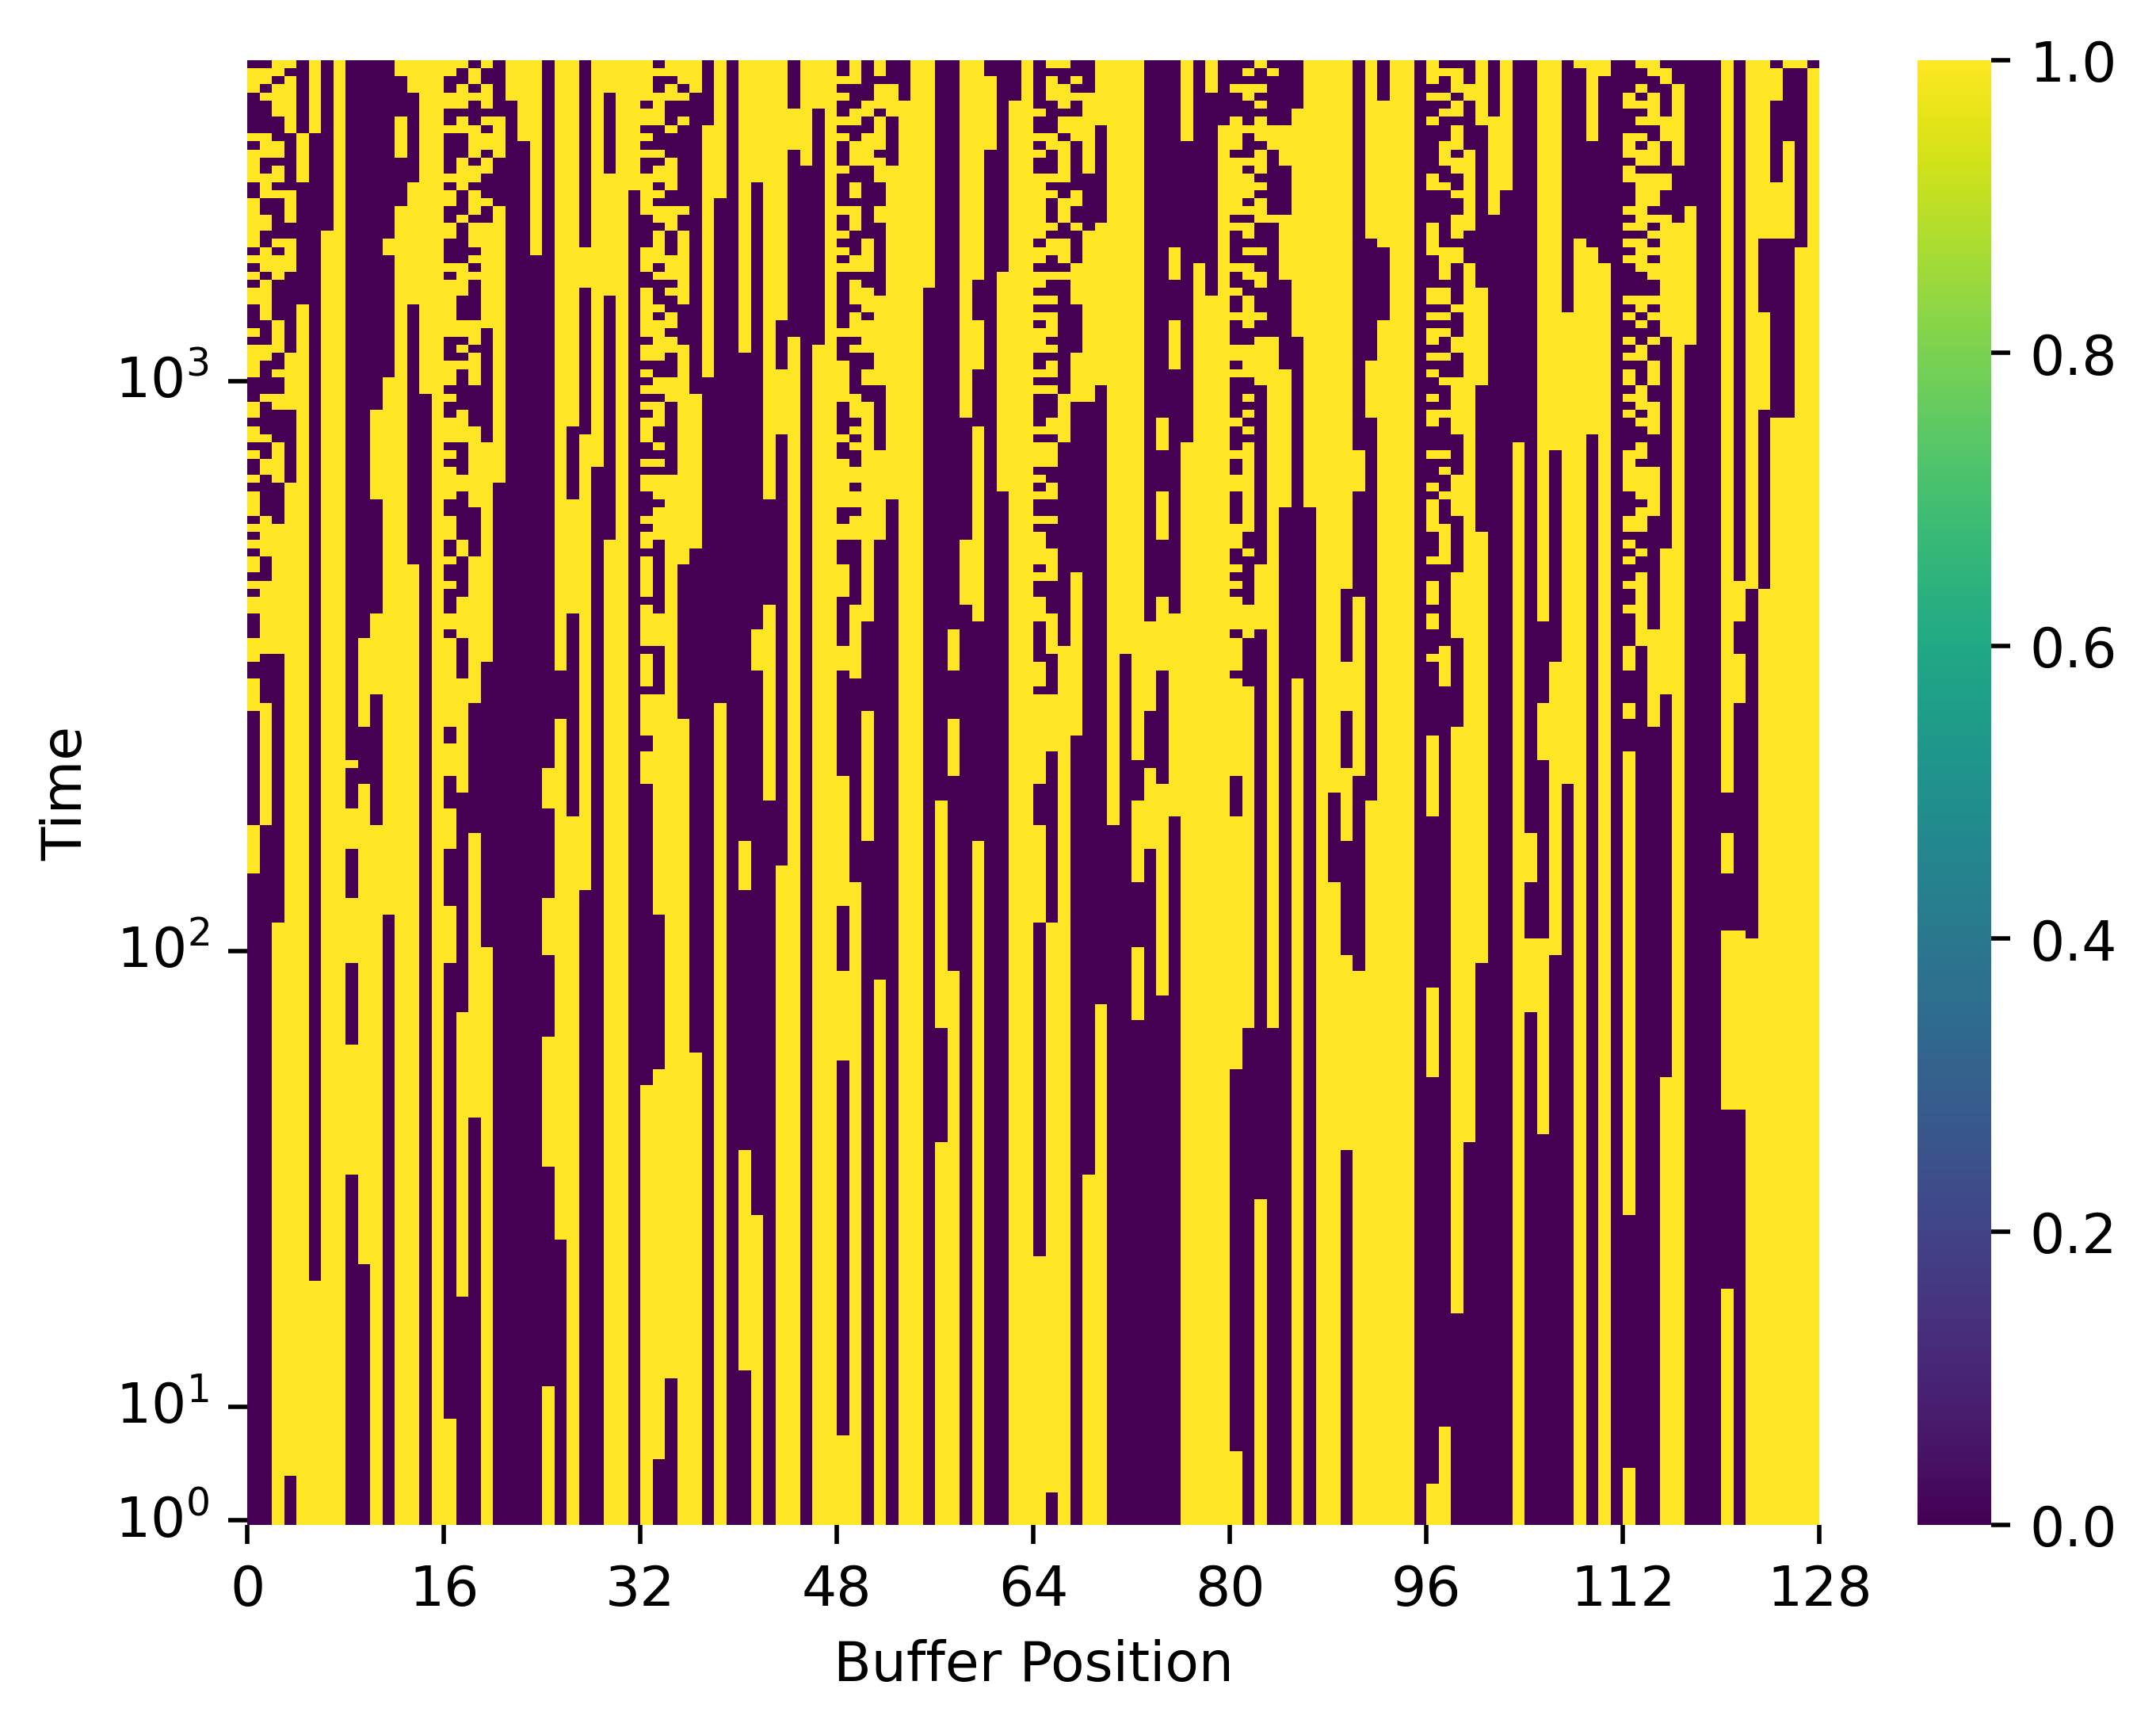

teeplots/03/num-generations=4096+surface-size=128+viz=site-differentia-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/num-generations=4096+surface-size=128+viz=site-differentia-by-rank-heatmap+ynorm=linear+ext=.png


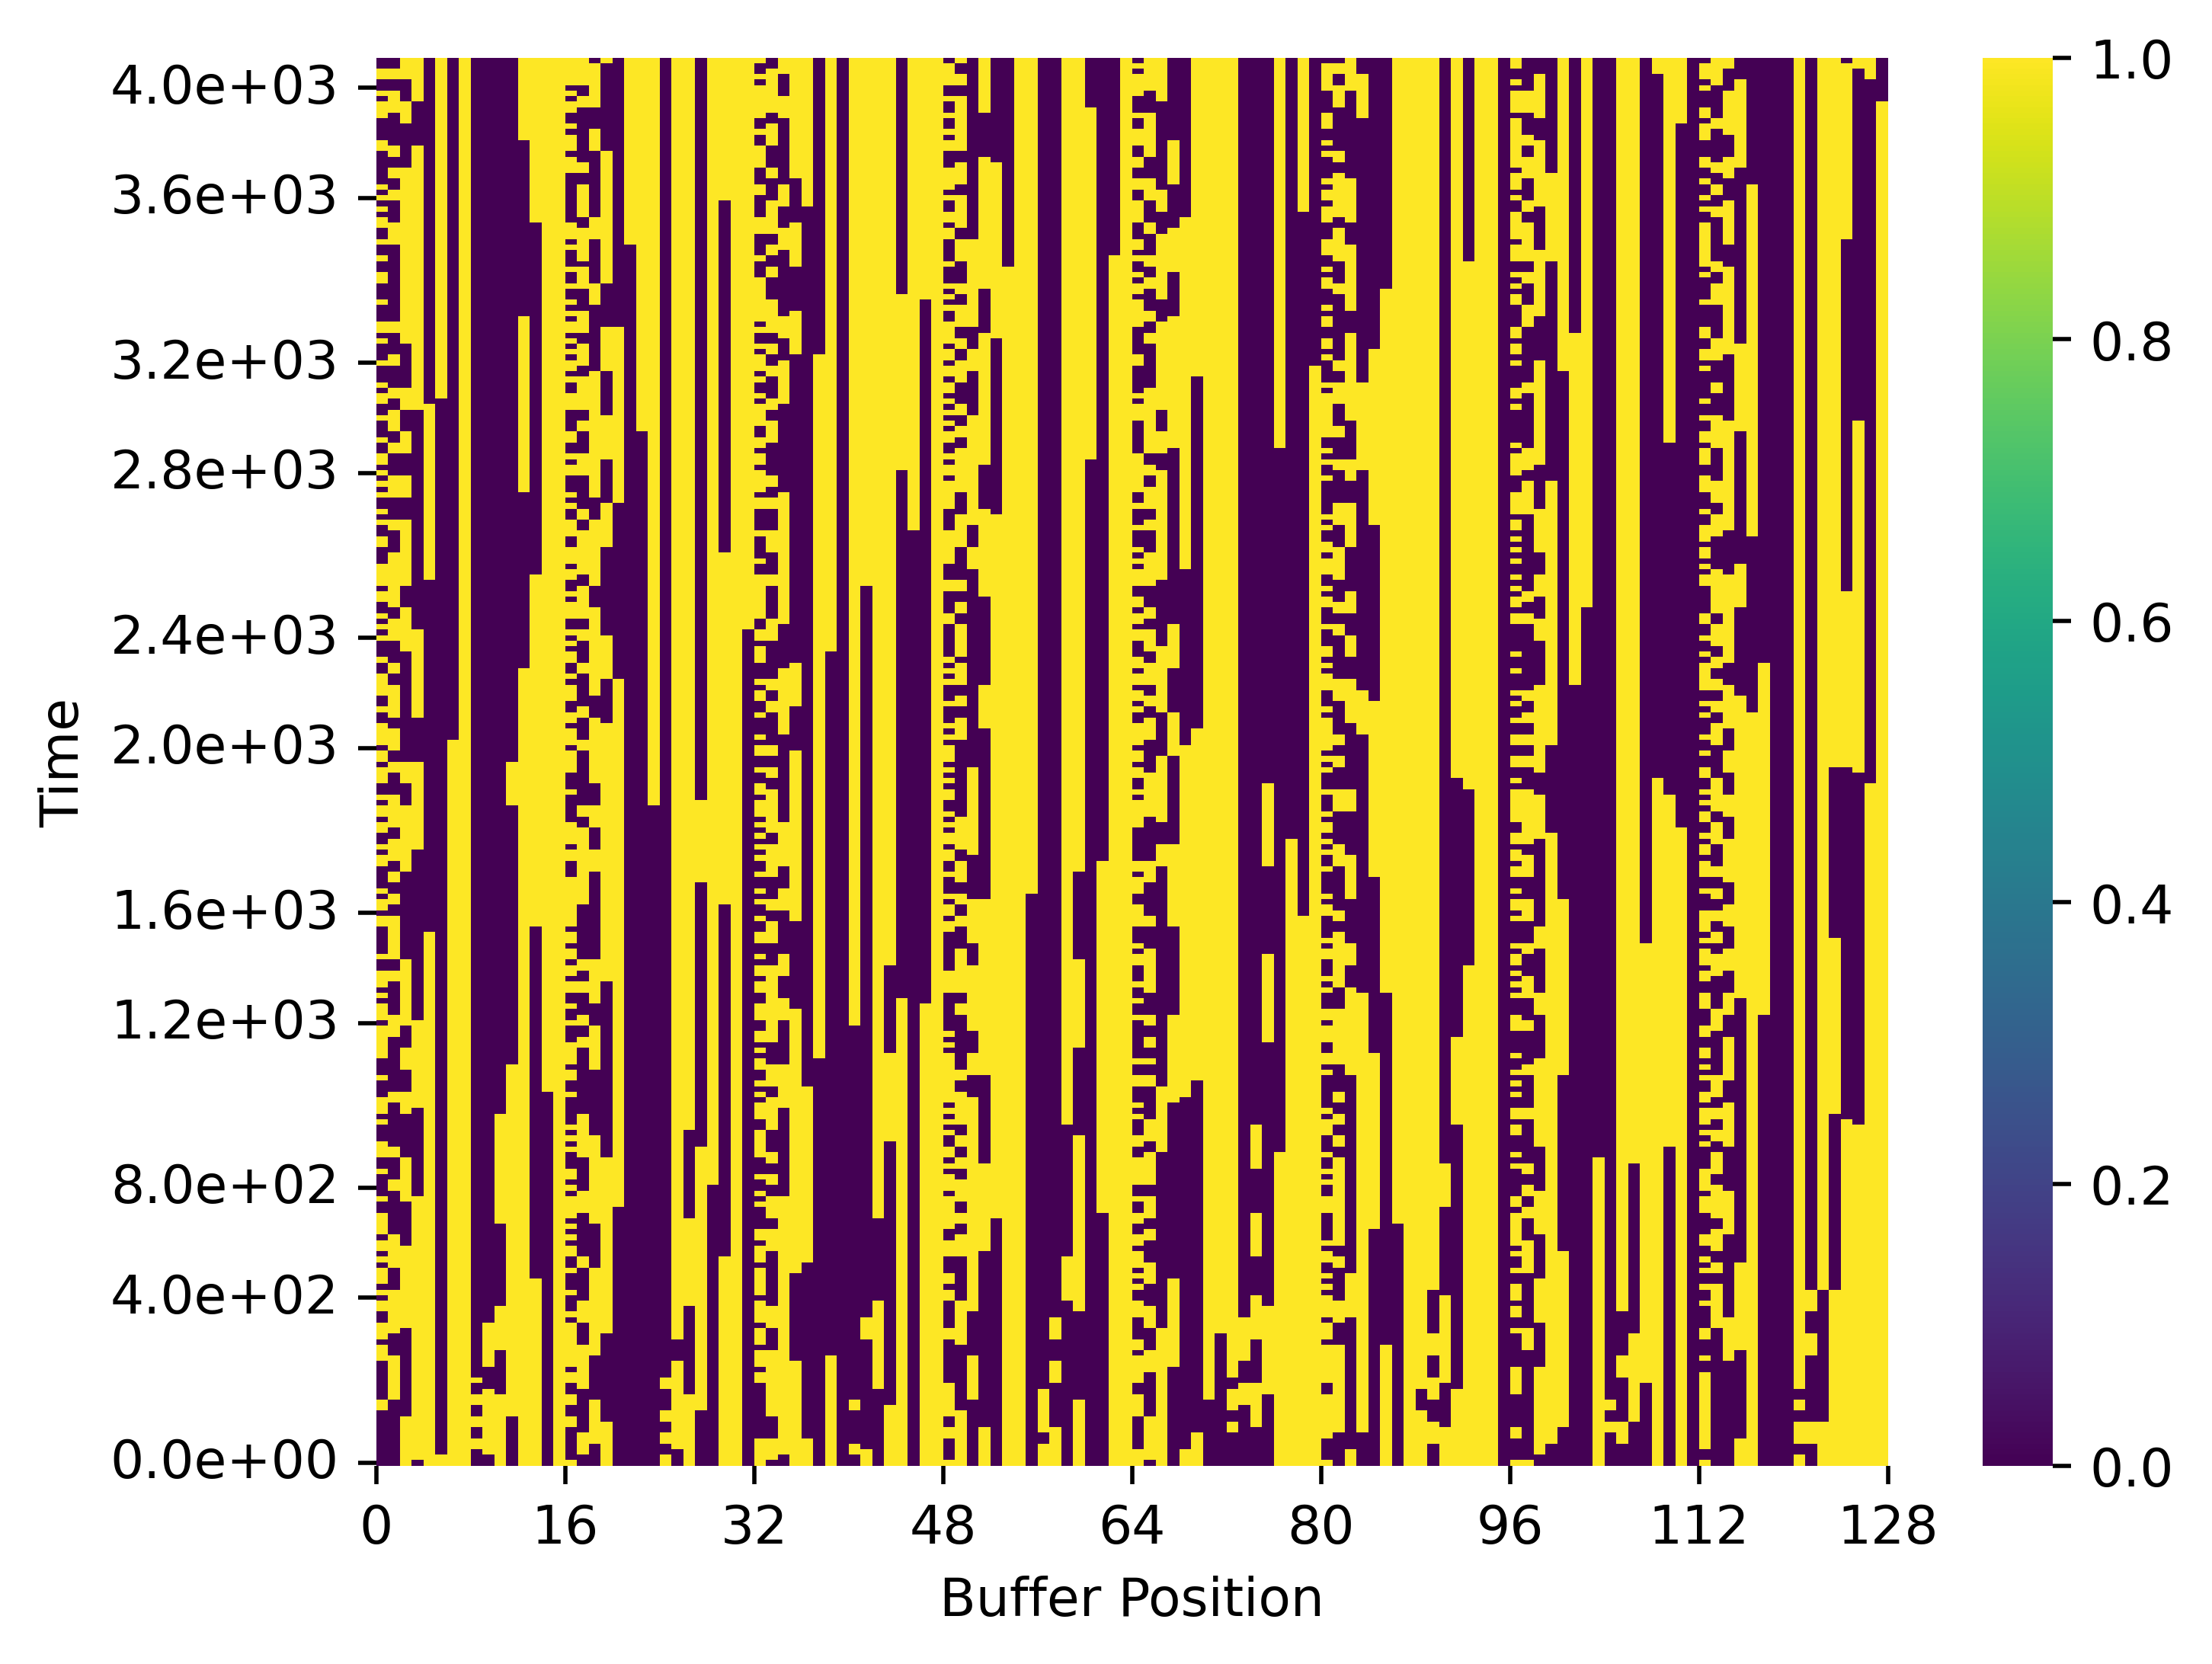

teeplots/03/cnorm=log+num-generations=4096+surface-size=128+viz=site-ingest-rank-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/cnorm=log+num-generations=4096+surface-size=128+viz=site-ingest-rank-by-rank-heatmap+ynorm=log+ext=.png


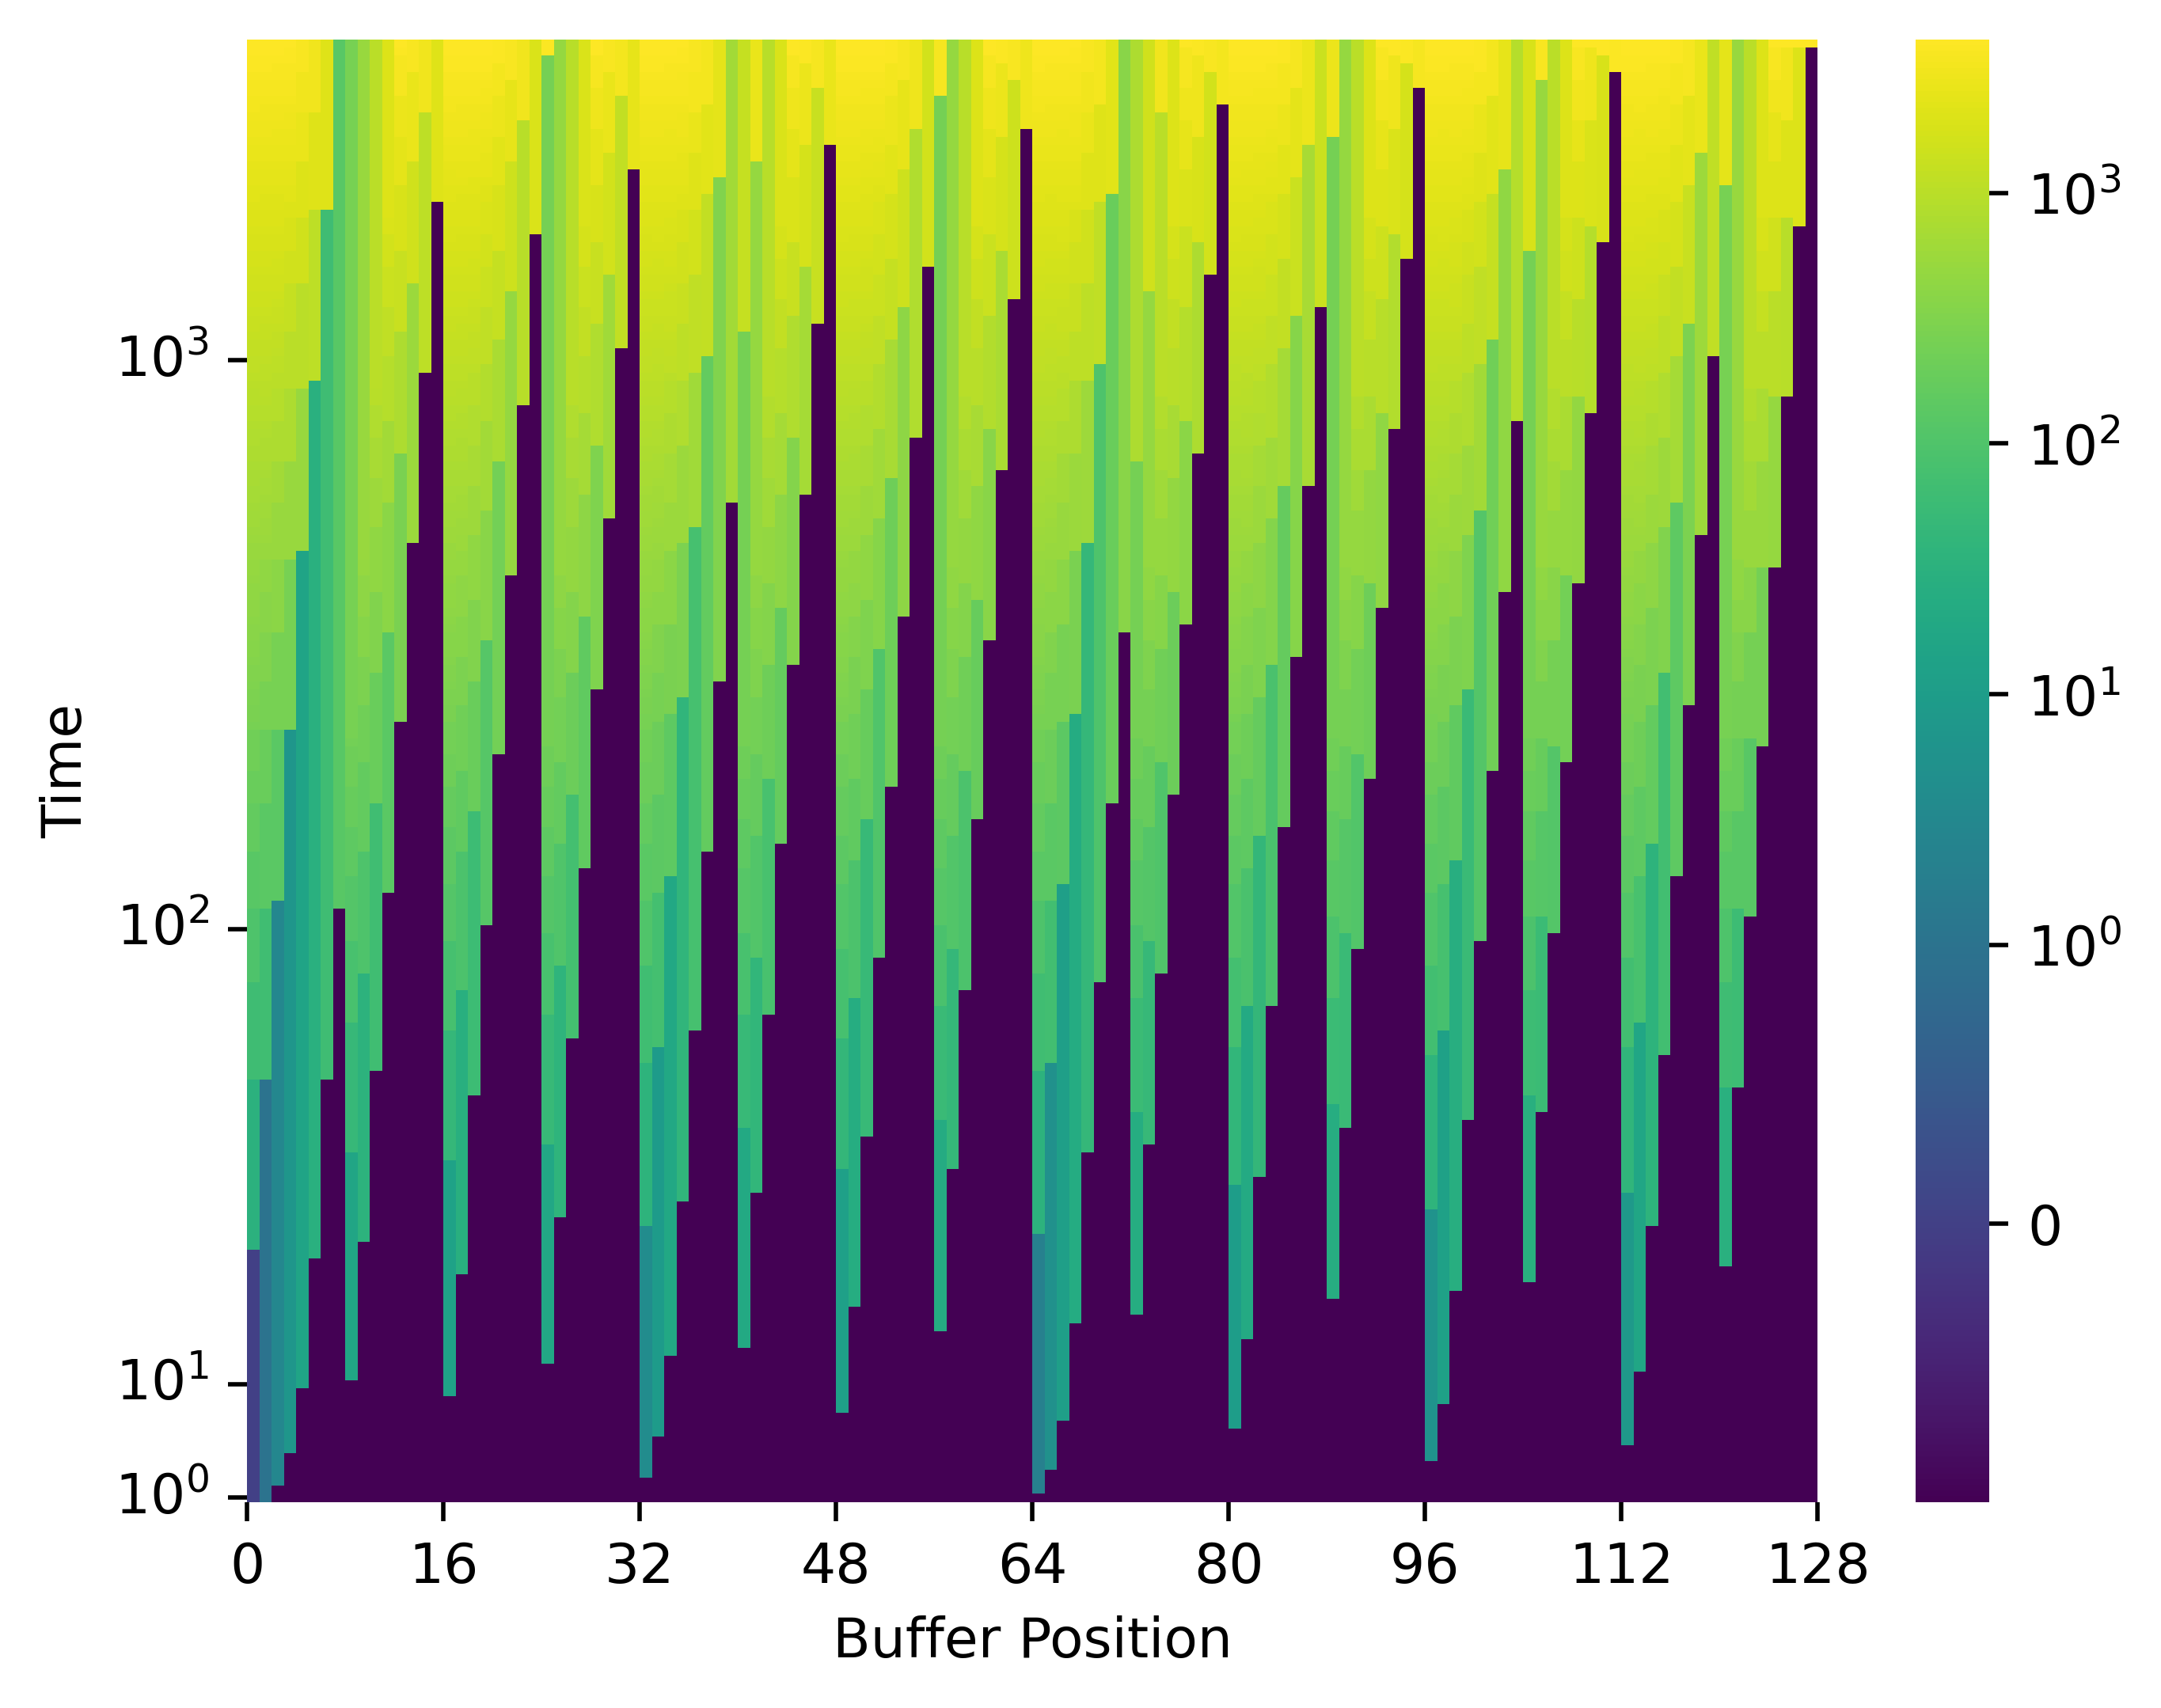

teeplots/03/cnorm=None+num-generations=4096+surface-size=128+viz=site-ingest-rank-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/cnorm=None+num-generations=4096+surface-size=128+viz=site-ingest-rank-by-rank-heatmap+ynorm=linear+ext=.png


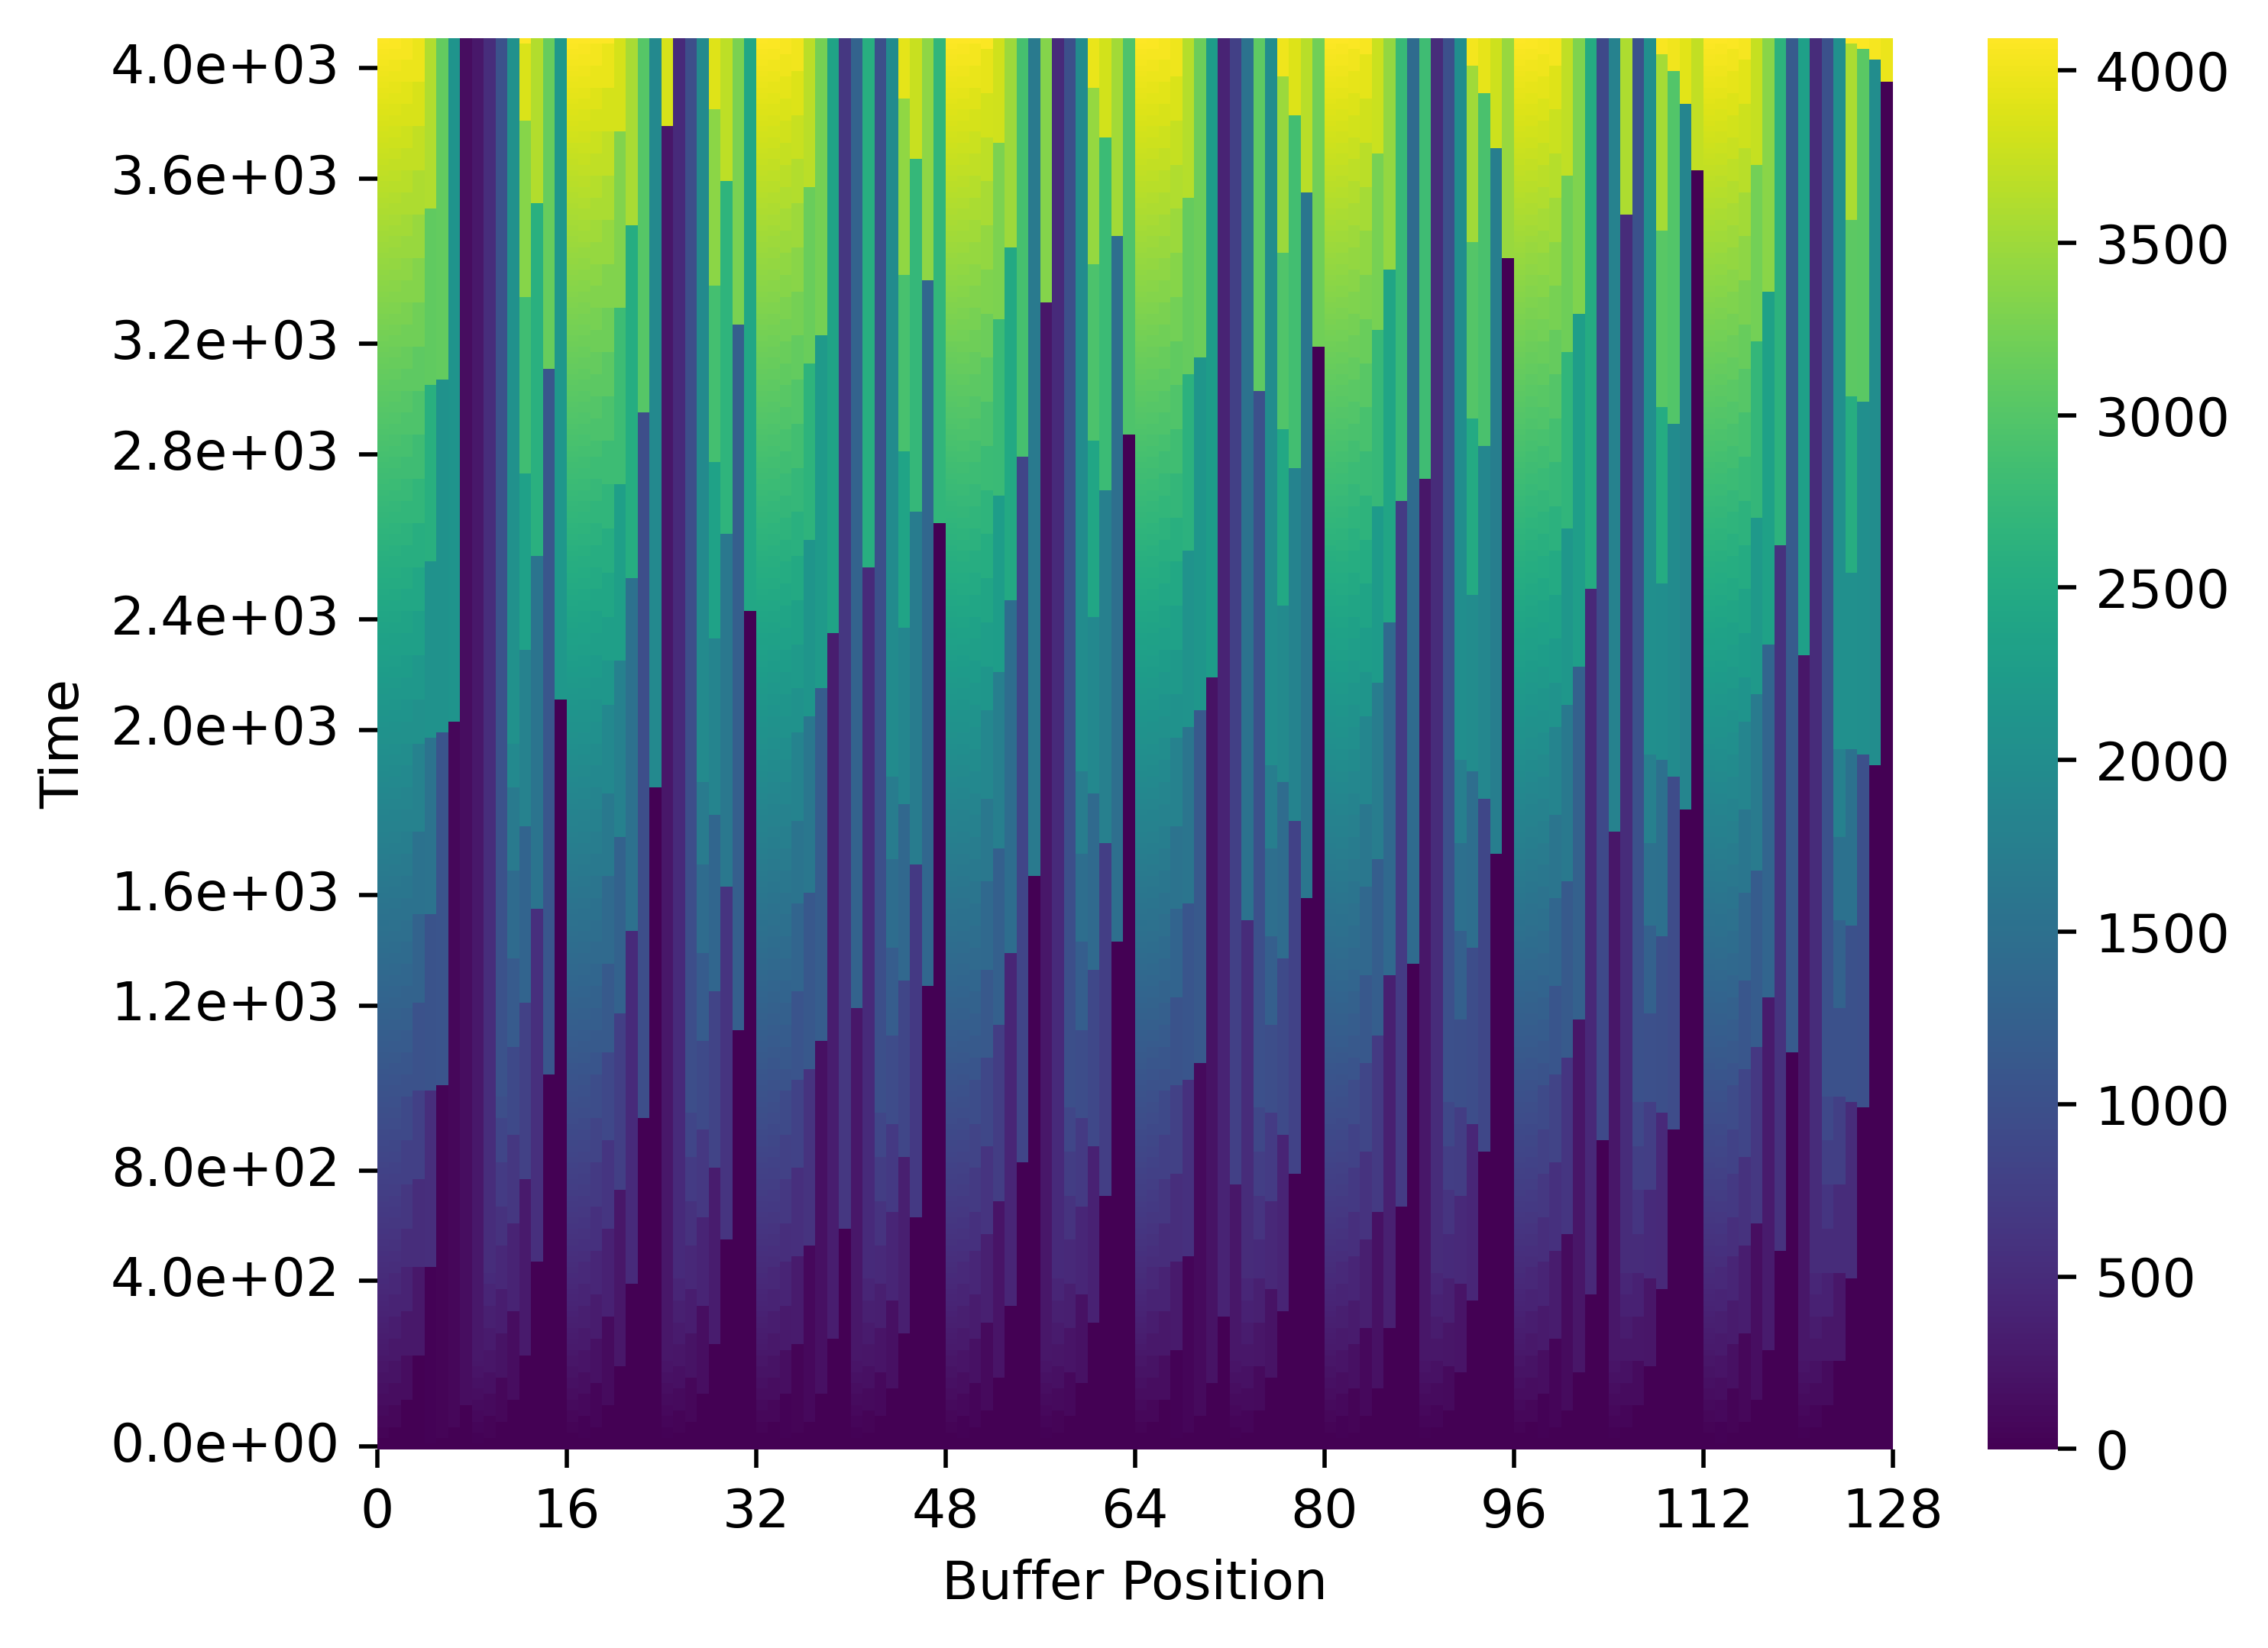

teeplots/03/num-generations=4096+surface-size=128+viz=site-hanoi-value-by-rank-heatmap+ext=.pdf
teeplots/03/num-generations=4096+surface-size=128+viz=site-hanoi-value-by-rank-heatmap+ext=.png


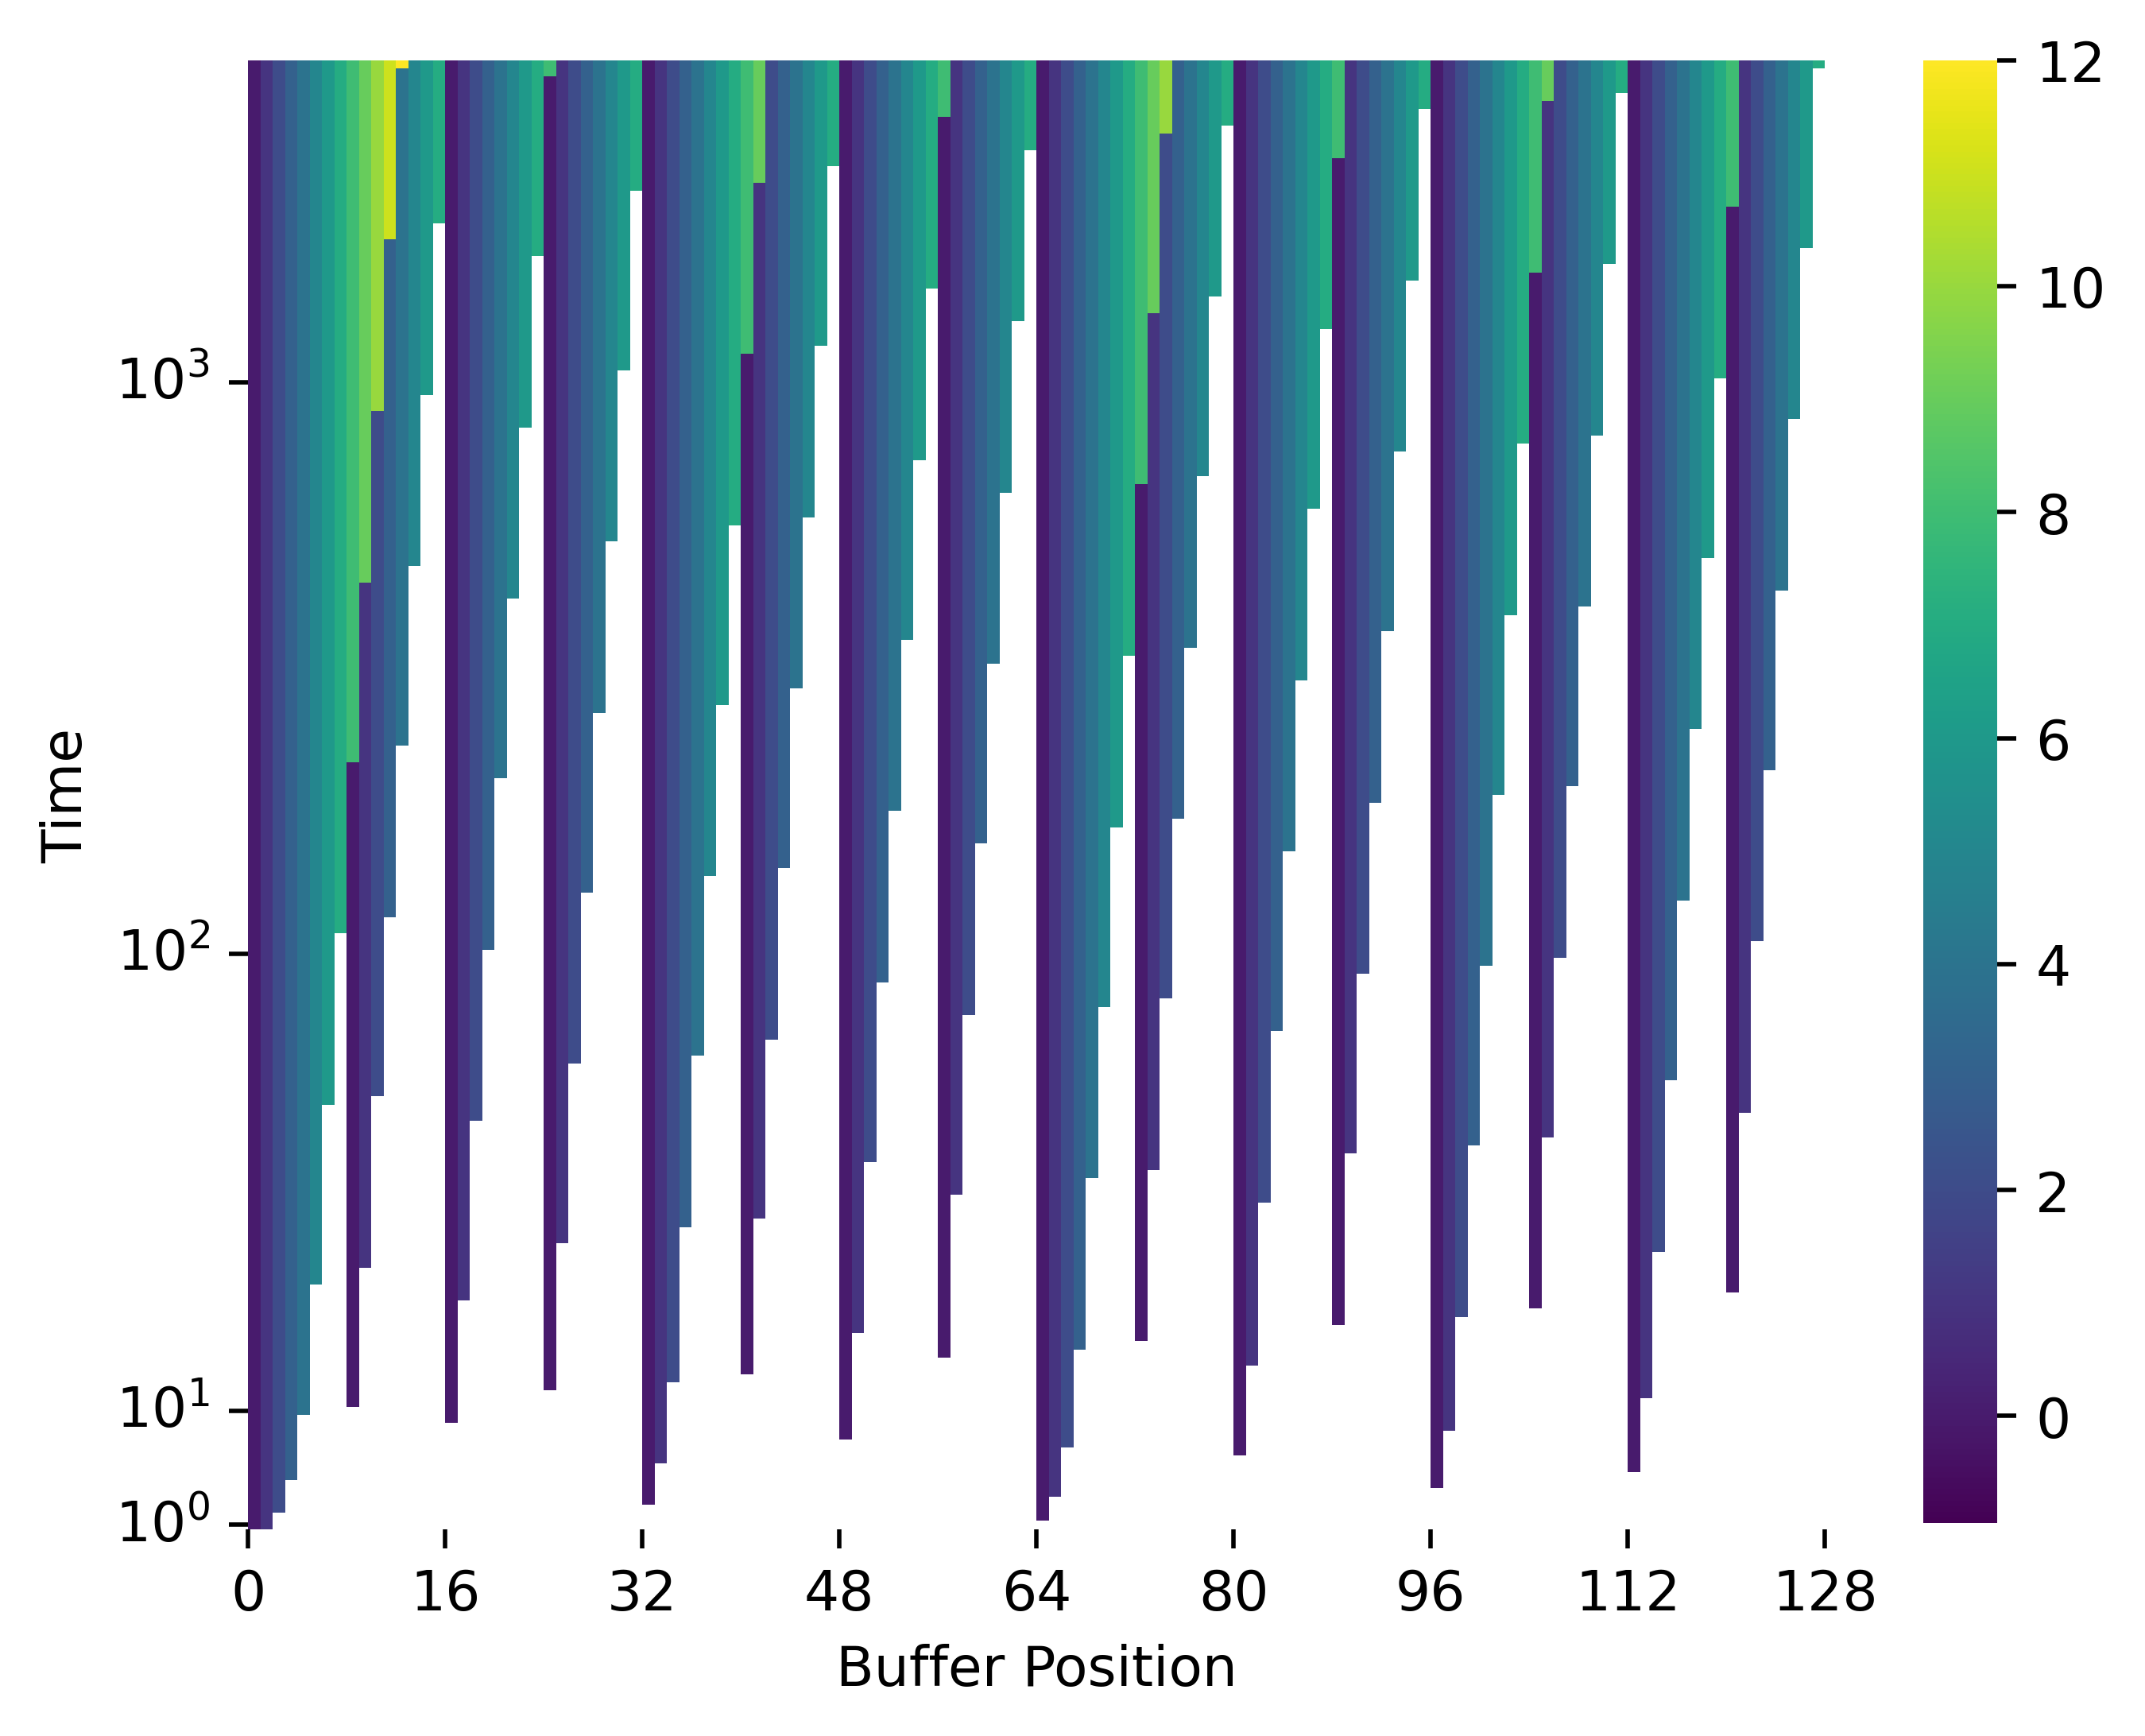

teeplots/03/num-generations=4096+surface-size=128+viz=site-hanoi-value-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/num-generations=4096+surface-size=128+viz=site-hanoi-value-by-rank-heatmap+ynorm=linear+ext=.png


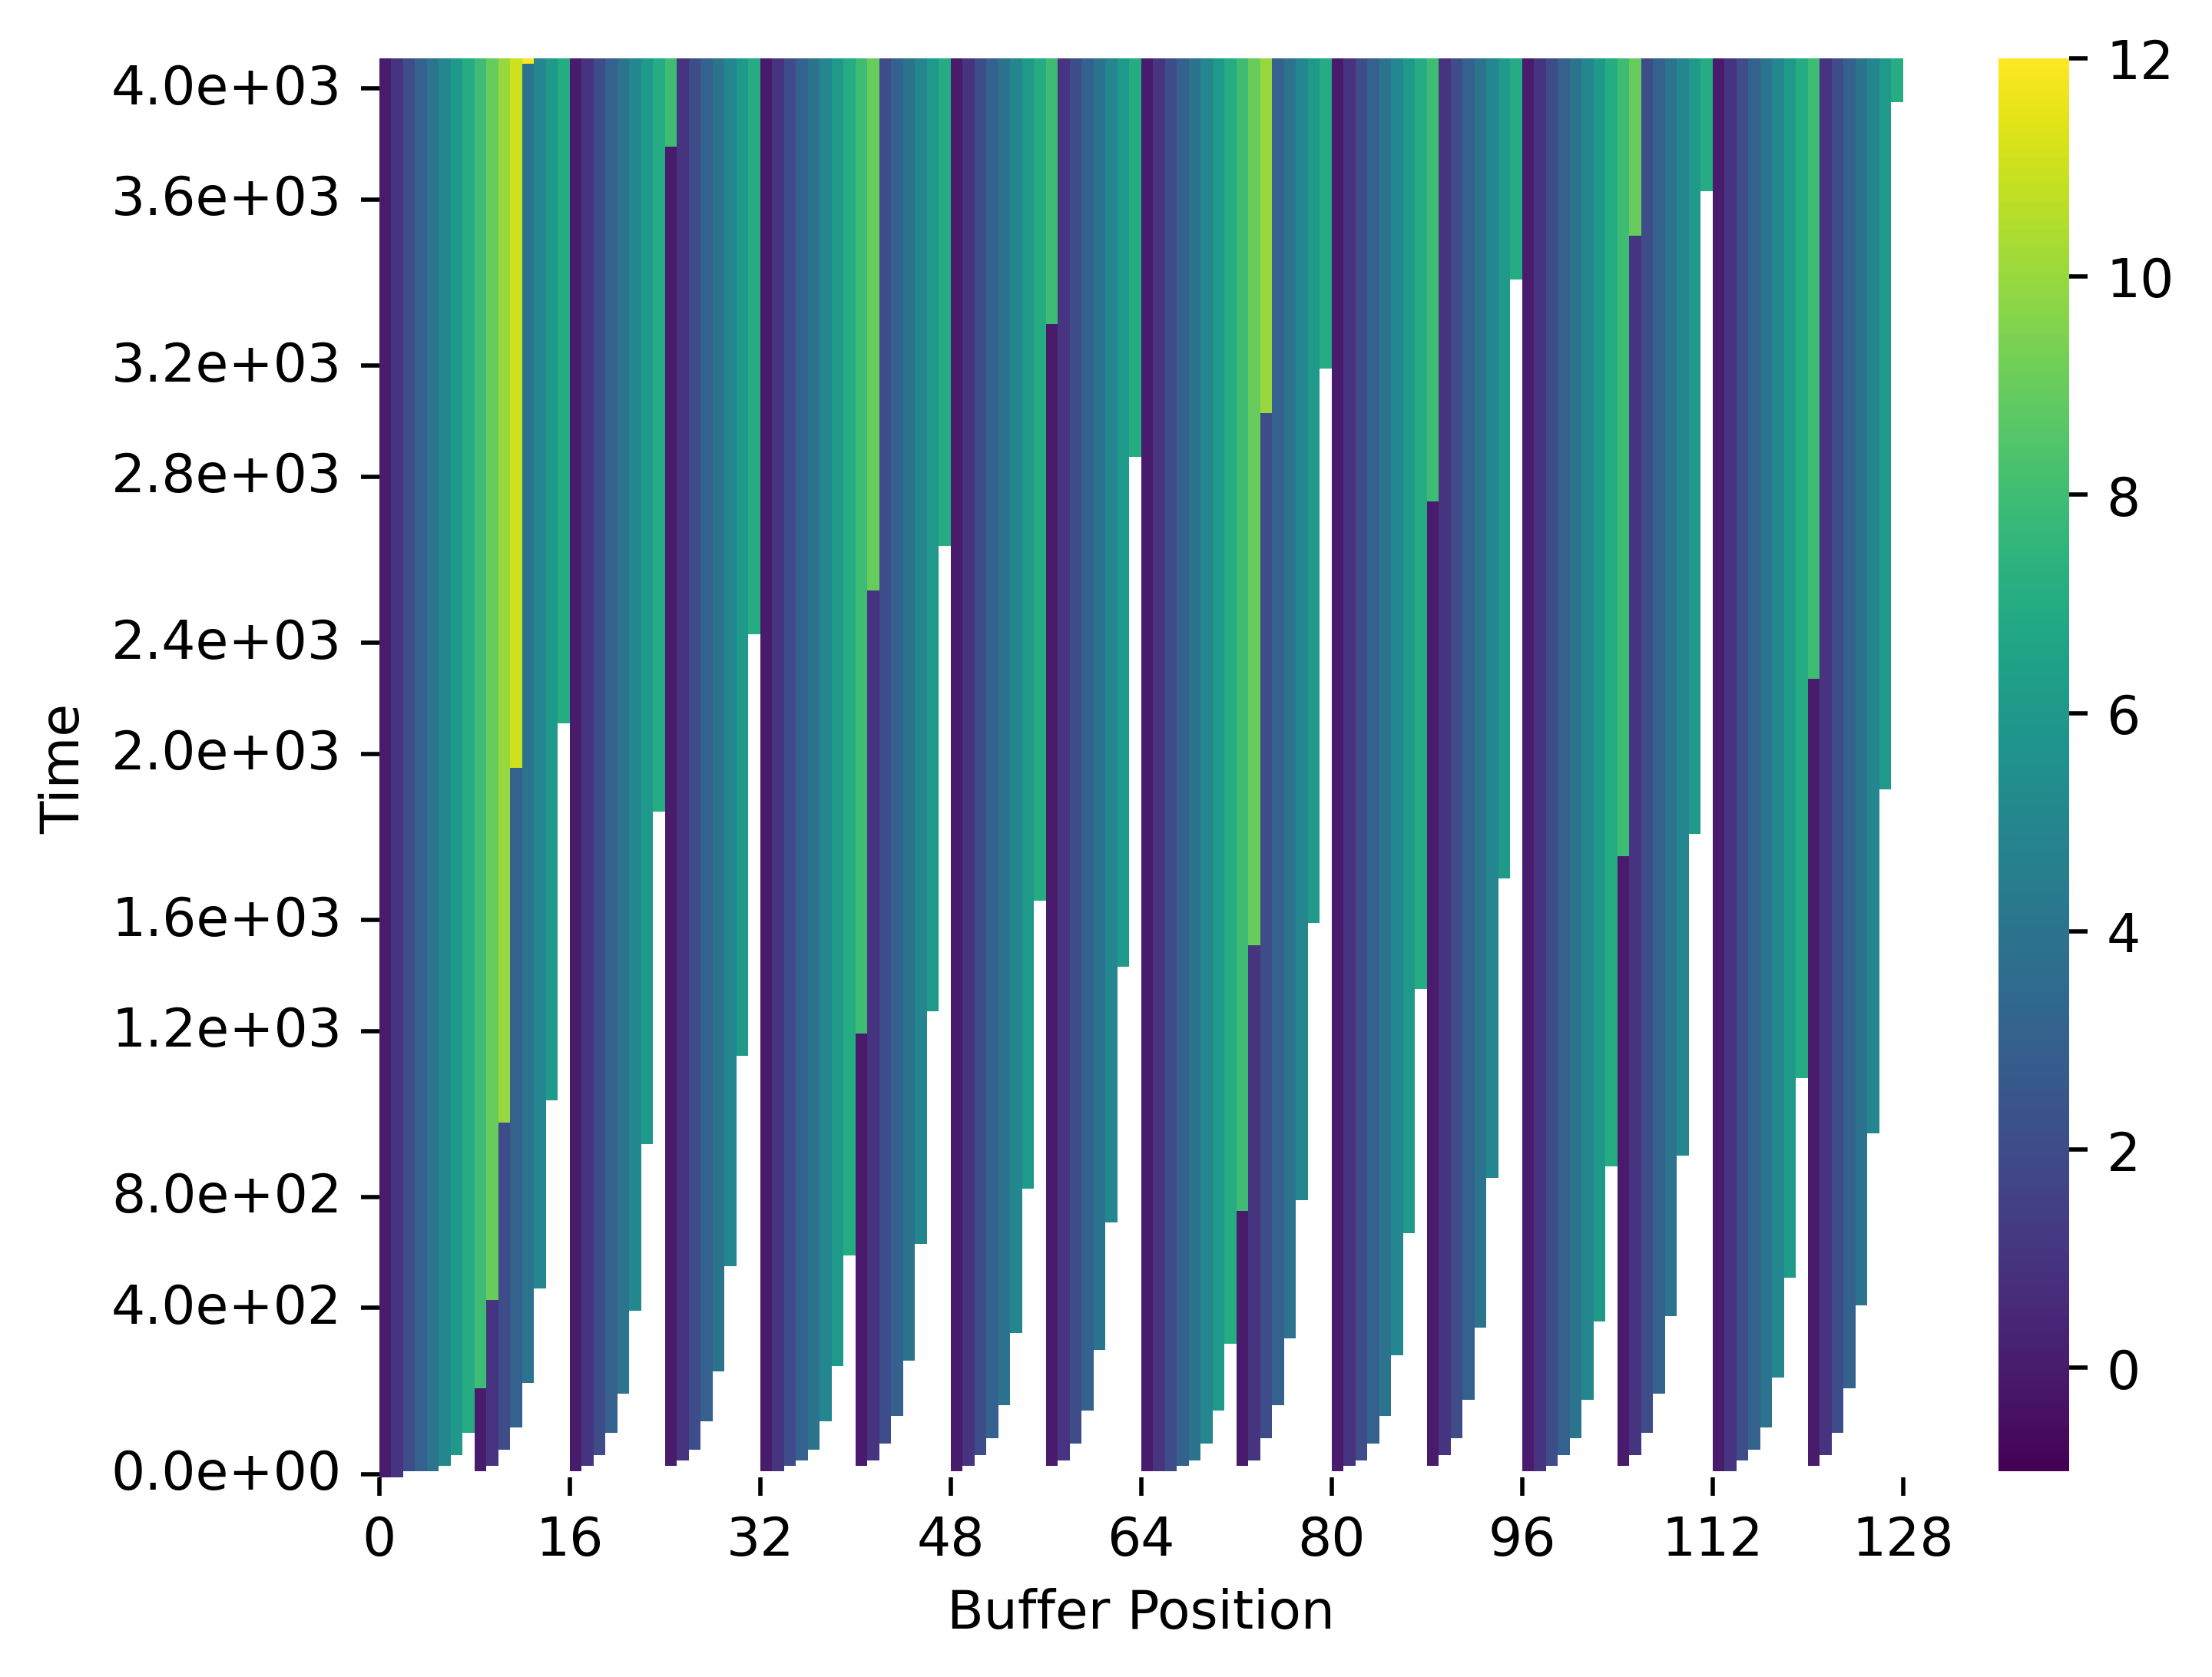

teeplots/03/cnorm=log+num-generations=4096+surface-size=128+viz=site-ingest-depth-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/cnorm=log+num-generations=4096+surface-size=128+viz=site-ingest-depth-by-rank-heatmap+ynorm=log+ext=.png


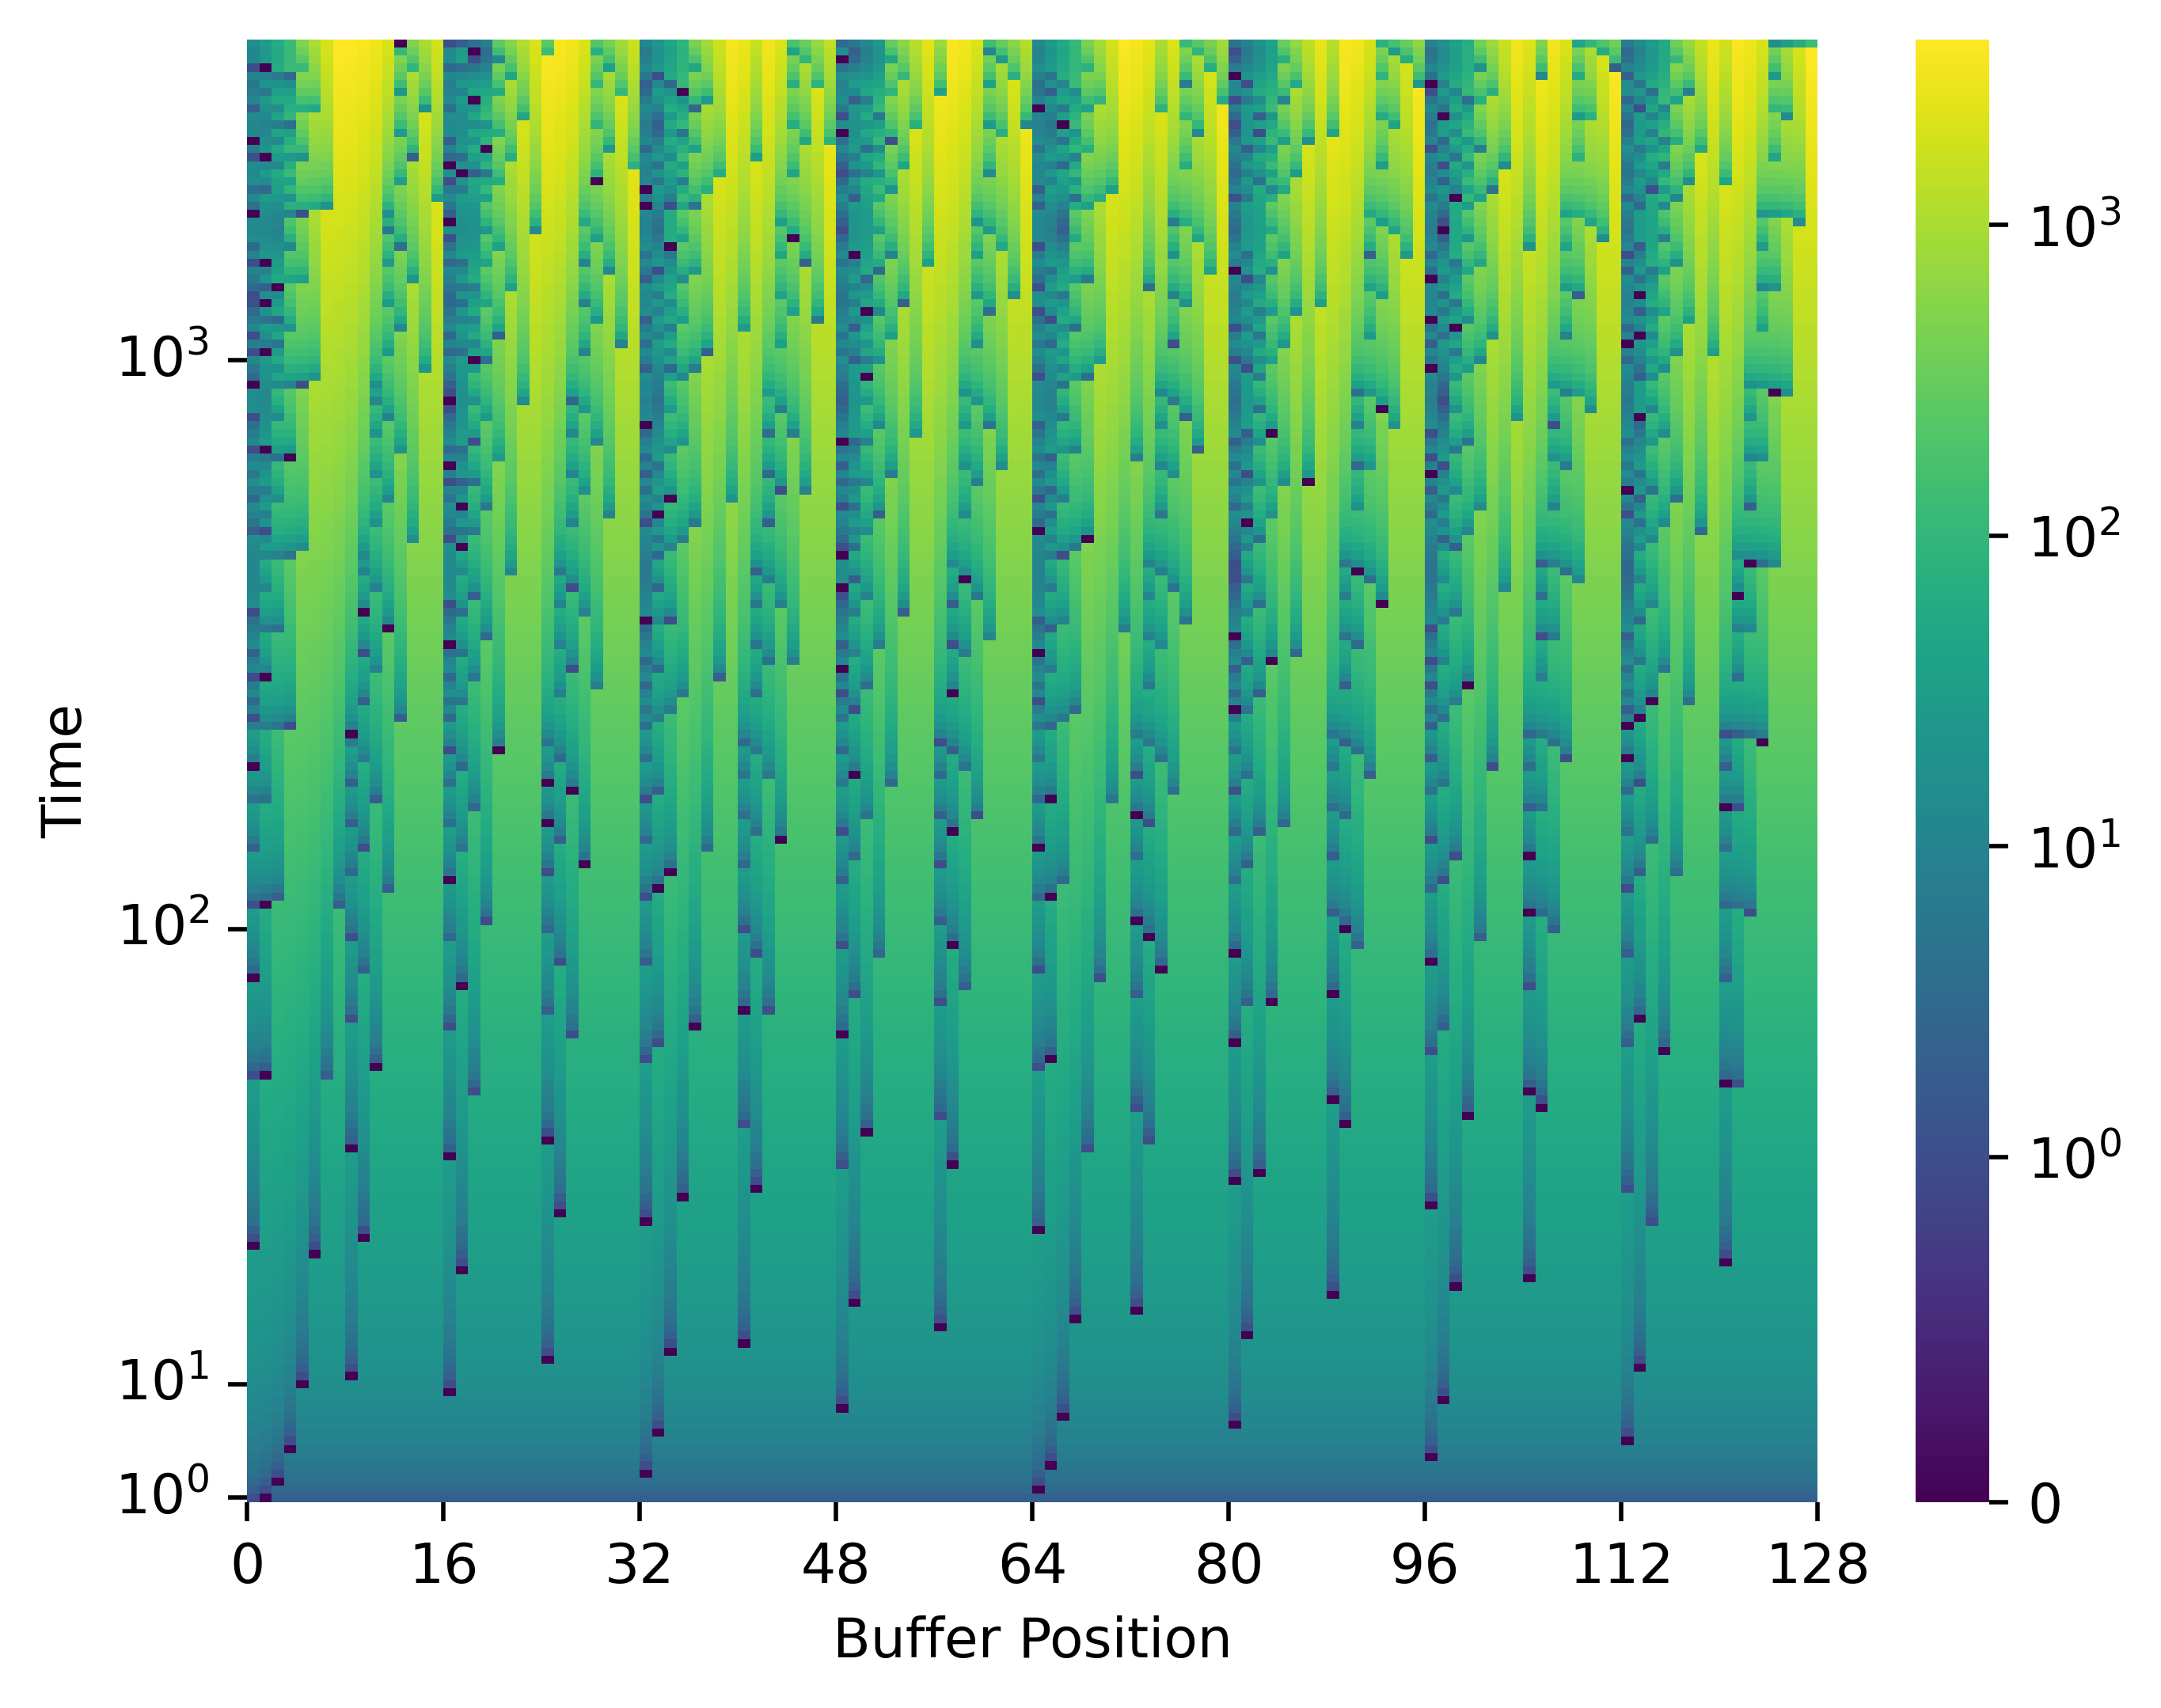

teeplots/03/cnorm=log+num-generations=4096+surface-size=128+viz=site-ingest-depth-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/cnorm=log+num-generations=4096+surface-size=128+viz=site-ingest-depth-by-rank-heatmap+ynorm=linear+ext=.png


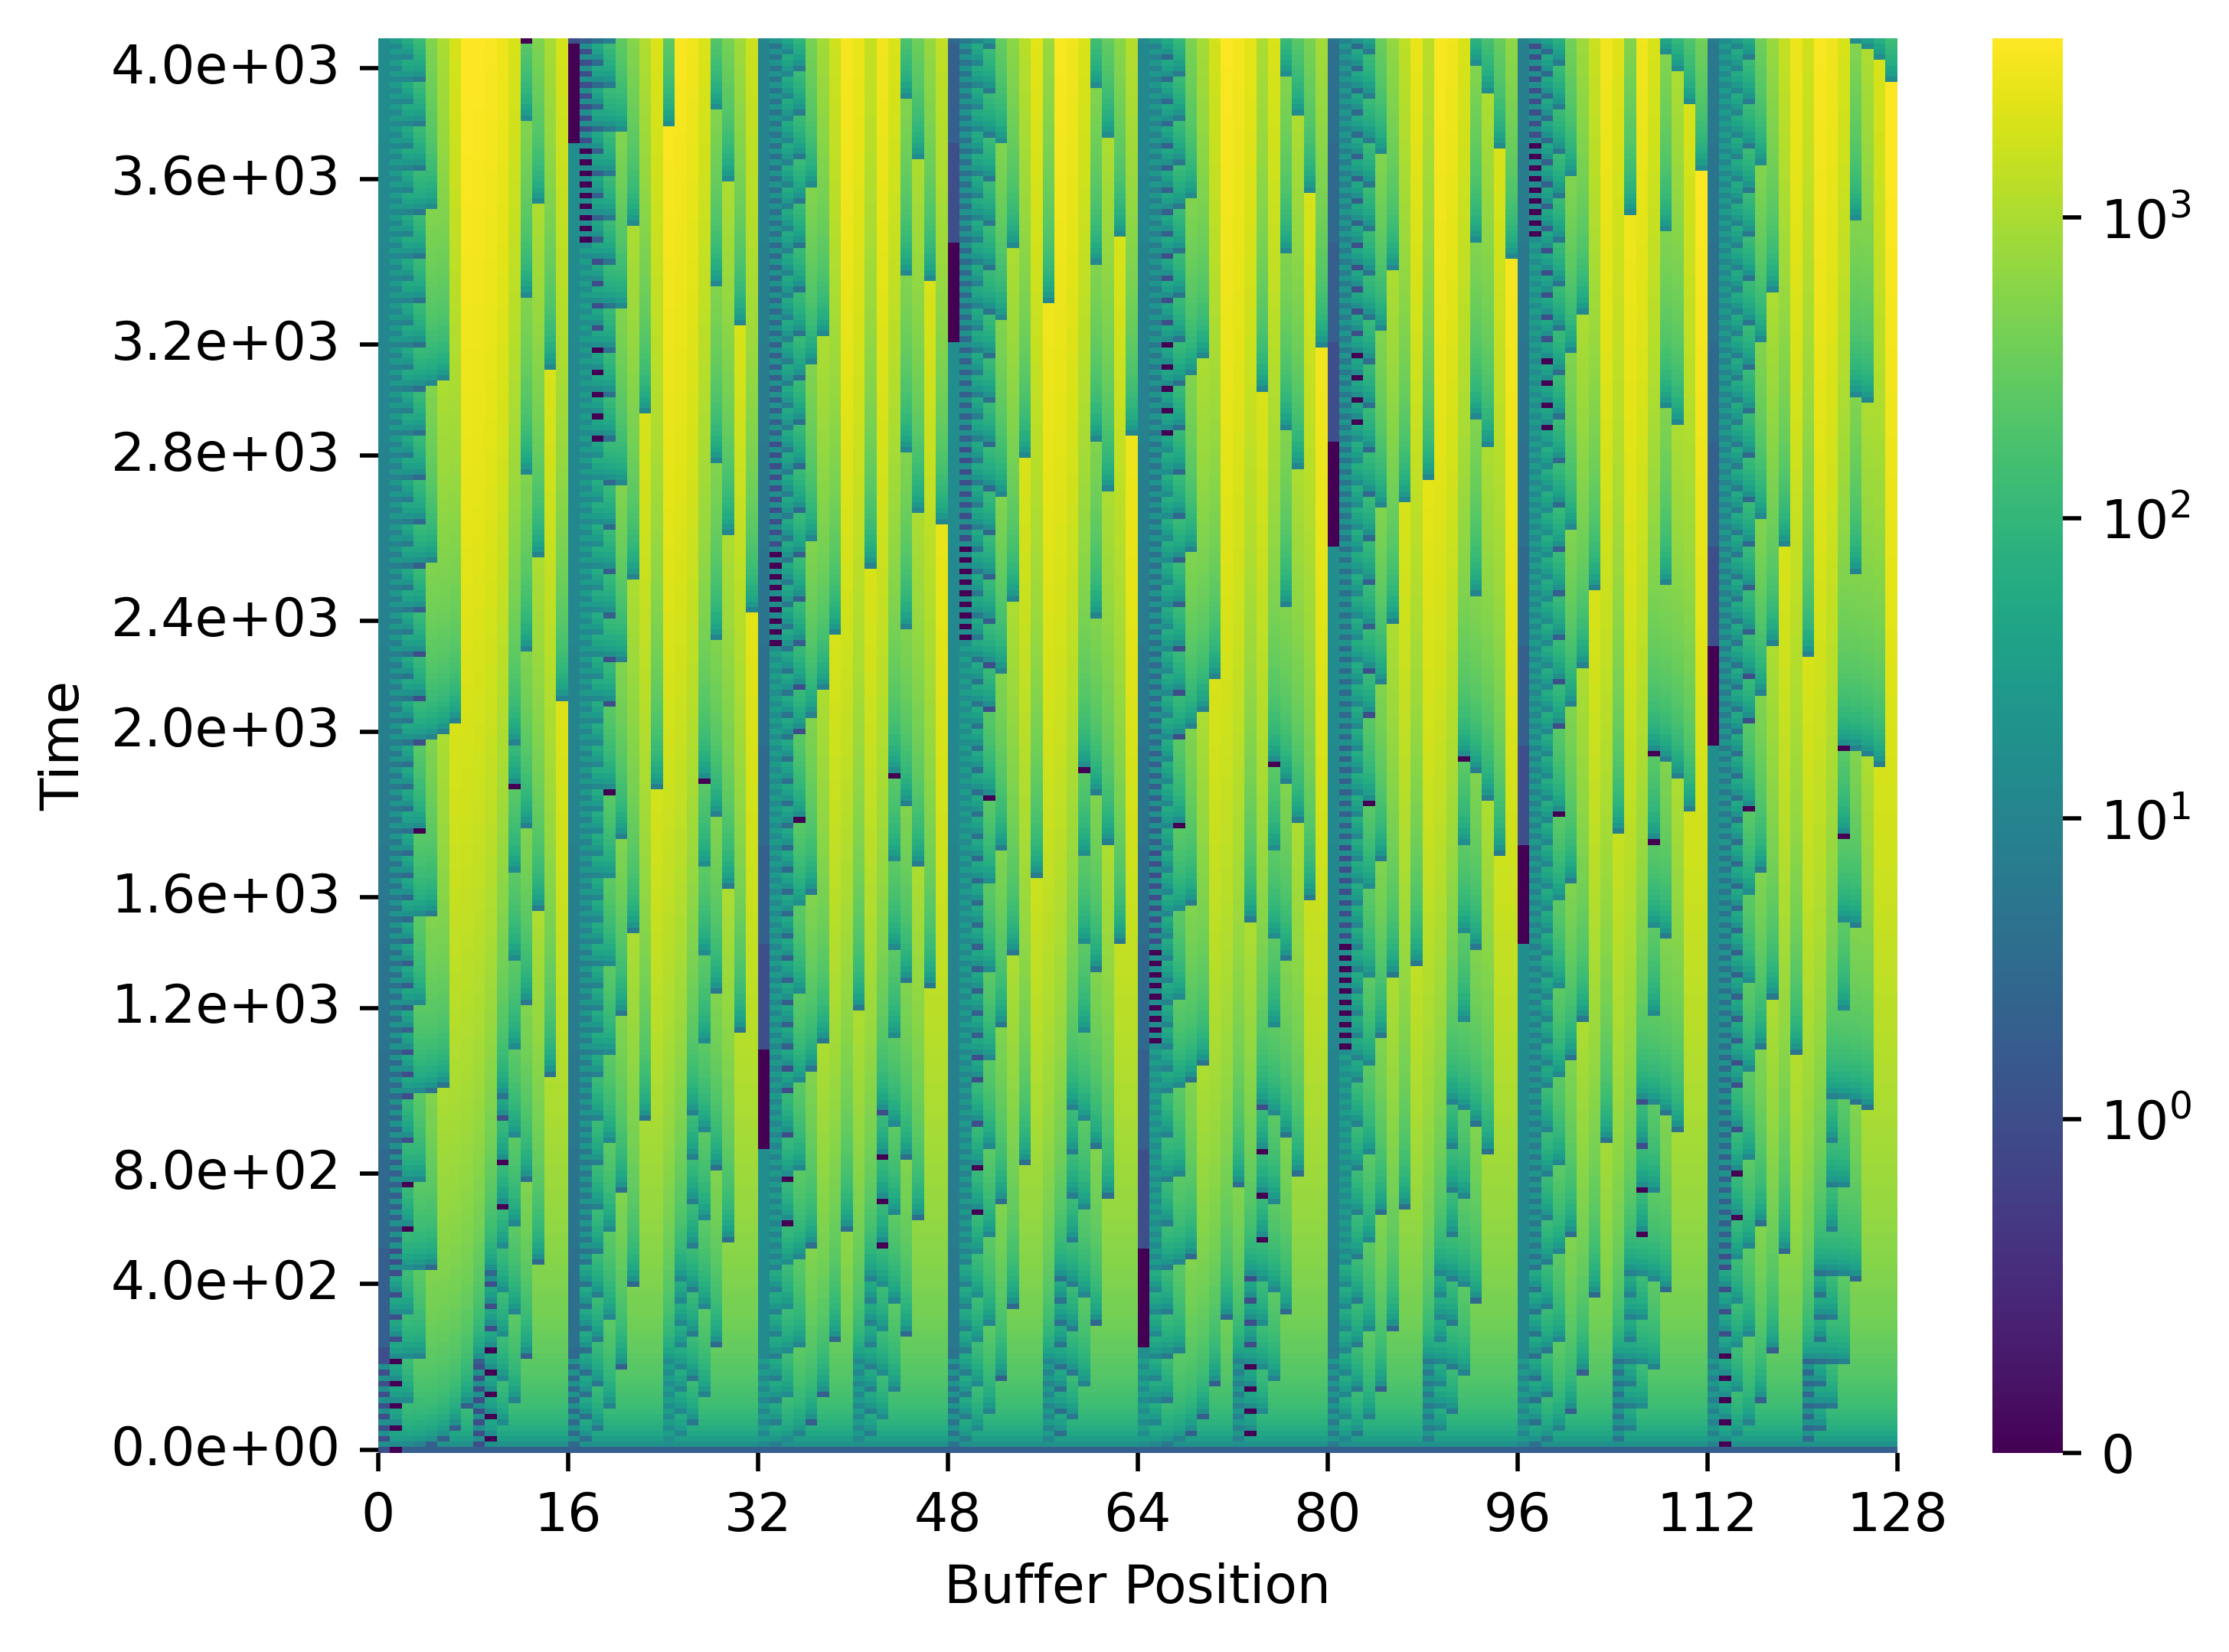

100%|██████████| 2998/2998 [00:10<00:00, 294.13it/s]


teeplots/03/num-generations=4096+surface-size=128+viz=stratum-persistence-dripplot+ext=.pdf
teeplots/03/num-generations=4096+surface-size=128+viz=stratum-persistence-dripplot+ext=.png


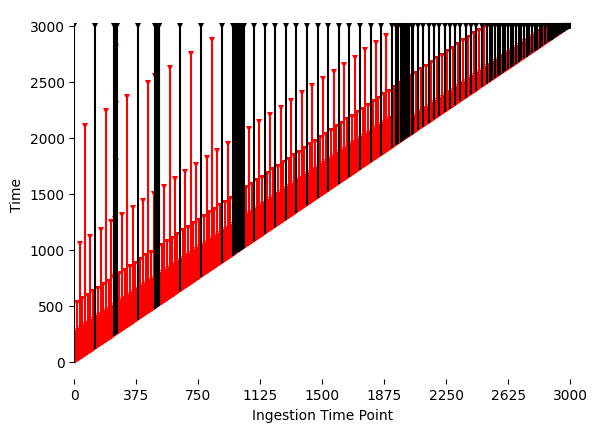

100%|██████████| 4096/4096 [00:00<00:00, 4856.00it/s]


teeplots/03/num-generations=4096+surface-size=512+viz=site-differentia-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/num-generations=4096+surface-size=512+viz=site-differentia-by-rank-heatmap+ynorm=log+ext=.png


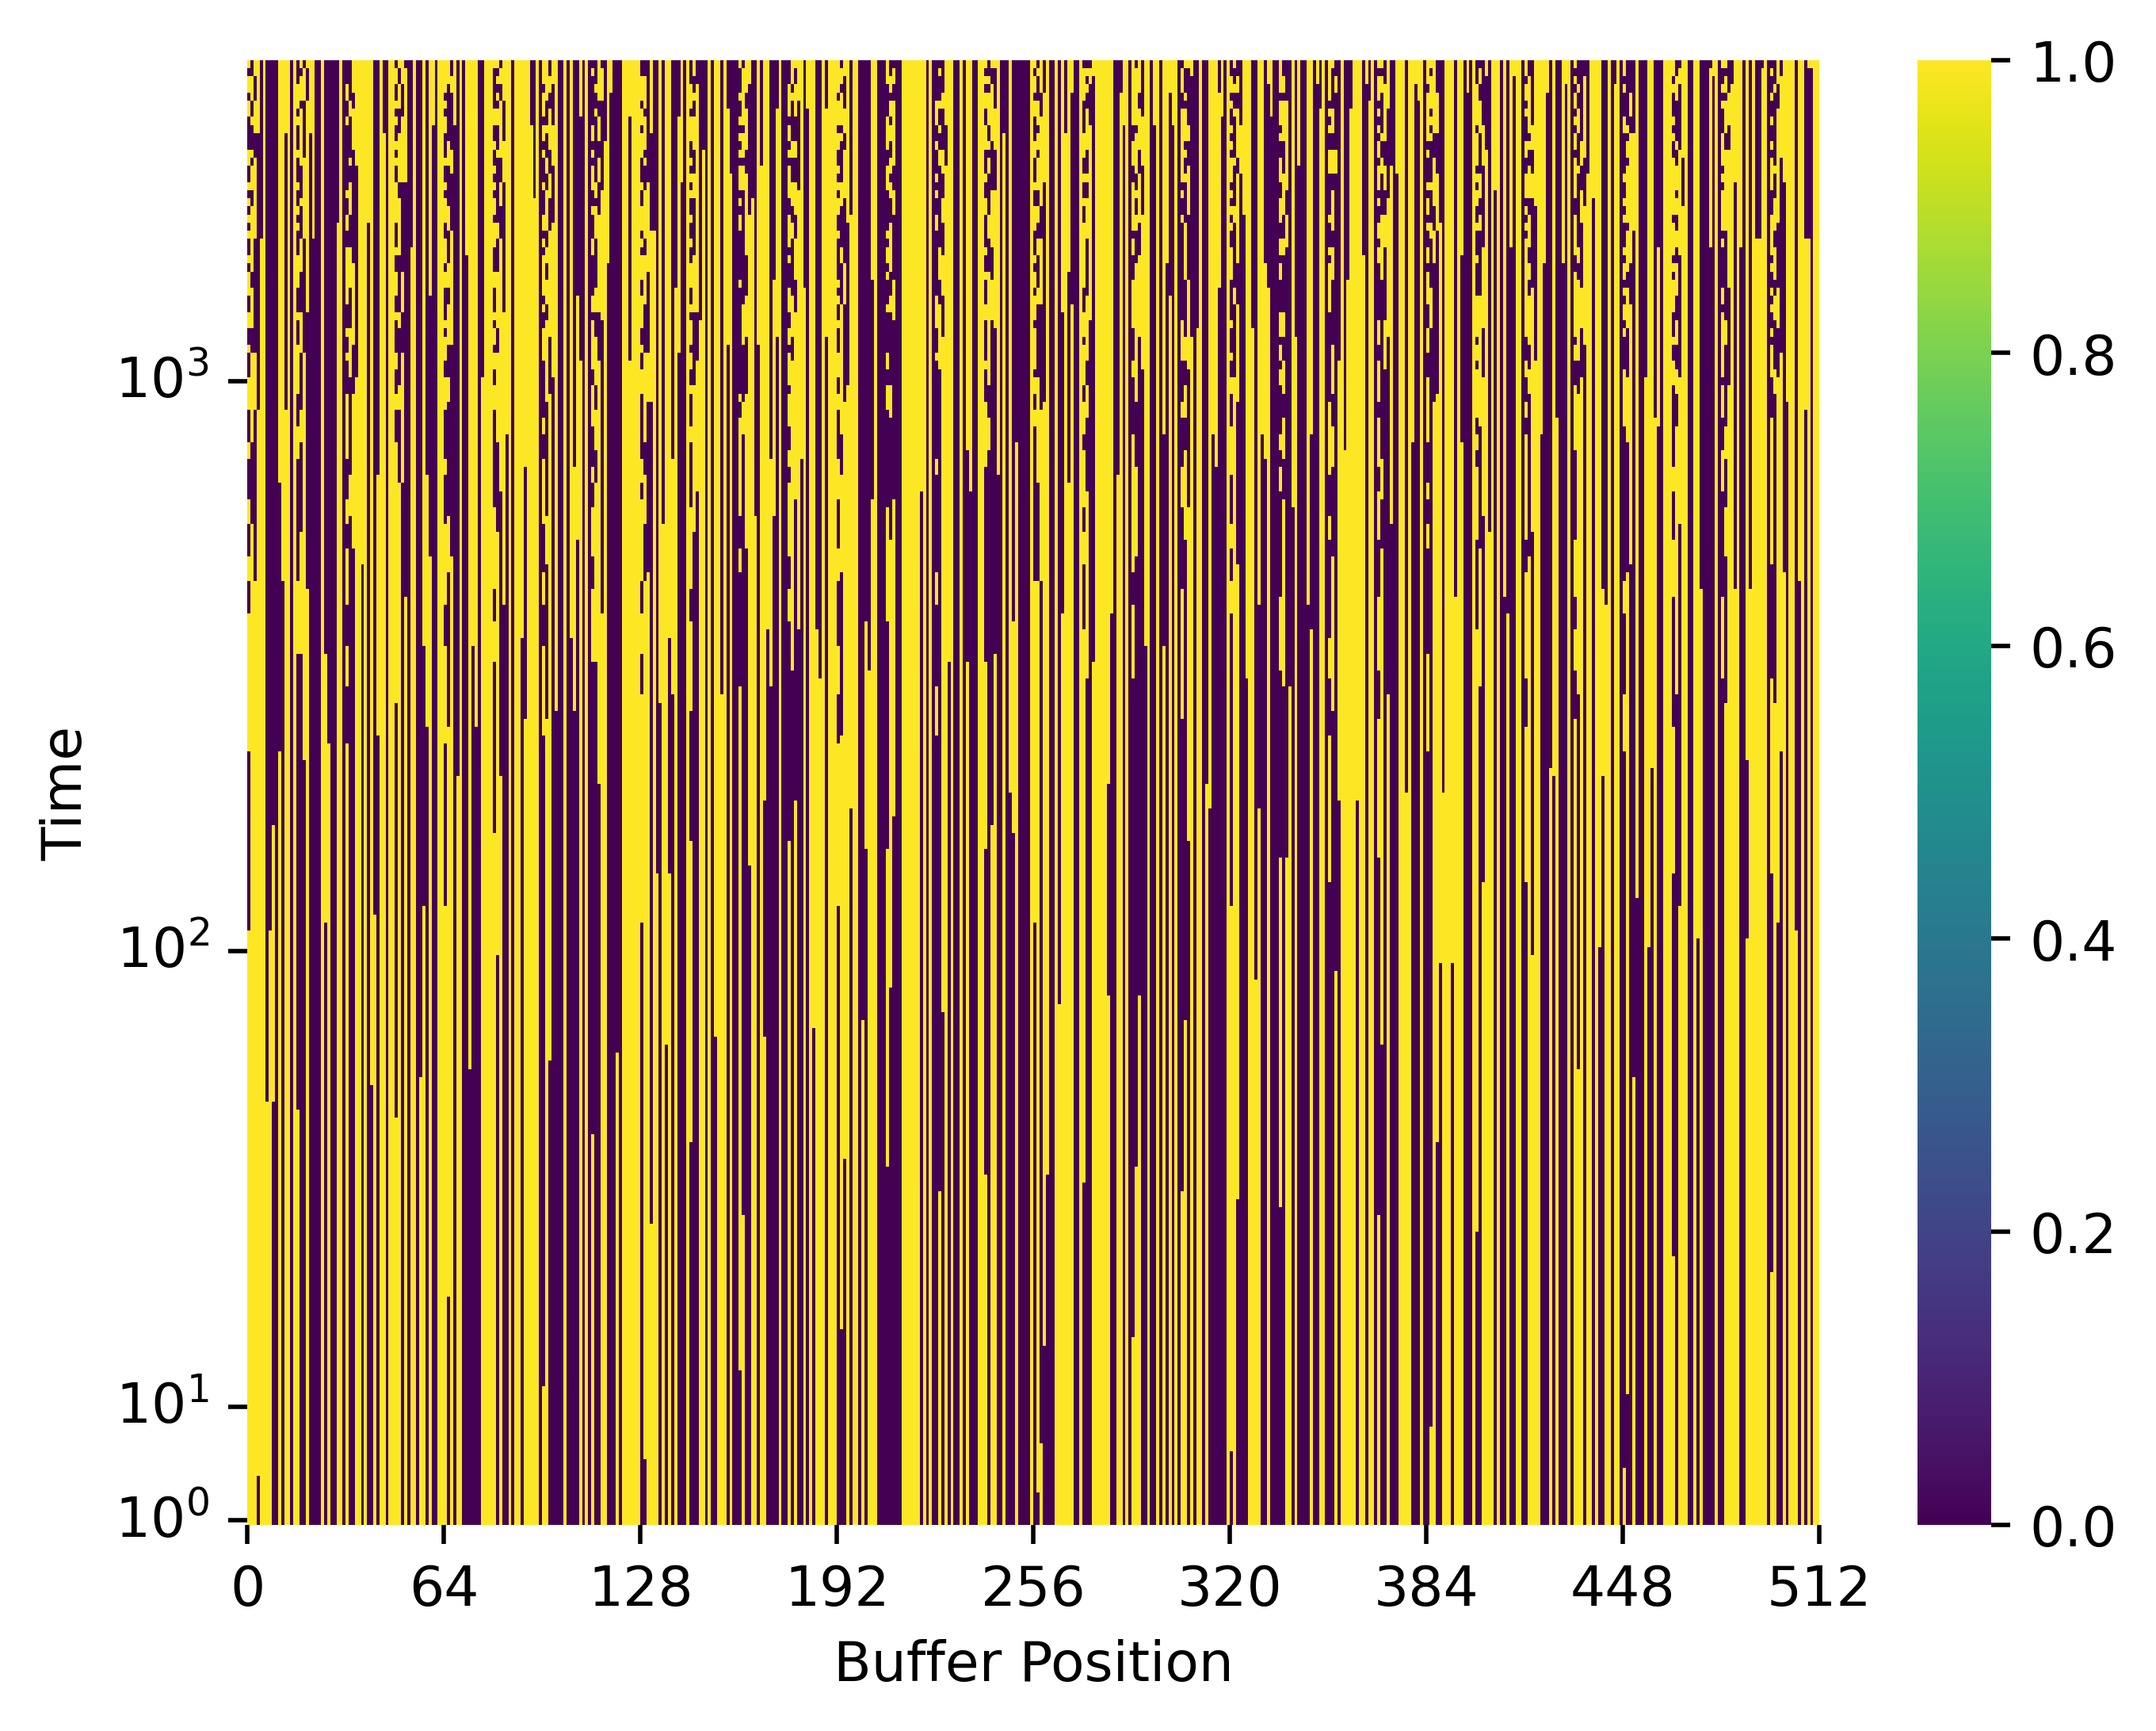

teeplots/03/num-generations=4096+surface-size=512+viz=site-differentia-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/num-generations=4096+surface-size=512+viz=site-differentia-by-rank-heatmap+ynorm=linear+ext=.png


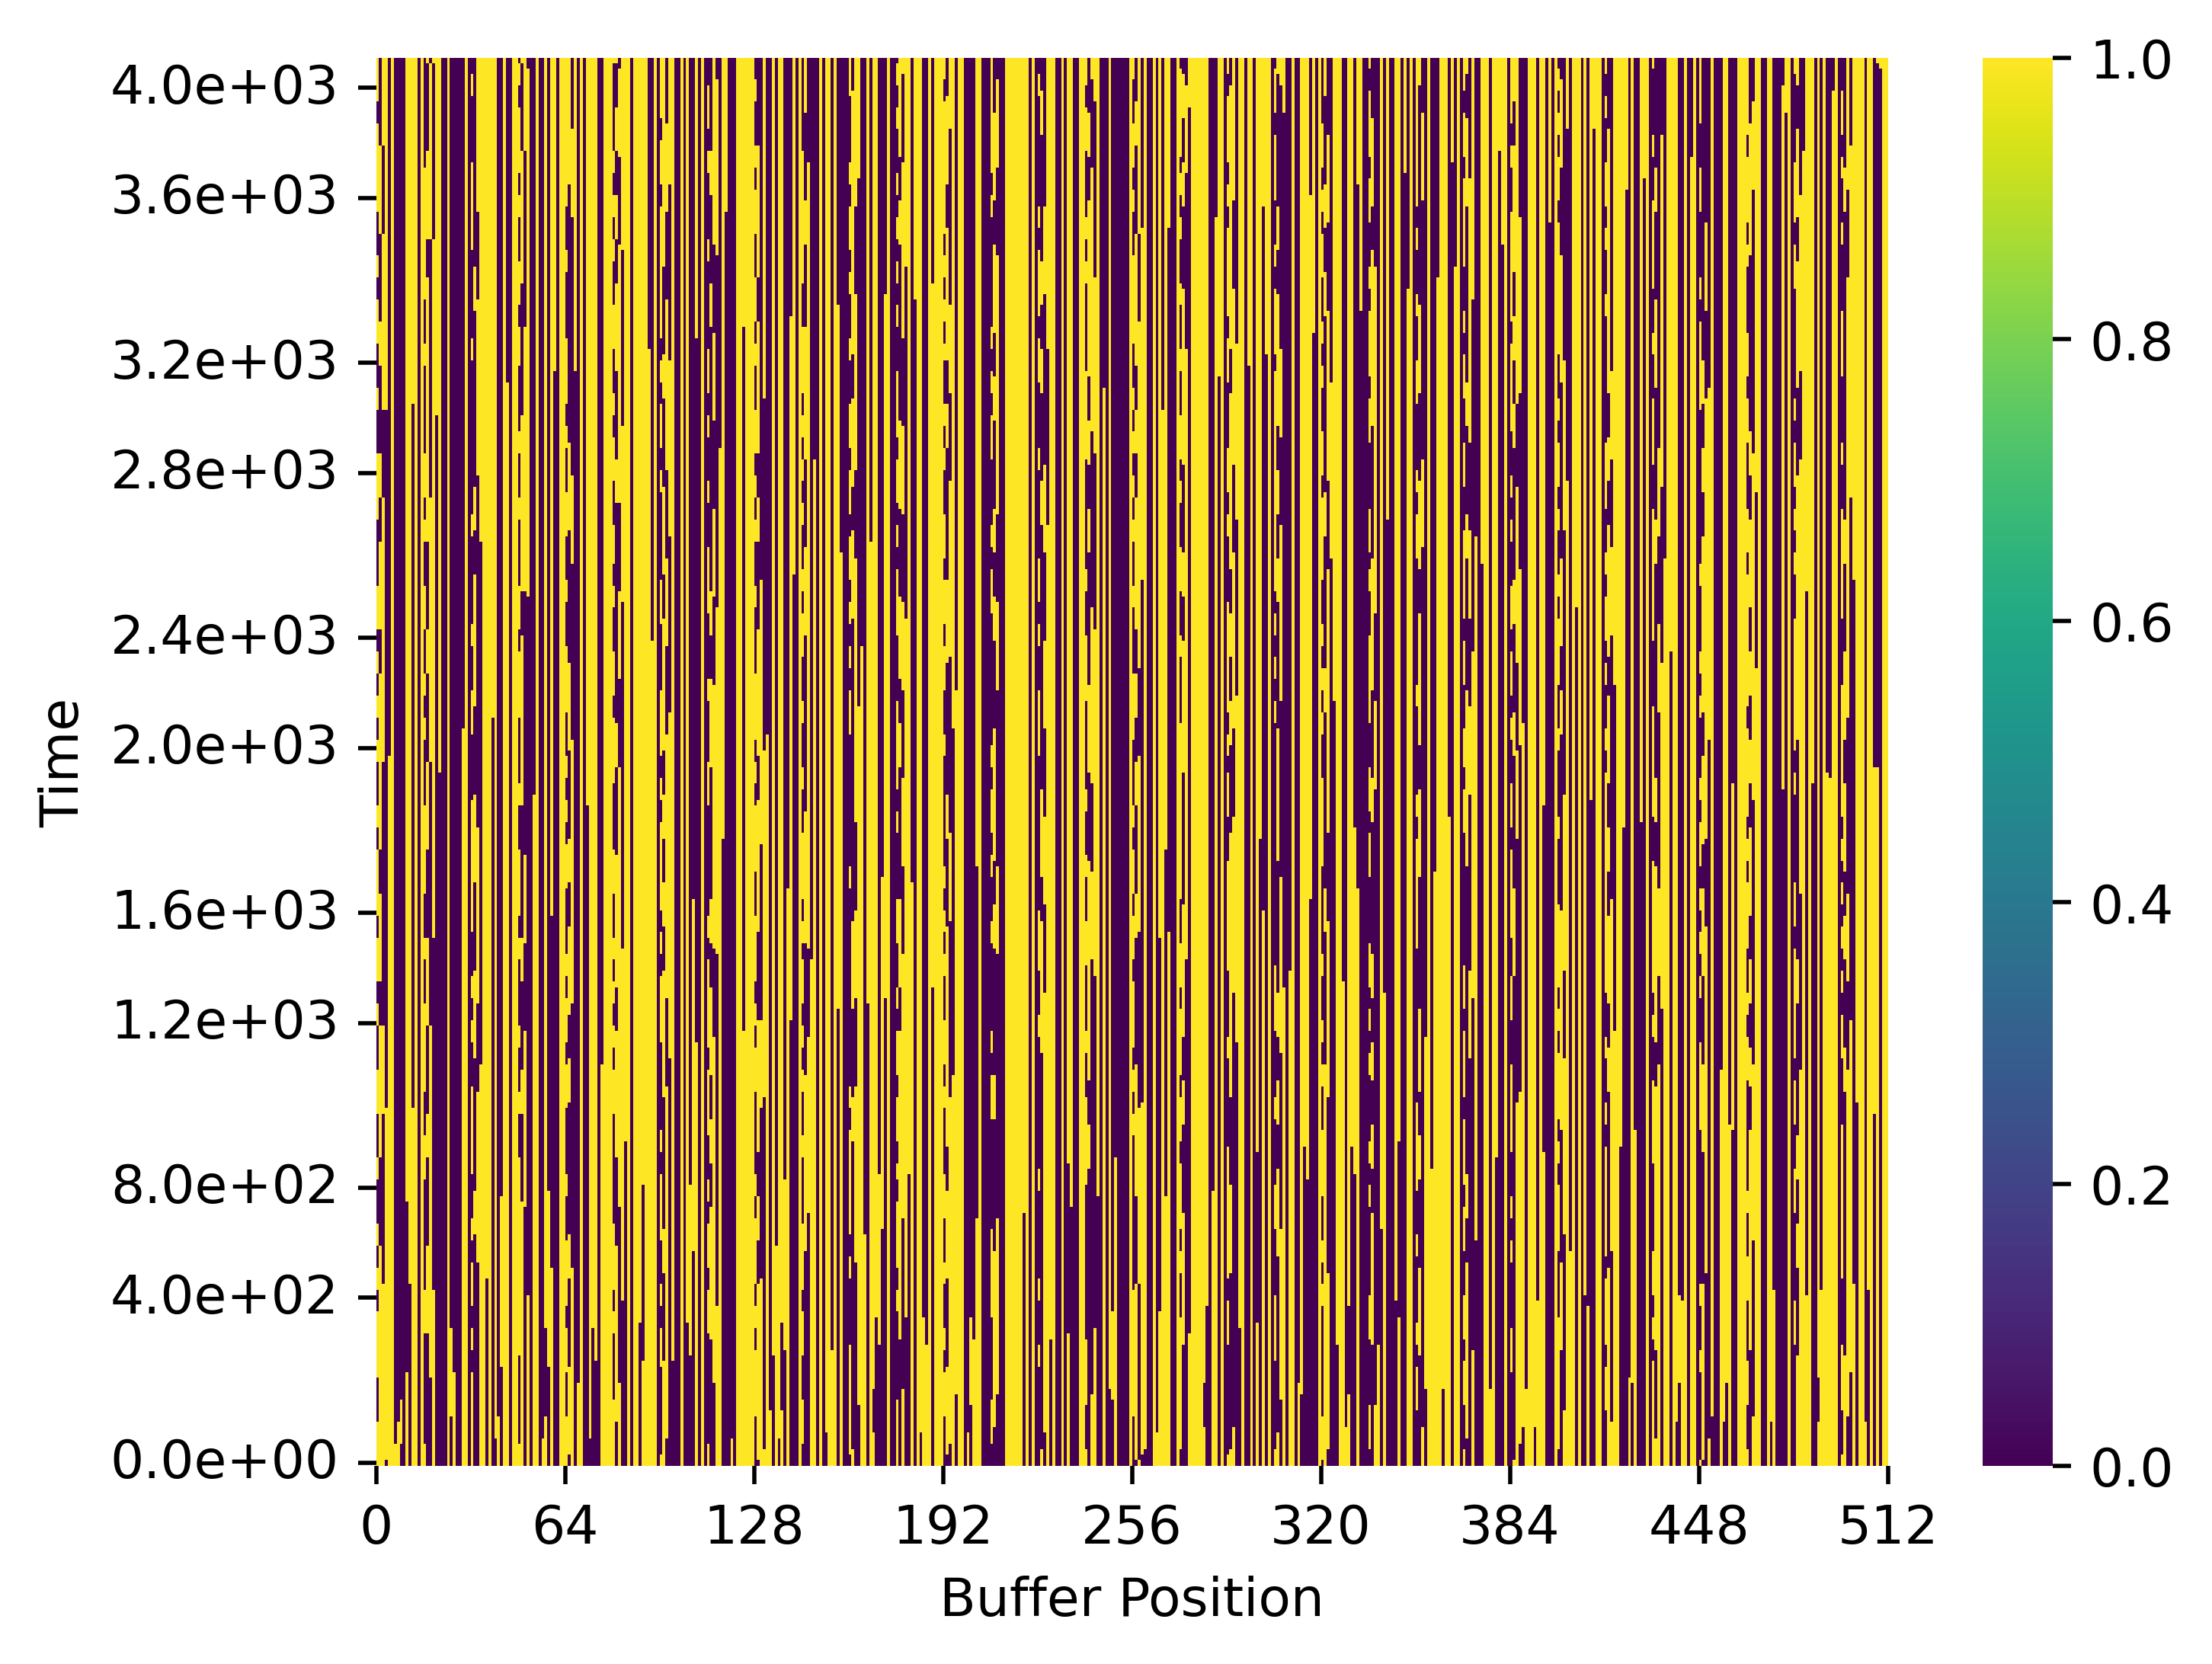

teeplots/03/cnorm=log+num-generations=4096+surface-size=512+viz=site-ingest-rank-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/cnorm=log+num-generations=4096+surface-size=512+viz=site-ingest-rank-by-rank-heatmap+ynorm=log+ext=.png


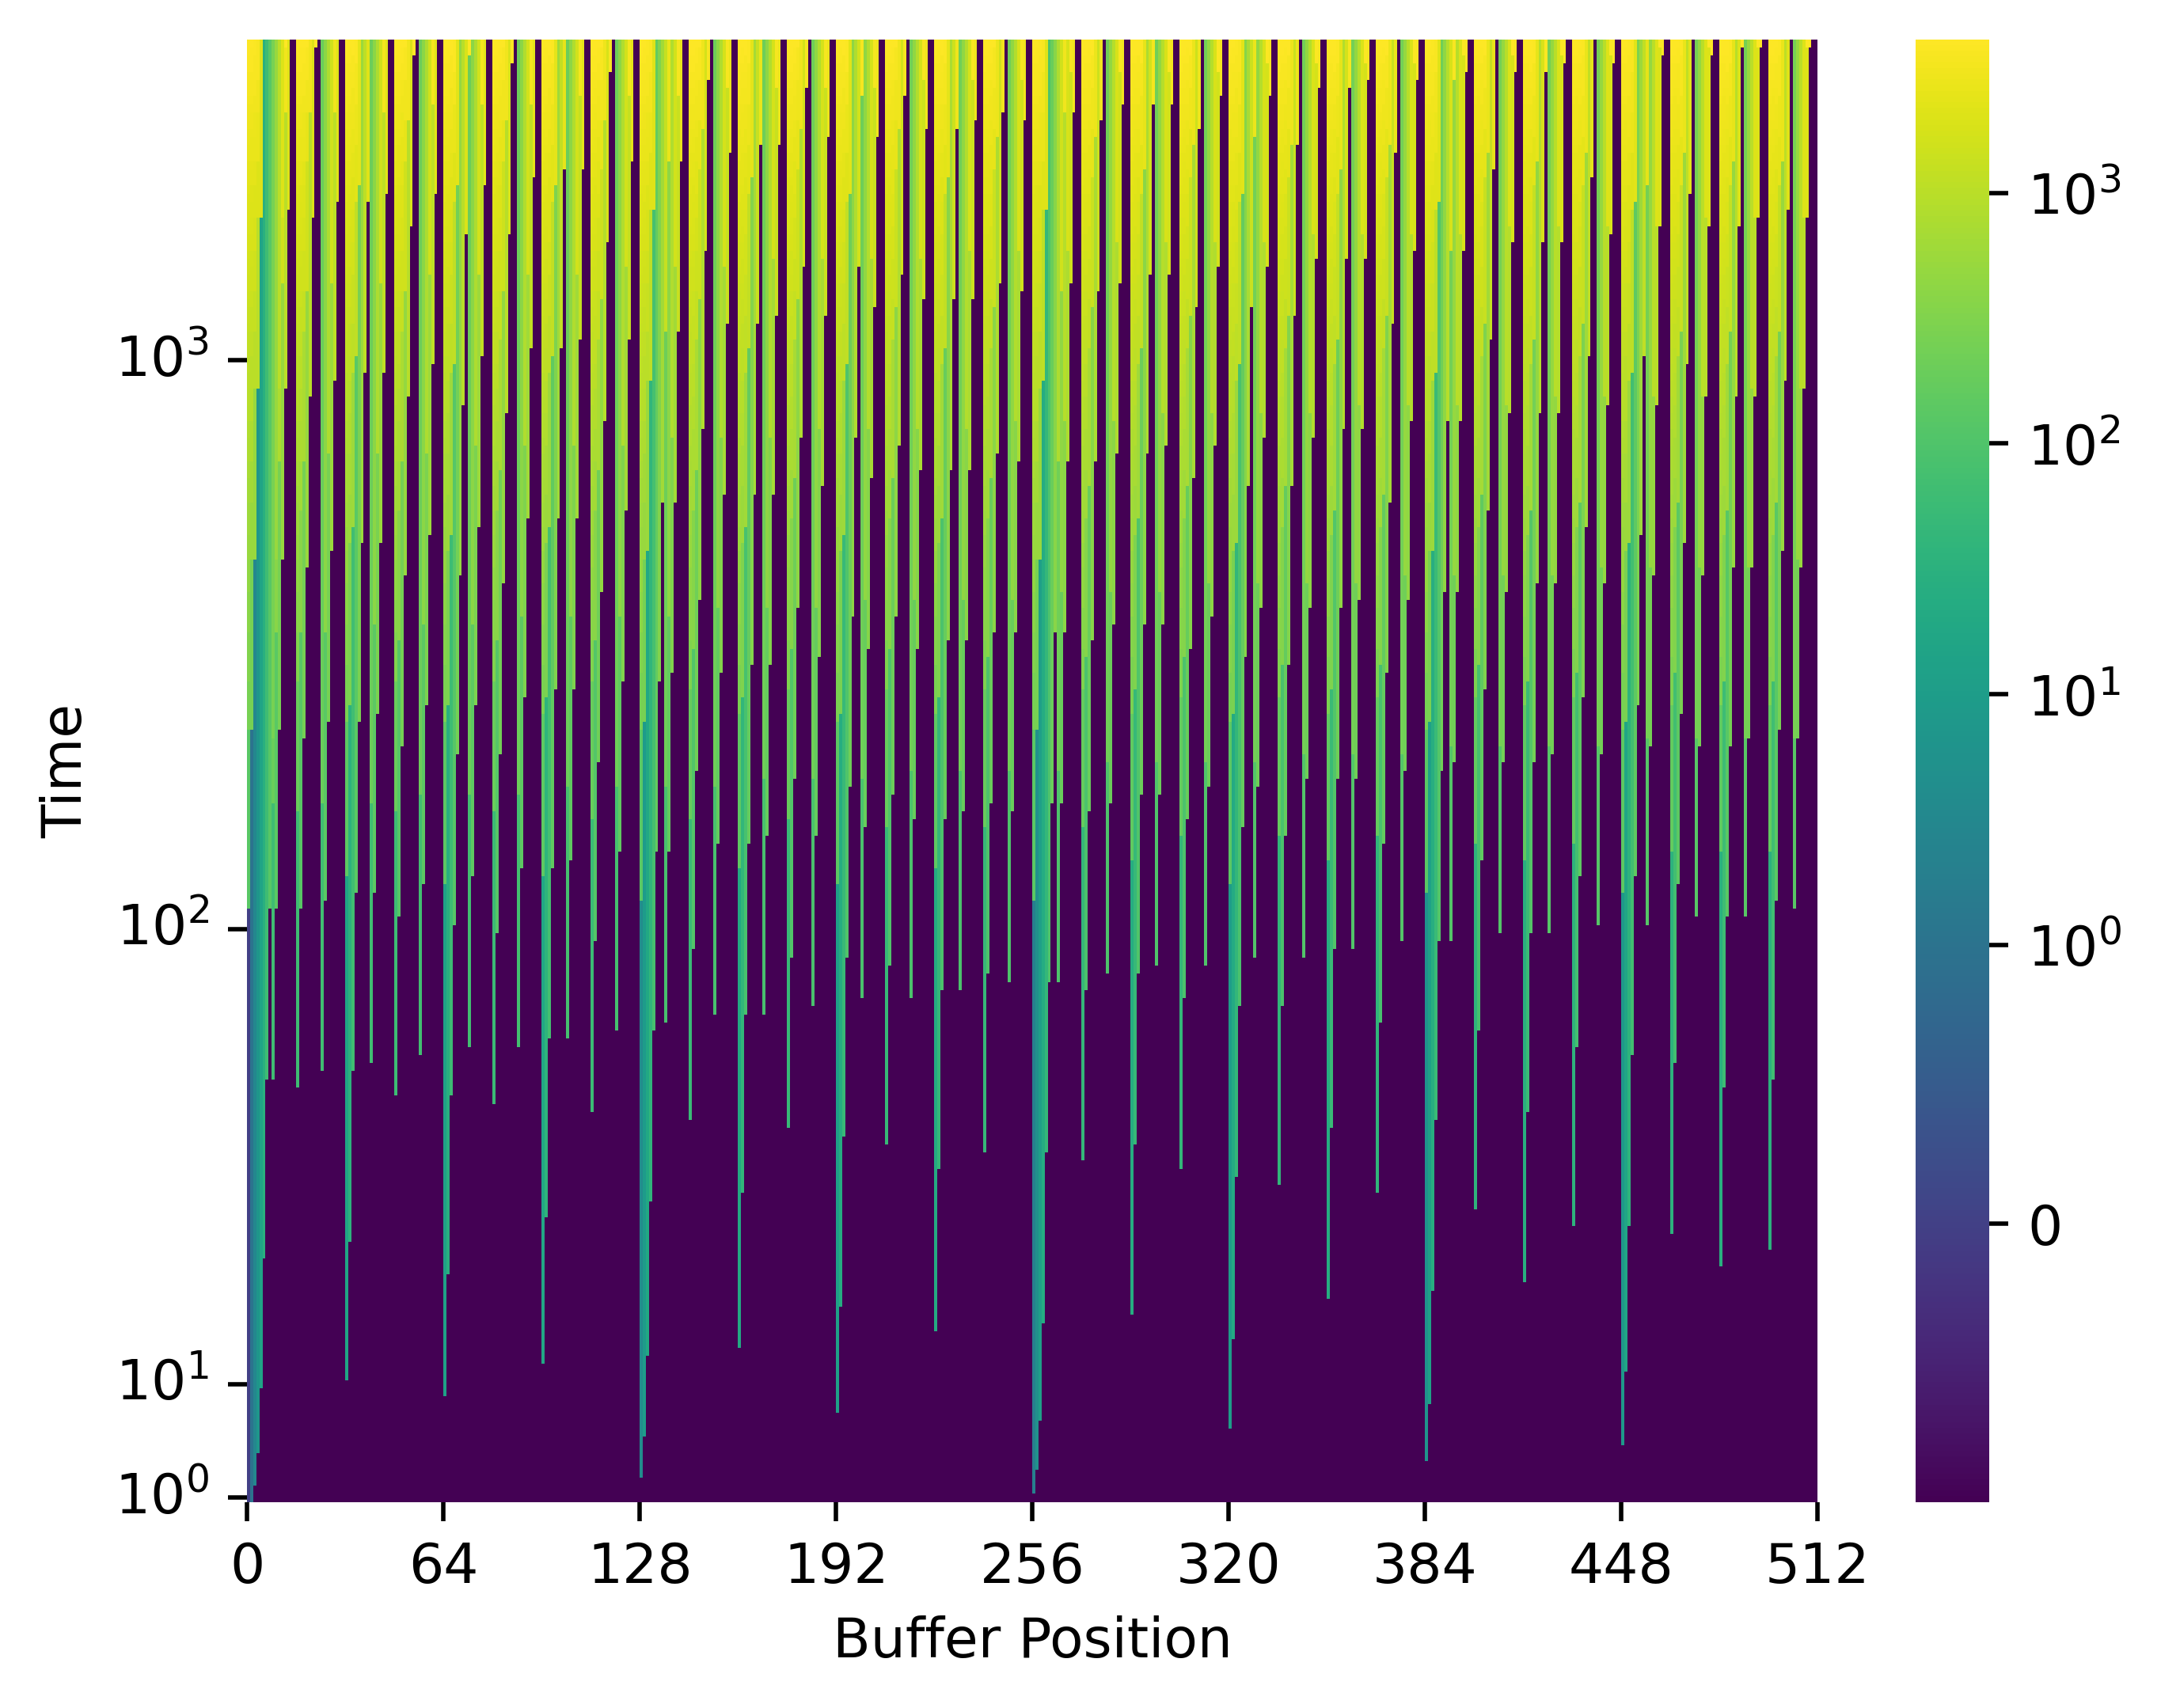

teeplots/03/cnorm=None+num-generations=4096+surface-size=512+viz=site-ingest-rank-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/cnorm=None+num-generations=4096+surface-size=512+viz=site-ingest-rank-by-rank-heatmap+ynorm=linear+ext=.png


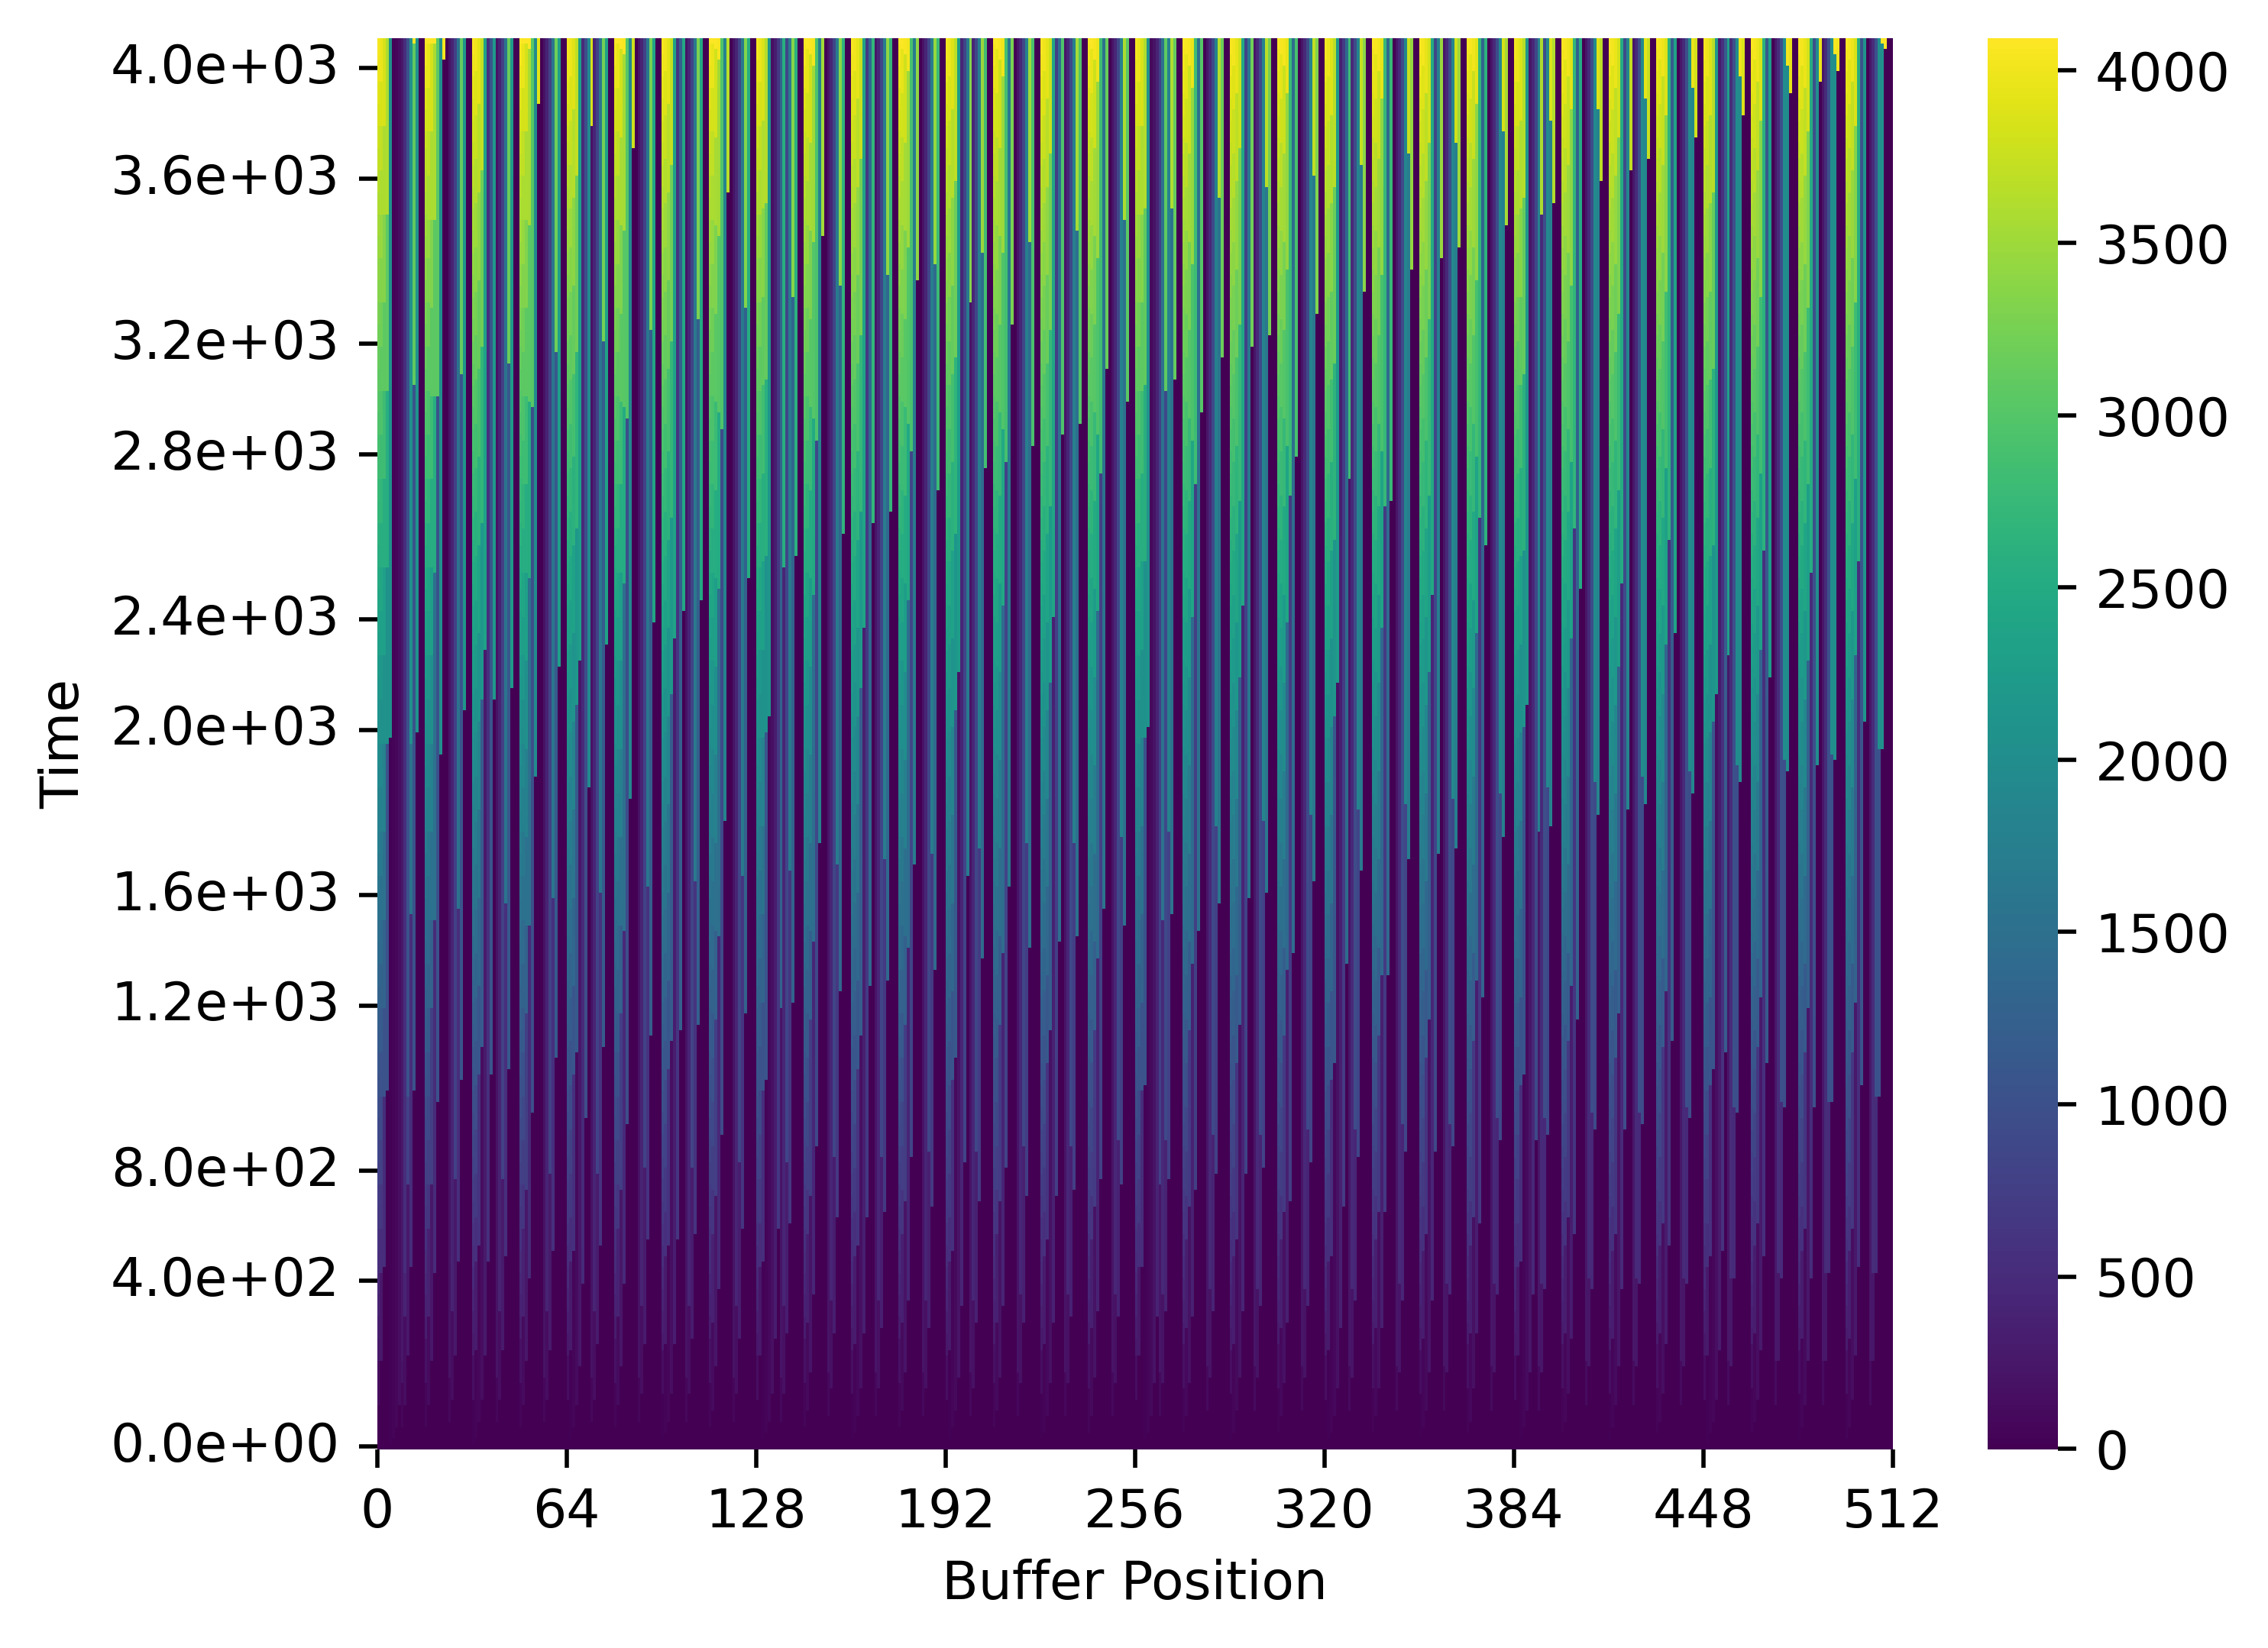

teeplots/03/num-generations=4096+surface-size=512+viz=site-hanoi-value-by-rank-heatmap+ext=.pdf
teeplots/03/num-generations=4096+surface-size=512+viz=site-hanoi-value-by-rank-heatmap+ext=.png


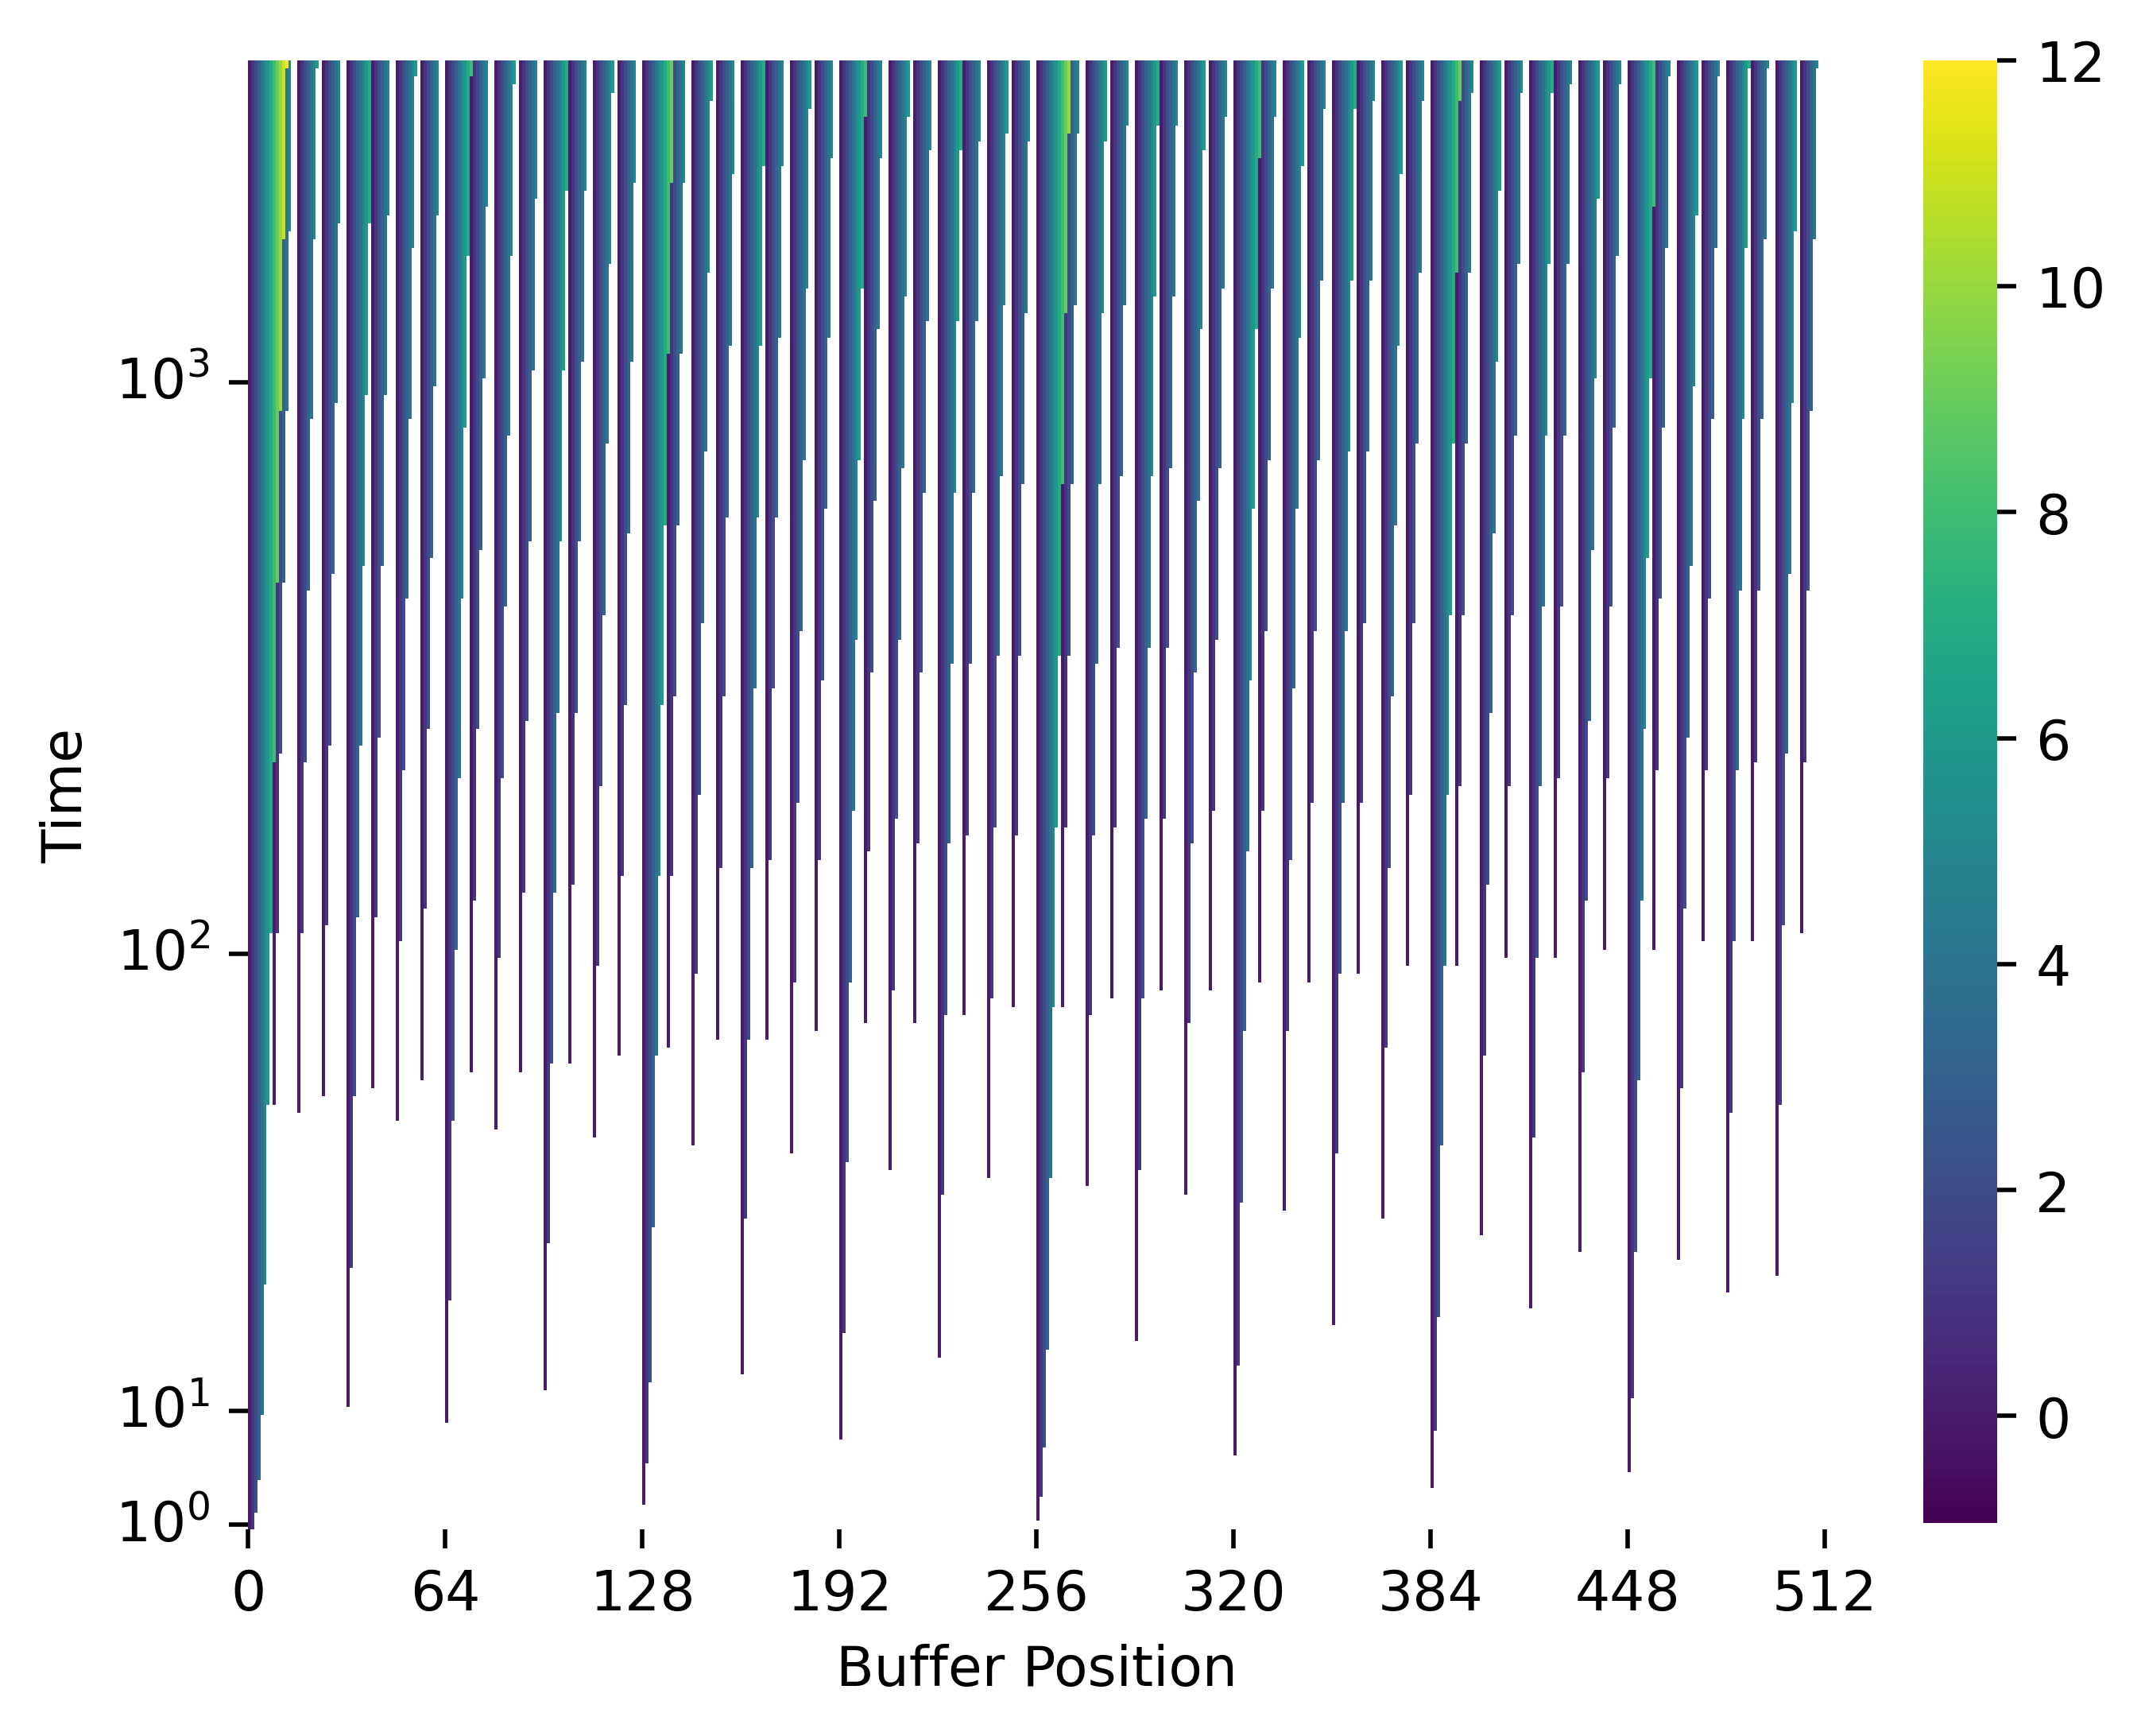

teeplots/03/num-generations=4096+surface-size=512+viz=site-hanoi-value-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/num-generations=4096+surface-size=512+viz=site-hanoi-value-by-rank-heatmap+ynorm=linear+ext=.png


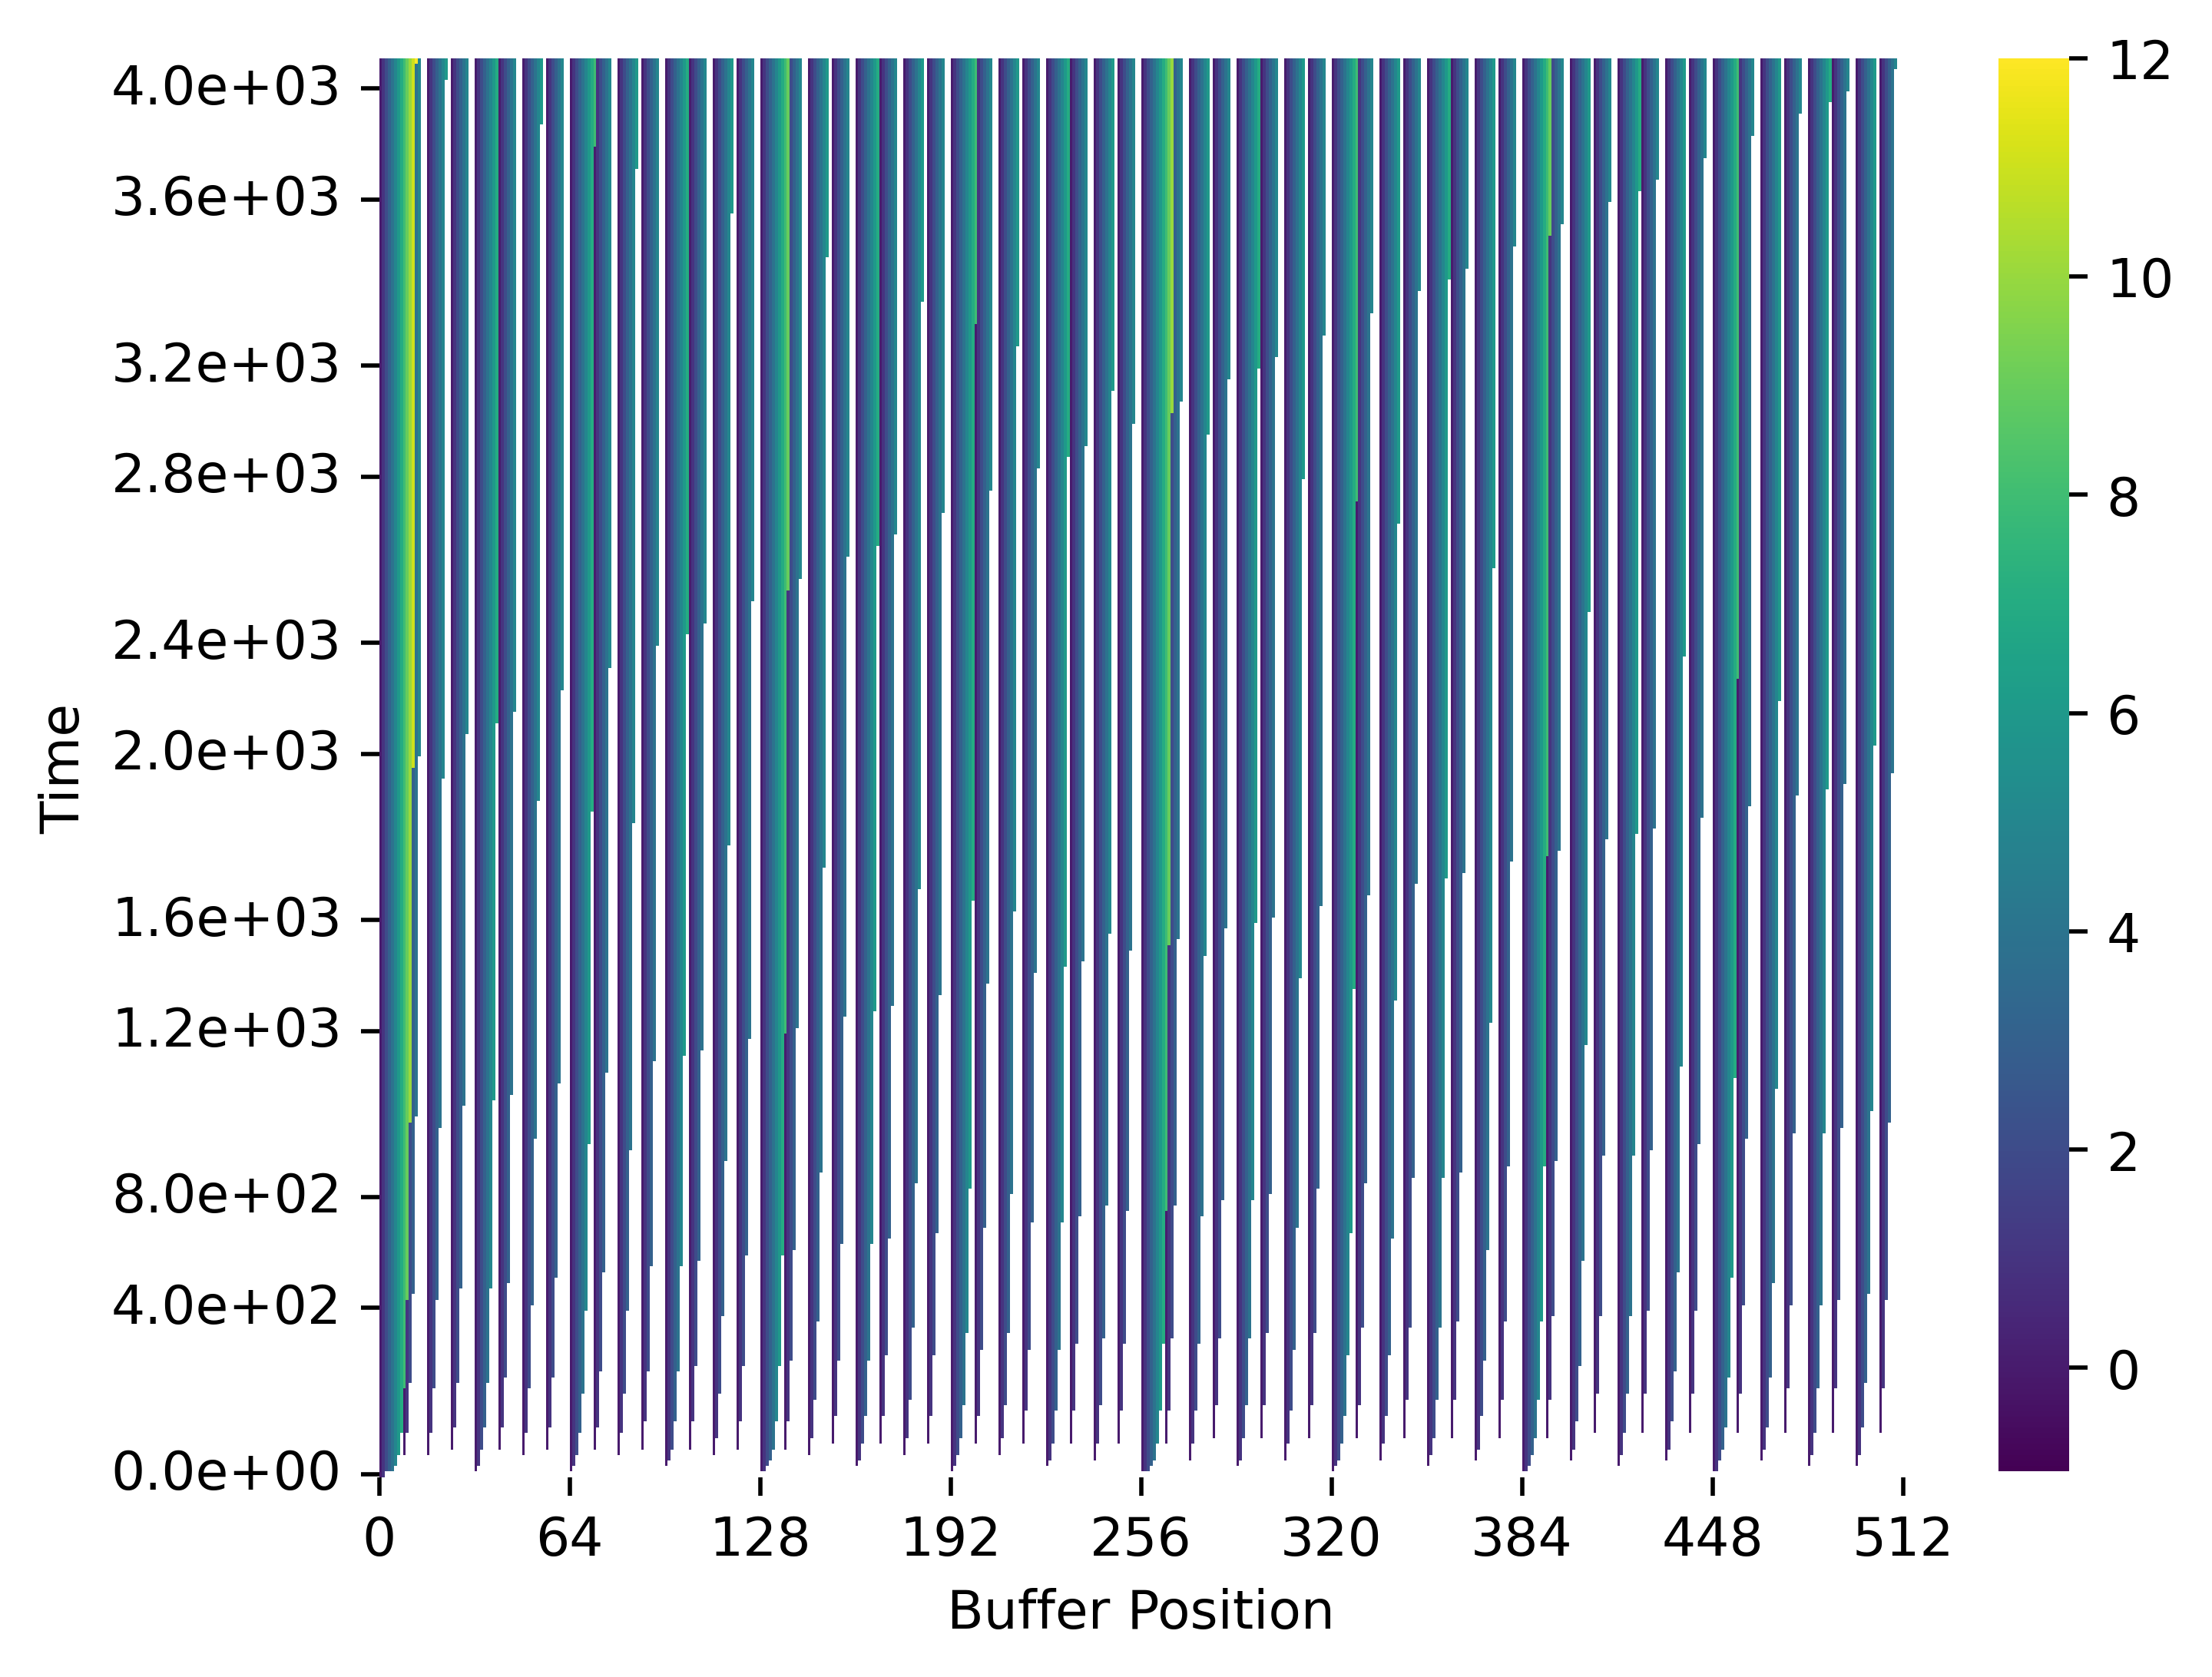

teeplots/03/cnorm=log+num-generations=4096+surface-size=512+viz=site-ingest-depth-by-rank-heatmap+ynorm=log+ext=.pdf
teeplots/03/cnorm=log+num-generations=4096+surface-size=512+viz=site-ingest-depth-by-rank-heatmap+ynorm=log+ext=.png


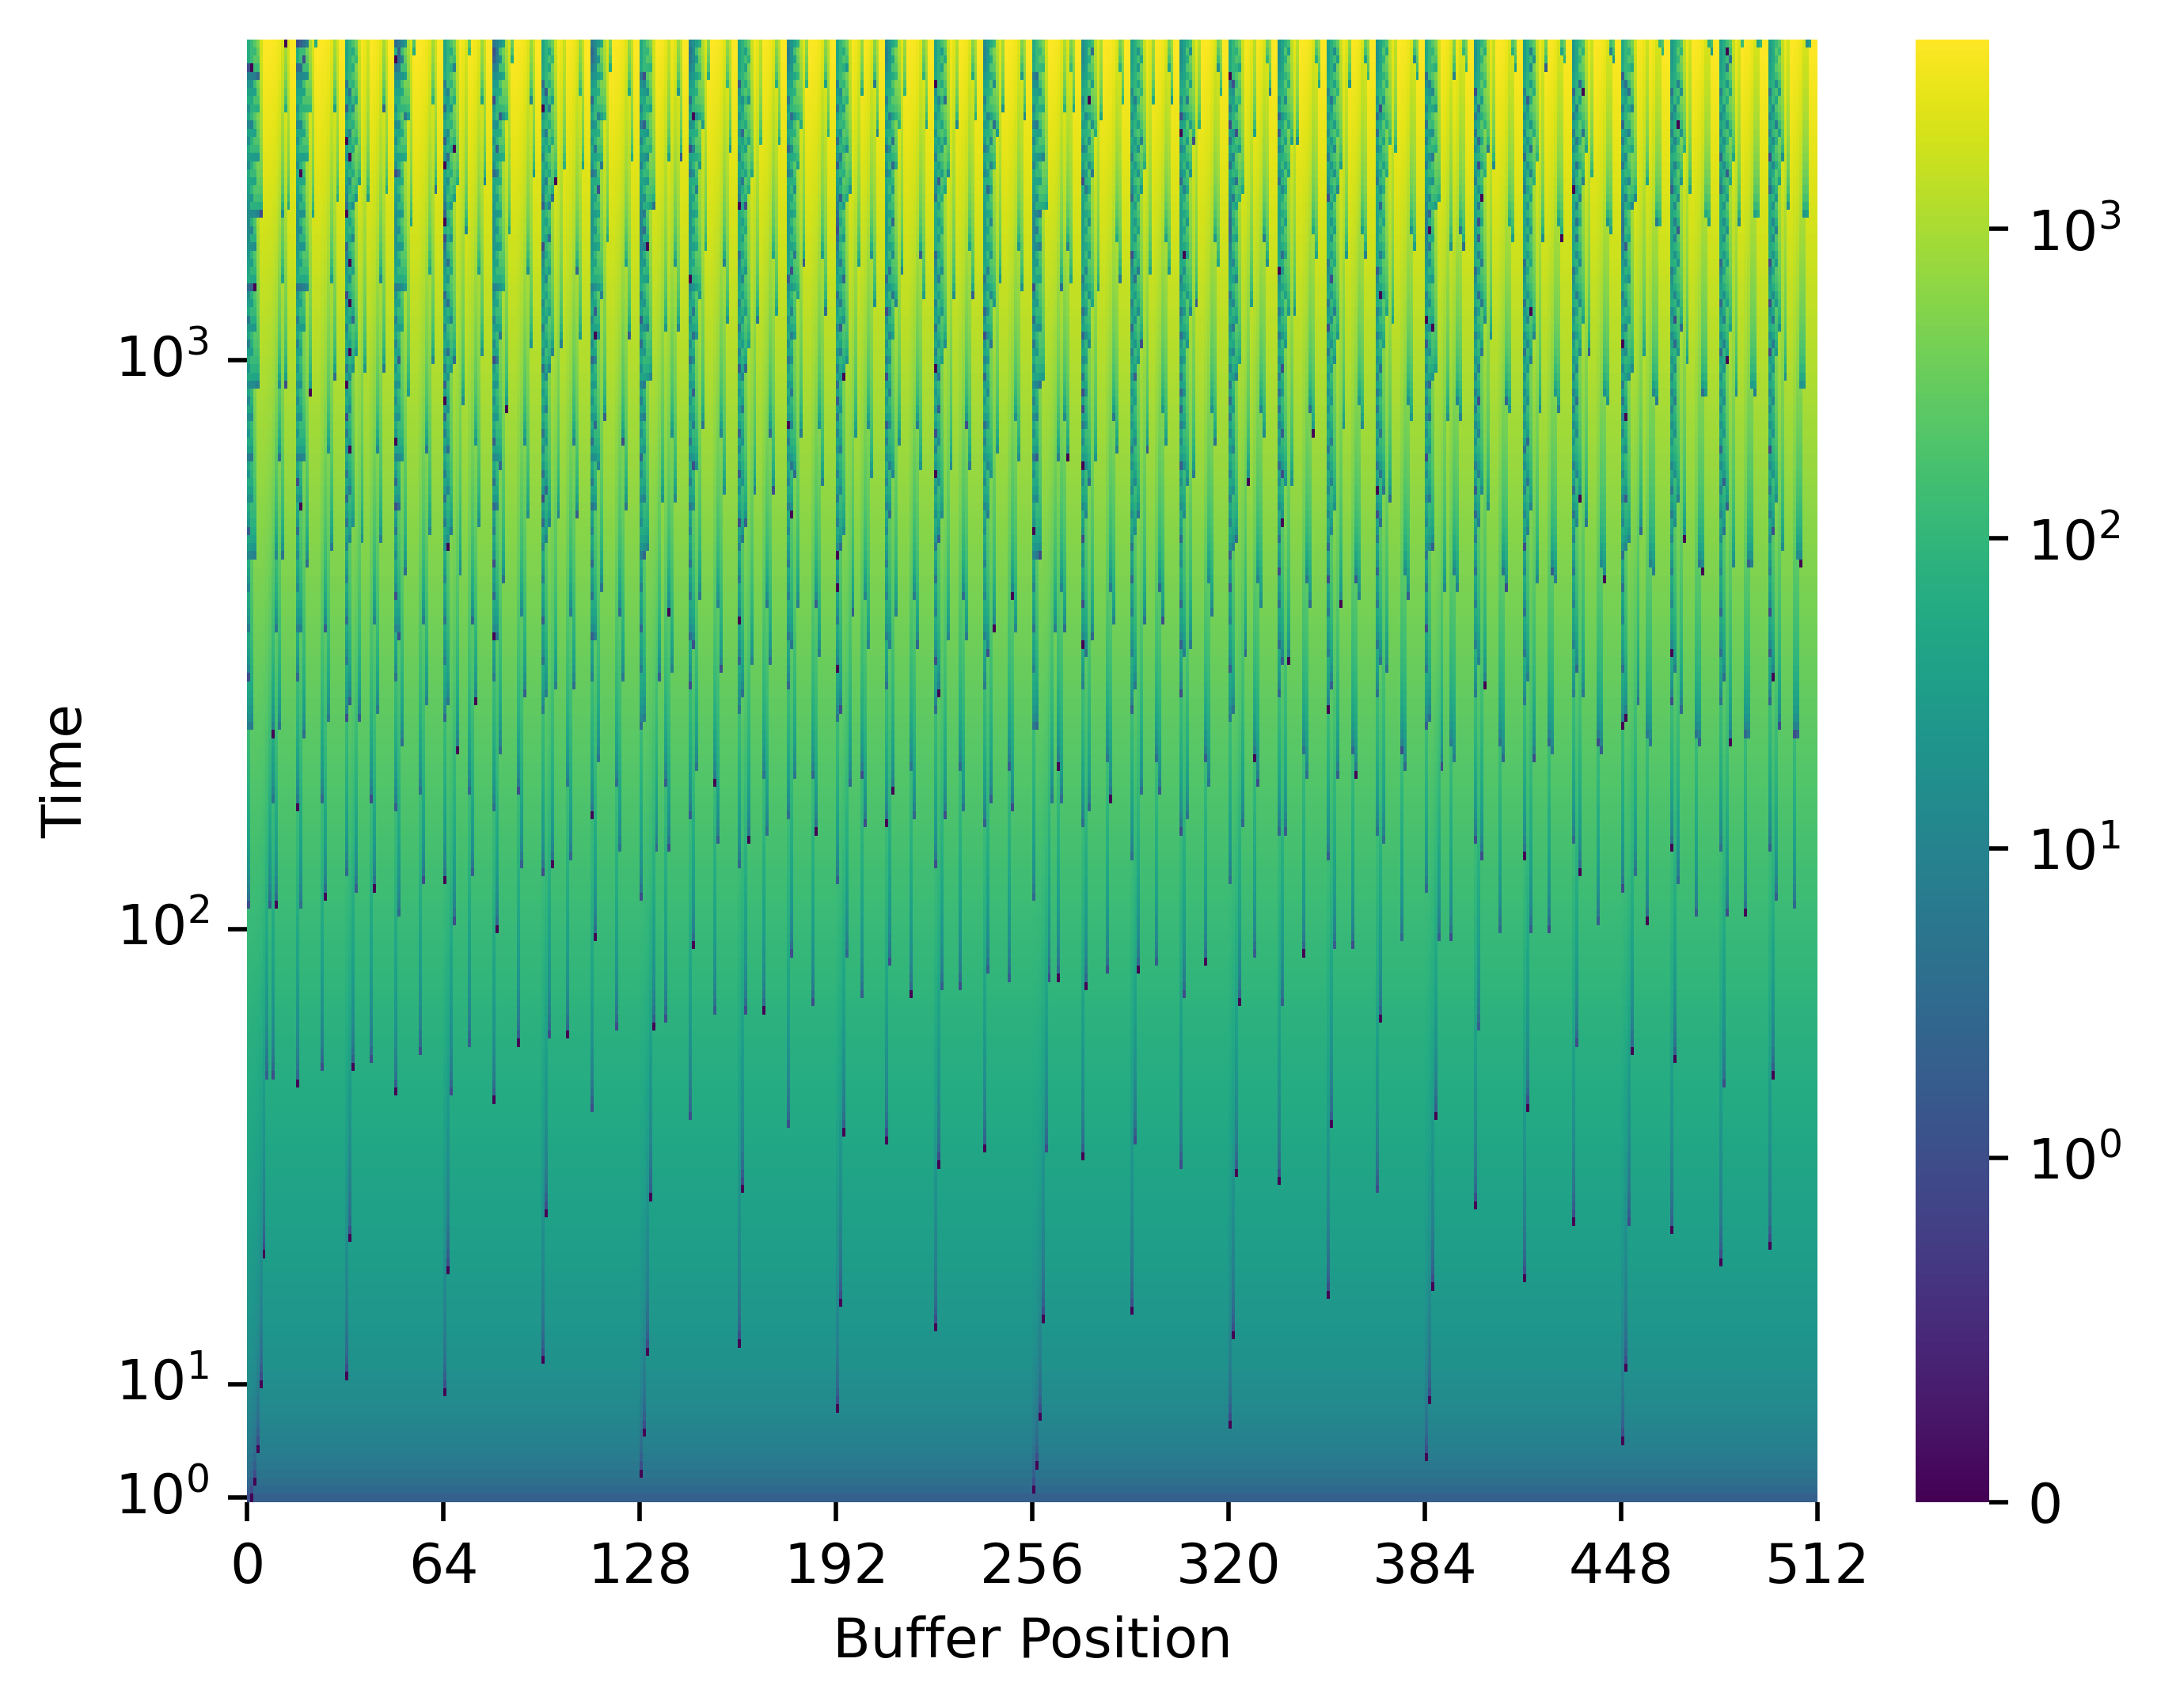

teeplots/03/cnorm=log+num-generations=4096+surface-size=512+viz=site-ingest-depth-by-rank-heatmap+ynorm=linear+ext=.pdf
teeplots/03/cnorm=log+num-generations=4096+surface-size=512+viz=site-ingest-depth-by-rank-heatmap+ynorm=linear+ext=.png


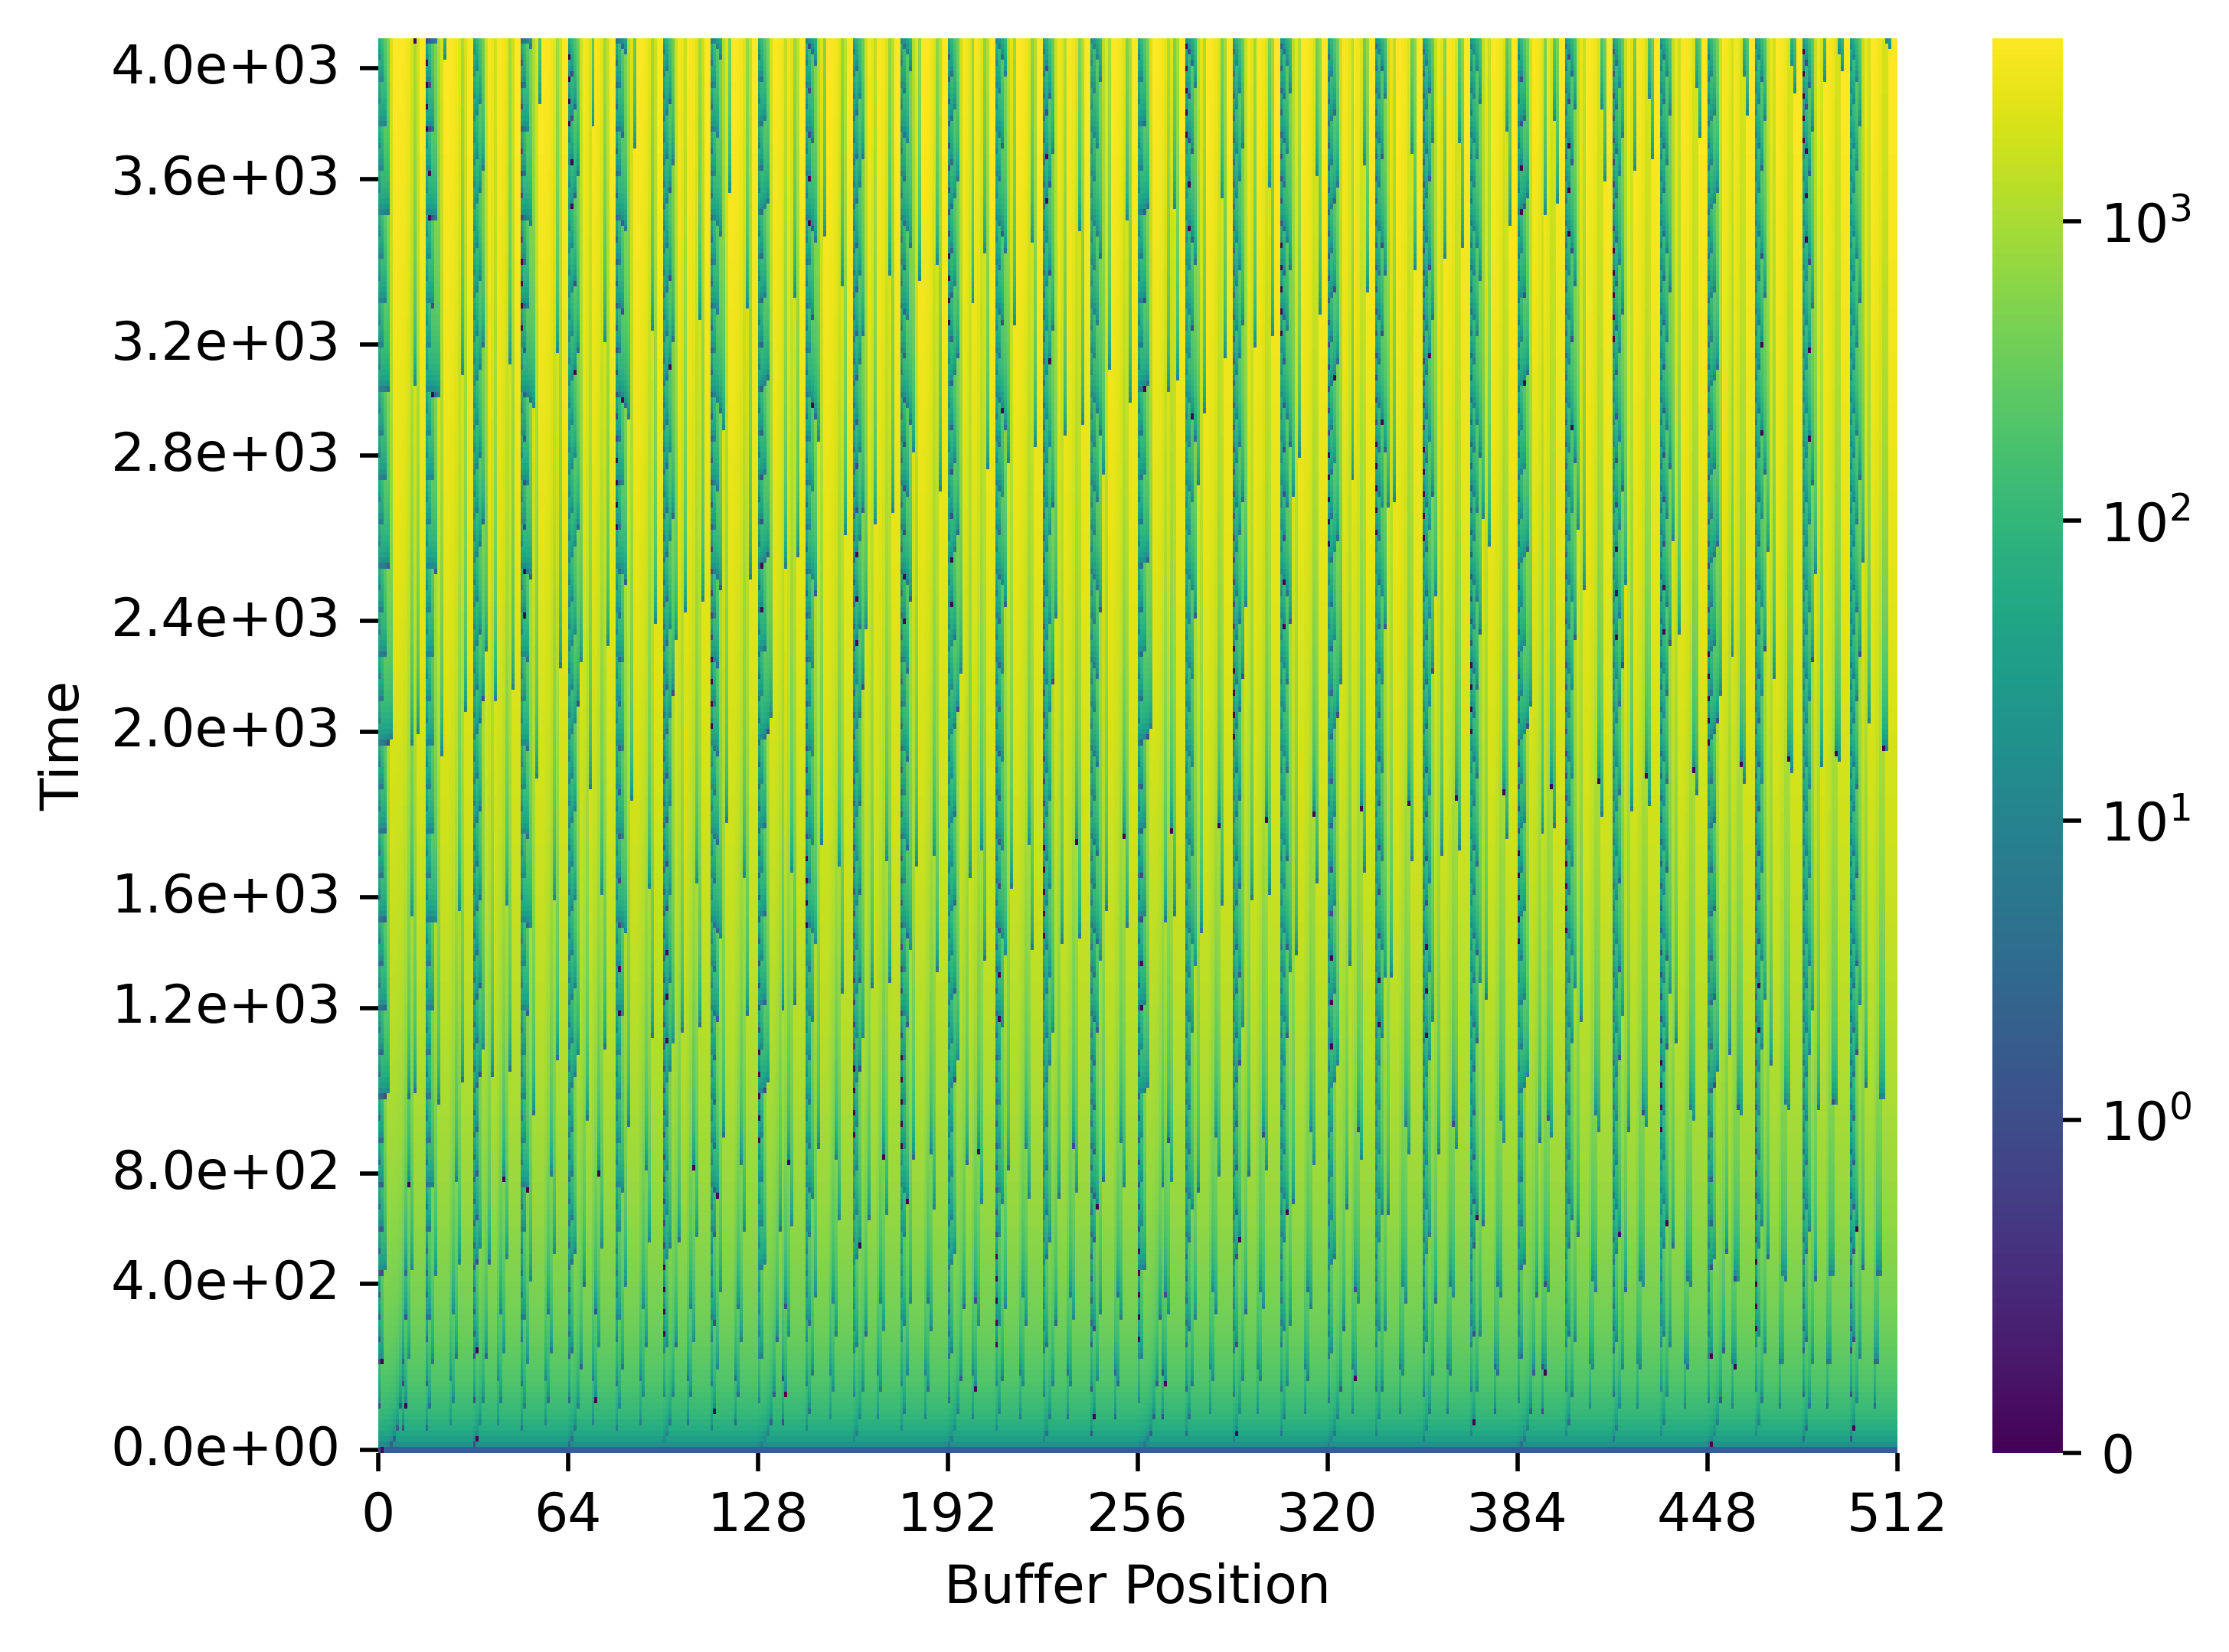

100%|██████████| 2998/2998 [00:14<00:00, 204.75it/s]


teeplots/03/num-generations=4096+surface-size=512+viz=stratum-persistence-dripplot+ext=.pdf
teeplots/03/num-generations=4096+surface-size=512+viz=stratum-persistence-dripplot+ext=.png


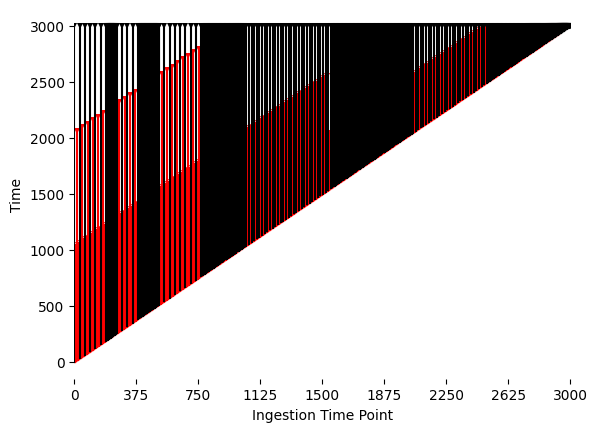

In [43]:
for surface_size_exp in range(3, 10, 2):
    surface_size = 2**surface_size_exp
    display(HTML(f"<h3>surface size {surface_size}</h3>"))

    num_generations = min(
        # don't run out of memory
        2**18 if surface_size_exp < 7 else 2**12,
        get_surface_rank_capacity(surface_size - 1),
    )

    surface_history_df = pylib.site_selection_eval.make_surface_history_df(
        get_ingest_site_at_rank,
        surface_size=surface_size,
        num_generations=num_generations,
        progress_wrap=tqdm,
    )

    # ========================
    kwargs = dict(
        ynorm="log",
    )
    pylib.tee_release(
        pylib.site_selection_viz.site_differentia_by_rank_heatmap,
        surface_history_df,
        **kwargs,
        teeplot_outattrs={
            **{
                "num-generations": num_generations,
                "surface-size": surface_size,
            },
            **kwargs,
        },
        teeplot_subdir="03",
    )

    # ========================
    kwargs = dict(
        ynorm="linear",
    )
    pylib.tee_release(
        pylib.site_selection_viz.site_differentia_by_rank_heatmap,
        surface_history_df,
        **kwargs,
        teeplot_outattrs={
            **{
                "num-generations": num_generations,
                "surface-size": surface_size,
            },
            **kwargs,
        },
        teeplot_subdir="03",
    )

    # ========================
    kwargs = dict(
        cnorm="log",
        ynorm="log",
    )
    pylib.tee_release(
        pylib.site_selection_viz.site_ingest_rank_by_rank_heatmap,
        surface_history_df,
        **kwargs,
        teeplot_outattrs={
            **{
                "num-generations": num_generations,
                "surface-size": surface_size,
            },
            **kwargs,
        },
        teeplot_subdir="03",
    )

    # ========================
    kwargs = dict(
        cnorm=None,
        ynorm="linear",
    )
    pylib.tee_release(
        pylib.site_selection_viz.site_ingest_rank_by_rank_heatmap,
        surface_history_df,
        **kwargs,
        teeplot_outattrs={
            **{
                "num-generations": num_generations,
                "surface-size": surface_size,
            },
            **kwargs,
        },
        teeplot_subdir="03",
    )

    # ========================
    pylib.tee_release(
        pylib.site_selection_viz.site_hanoi_value_by_rank_heatmap,
        surface_history_df,
        teeplot_outattrs={
            "num-generations": num_generations,
            "surface-size": surface_size,
        },
        teeplot_subdir="03",
    )

    # ========================
    kwargs = dict(
        ynorm="linear",
    )
    pylib.tee_release(
        pylib.site_selection_viz.site_hanoi_value_by_rank_heatmap,
        surface_history_df,
        **kwargs,
        teeplot_outattrs={
            **{
                "num-generations": num_generations,
                "surface-size": surface_size,
            },
            **kwargs,
        },
        teeplot_subdir="03",
    )

    # ========================
    kwargs = dict(
        cnorm="log",
        ynorm="log",
    )
    pylib.tee_release(
        pylib.site_selection_viz.site_ingest_depth_by_rank_heatmap,
        surface_history_df,
        **kwargs,
        teeplot_outattrs={
            **{
                "num-generations": num_generations,
                "surface-size": surface_size,
            },
            **kwargs,
        },
        teeplot_subdir="03",
    )

    # ========================
    kwargs = dict(
        cnorm="log",
        ynorm="linear",
    )
    pylib.tee_release(
        pylib.site_selection_viz.site_ingest_depth_by_rank_heatmap,
        surface_history_df,
        **kwargs,
        teeplot_outattrs={
            **{
                "num-generations": num_generations,
                "surface-size": surface_size,
            },
            **kwargs,
        },
        teeplot_subdir="03",
    )

    # ========================
    pylib.tee_release(
        pylib.site_selection_viz.stratum_persistence_dripplot,
        surface_history_df[surface_history_df["rank"] < 3000],
        teeplot_outattrs={
            "num-generations": num_generations,
            "surface-size": surface_size,
        },
        progress_wrap=tqdm,
        teeplot_subdir="03",
    )
